This notebook is a copy of RKI_Data-Preprocessing_forCoxRegressionAnalysisInput.ipynb that splits the data into 70/20/10 train/val/test splits saved in ./output/{train, val, test}.

# Step 1: Loading and EDA
# Import libraries

In [2]:
import os
import pickle
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split


In [3]:
# Set figure size

%matplotlib inline
sns.set(rc = {'figure.figsize':(15,10)})

In [4]:
# Display all rows and columns in a dataframe

pd.options.display.max_rows = None
pd.options.display.max_columns = None

In [5]:
# names and paths

dataset_name = 'texas'
output_path = './output'

#output_train = f'{output_path}/train'
#output_test = f'{output_path}/test'
#output_val = f'{output_path}/val'

# Import dataset

In [6]:
data = pd.read_csv('../data/raw/texas.csv', sep=';')
data.head()

/tmp/ipykernel_91131/774859709.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/raw/texas.csv', sep=';')


,DISCHARGE,TYPE_OF_ADMISSION,PAT_STATE,PAT_STATUS,SEX_CODE,RACE,ETHNICITY,ADMIT_WEEKDAY,PAT_AGE,RISK_MORTALITY,ILLNESS_SEVERITY,LENGTH_OF_STAY,TOTAL_CHARGES,TOTAL_NON_COV_CHARGES,TOTAL_CHARGES_ACCOMM,TOTAL_NON_COV_CHARGES_ACCOMM,TOTAL_CHARGES_ANCIL,TOTAL_NON_COV_CHARGES_ANCIL
0,2013Q4,3,TX,6,F,4,2,3,16,1,1,4.0,55076.06,0.0,5328.0,0.0,49748.06,0.0
1,2013Q1,4,TX,1,F,4,2,4,1,1,1,2.0,2119.00,0.0,1790.0,0.0,329.00,0.0
2,2013Q1,1,TX,1,F,4,2,1,11,1,1,1.0,9534.00,0.0,969.0,0.0,8565.00,0.0
3,2013Q3,2,TX,3,M,4,2,1,18,2,1,3.0,70710.30,0.0,2172.0,0.0,68538.30,0.0
4,2013Q4,2,TX,1,M,4,2,3,16,3,3,3.0,66653.04,0.0,10185.0,0.0,56468.04,0.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   DISCHARGE                     50000 non-null  object 
 1   TYPE_OF_ADMISSION             50000 non-null  object 
 2   PAT_STATE                     50000 non-null  object 
 3   PAT_STATUS                    50000 non-null  object 
 4   SEX_CODE                      50000 non-null  object 
 5   RACE                          50000 non-null  object 
 6   ETHNICITY                     50000 non-null  object 
 7   ADMIT_WEEKDAY                 50000 non-null  int64  
 8   PAT_AGE                       50000 non-null  int64  
 9   RISK_MORTALITY                50000 non-null  int64  
 10  ILLNESS_SEVERITY              50000 non-null  int64  
 11  LENGTH_OF_STAY                50000 non-null  float64
 12  TOTAL_CHARGES                 50000 non-null  float64
 13  T

# Step 2: Data exploration and data preprocessing

In [8]:
def display_countplot(dataframe, column_name, is_vertical=False):
    """Displays countplot."""
    
    print(dataframe[column_name].describe())

    print(f"NA: {dataframe[column_name].isna().sum()/len(dataframe[column_name])*100}%")

    unique_val = dataframe[column_name].nunique()
    print(f"Unique: {unique_val}")

    # display value counts if nunique is less than or equals to 10
    if unique_val <= 30:
        print(dataframe[column_name].unique())
        
    # fill out missing value just for plotting
    df_plot = dataframe.copy()
    df_plot[column_name] = df_plot[column_name].fillna('nan')

    if is_vertical:
        sns.violinplot(y=column_name, data=df_plot)
    else:
        sns.countplot(x=column_name, data=df_plot)

In [9]:
def encode_variables(dataframe, column_name, path):
    """Encode variables and save pickle file."""
    # encode variables

    encoder = preprocessing.LabelEncoder()
    encoded_values = encoder.fit_transform(dataframe[column_name])

    print(f"Encoded classes: {encoder.classes_}")
    print(f"Unique values after encoding: {np.unique(encoded_values)}")
    print(f"Encoded values of the top rows: {encoded_values[:5]}")

    # append to dataframe
    dataframe[column_name] = encoded_values

    # save label encoder as pickle
    save_path = f'{path}/encoder_{column_name}.pkl'
    pickle.dump(encoder, open(save_path, 'wb'))

In [10]:
def normalize_variable(dataframe, column_name, path):
    """Normalize values to range 0 and 1."""
    
    scaler = preprocessing.MinMaxScaler()
    scaled_values = scaler.fit_transform(dataframe[[column_name]])

    print(f"Original max value: {scaler.data_max_}")
    print(f"Original min value: {scaler.data_min_}")
    print(f"Scaled values of the top rows: {scaled_values[:5]}")

    # append to dataframe
    dataframe[column_name] = scaled_values

    # save label encoder as pickle
    save_path = f'{path}/scaler_{column_name}.pkl'
    pickle.dump(scaler, open(save_path, 'wb'))

In [11]:
data_filtered = data.copy()

#data_filtered_train, tmp = train_test_split(data_filtered, test_size=0.3, random_state=42)
#data_filtered_val, data_filtered_test = train_test_split(tmp, test_size=1/3, random_state=42)

# Add ID and VISIT for HIVAE

In [12]:
ids = np.arange(data_filtered.shape[0])
# ids_train = np.arange(data_filtered_train.shape[0])
# ids_val = np.arange(data_filtered_val.shape[0])
# ids_test = np.arange(data_filtered_test.shape[0])

data_filtered.insert(0, 'SUBJID', ids)
# data_filtered_train.insert(0, 'SUBJID', ids_train)
# data_filtered_val.insert(0, 'SUBJID', ids_val)
# data_filtered_test.insert(0, 'SUBJID', ids_test)


In [13]:
data_filtered['SUBJID'].head()

0    0
1    1
2    2
3    3
4    4
Name: SUBJID, dtype: int64

In [14]:
visit = np.zeros(data_filtered.shape[0]).astype(int)
data_filtered.insert(1, 'VISIT', visit)

# visit_train = np.zeros(data_filtered_train.shape[0]).astype(int)
# data_filtered_train.insert(1, 'VISIT', visit_train)

# visit_val = np.zeros(data_filtered_val.shape[0]).astype(int)
# data_filtered_val.insert(1, 'VISIT', visit_val)

# visit_test = np.zeros(data_filtered_test.shape[0]).astype(int)
# data_filtered_test.insert(1, 'VISIT', visit_test)


In [15]:
data_filtered['VISIT'].head()

0    0
1    0
2    0
3    0
4    0
Name: VISIT, dtype: int64

In [16]:
data_filtered.shape

(50000, 20)

In [17]:
data_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SUBJID                        50000 non-null  int64  
 1   VISIT                         50000 non-null  int64  
 2   DISCHARGE                     50000 non-null  object 
 3   TYPE_OF_ADMISSION             50000 non-null  object 
 4   PAT_STATE                     50000 non-null  object 
 5   PAT_STATUS                    50000 non-null  object 
 6   SEX_CODE                      50000 non-null  object 
 7   RACE                          50000 non-null  object 
 8   ETHNICITY                     50000 non-null  object 
 9   ADMIT_WEEKDAY                 50000 non-null  int64  
 10  PAT_AGE                       50000 non-null  int64  
 11  RISK_MORTALITY                50000 non-null  int64  
 12  ILLNESS_SEVERITY              50000 non-null  int64  
 13  L

# DISCHARGE         
- Description: Discharge Quarter. Year and quarter of discharge. yyyyQn.

count      50000
unique         5
top       2013Q2
freq       12560
Name: DISCHARGE, dtype: object
NA: 0.0%
Unique: 5
['2013Q4' '2013Q1' '2013Q3' '2013Q2' '2012Q4']


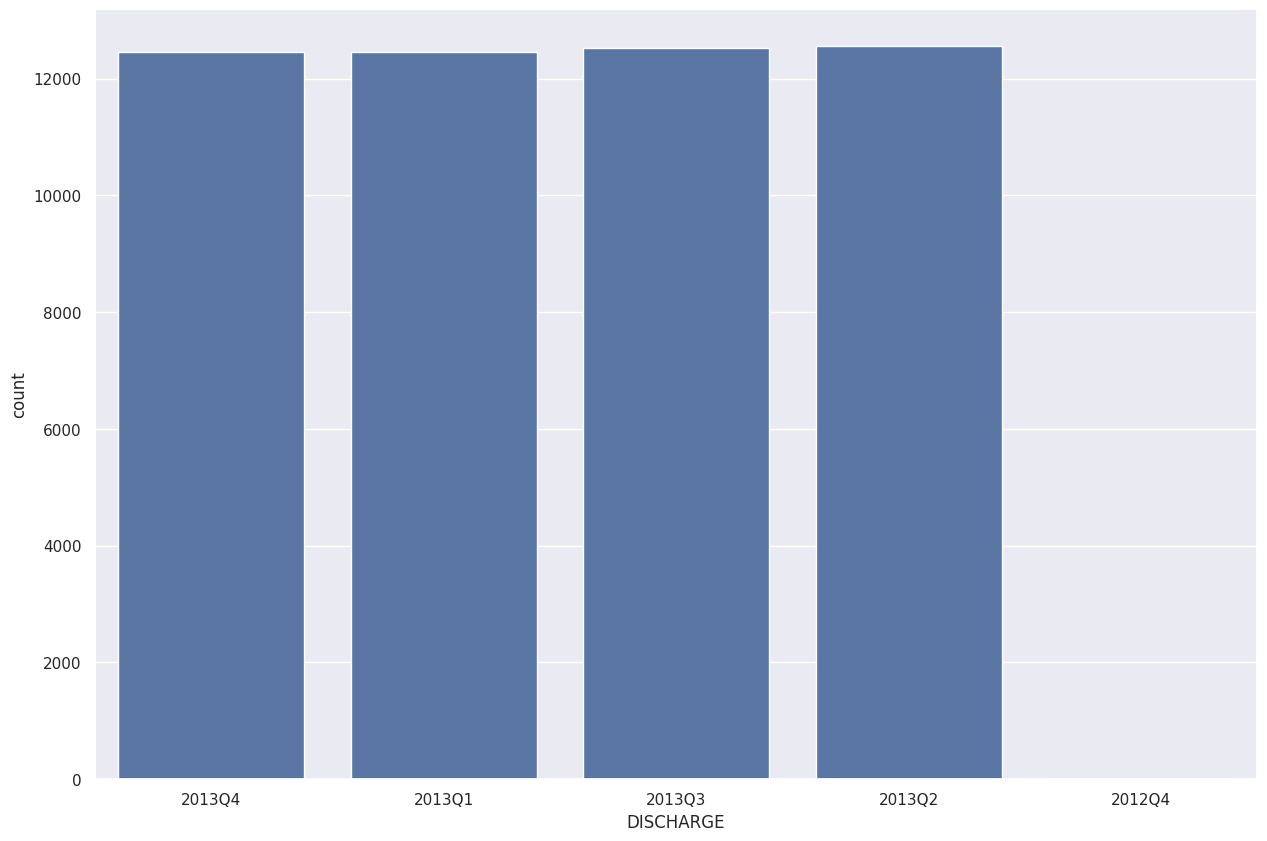

In [18]:
display_countplot(data_filtered, 'DISCHARGE')

In [19]:
# encode categories

colname = 'DISCHARGE'
print(f"Unique {colname}: {data_filtered[colname].unique()}")
encode_variables(dataframe=data_filtered, column_name=colname, path=output_path)

# print(f"Unique {colname}: {data_filtered_train[colname].unique()}")
# encode_variables(dataframe=data_filtered_train, column_name=colname, path=output_train)

# print(f"Unique {colname}: {data_filtered_val[colname].unique()}")
# encode_variables(dataframe=data_filtered_val, column_name=colname, path=output_val)

# print(f"Unique {colname}: {data_filtered_test[colname].unique()}")
# encode_variables(dataframe=data_filtered_test, column_name=colname, path=output_test)

Unique DISCHARGE: ['2013Q4' '2013Q1' '2013Q3' '2013Q2' '2012Q4']
Encoded classes: ['2012Q4' '2013Q1' '2013Q2' '2013Q3' '2013Q4']
Unique values after encoding: [0 1 2 3 4]
Encoded values of the top rows: [4 1 1 3 4]


In [20]:
# there seems to have only one row for '2012Q4'

data_filtered[data_filtered['DISCHARGE'] == 0].shape

(1, 20)

count    50000.000000
mean         2.499500
std          1.116685
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: DISCHARGE, dtype: float64
NA: 0.0%
Unique: 5
[4 1 3 2 0]


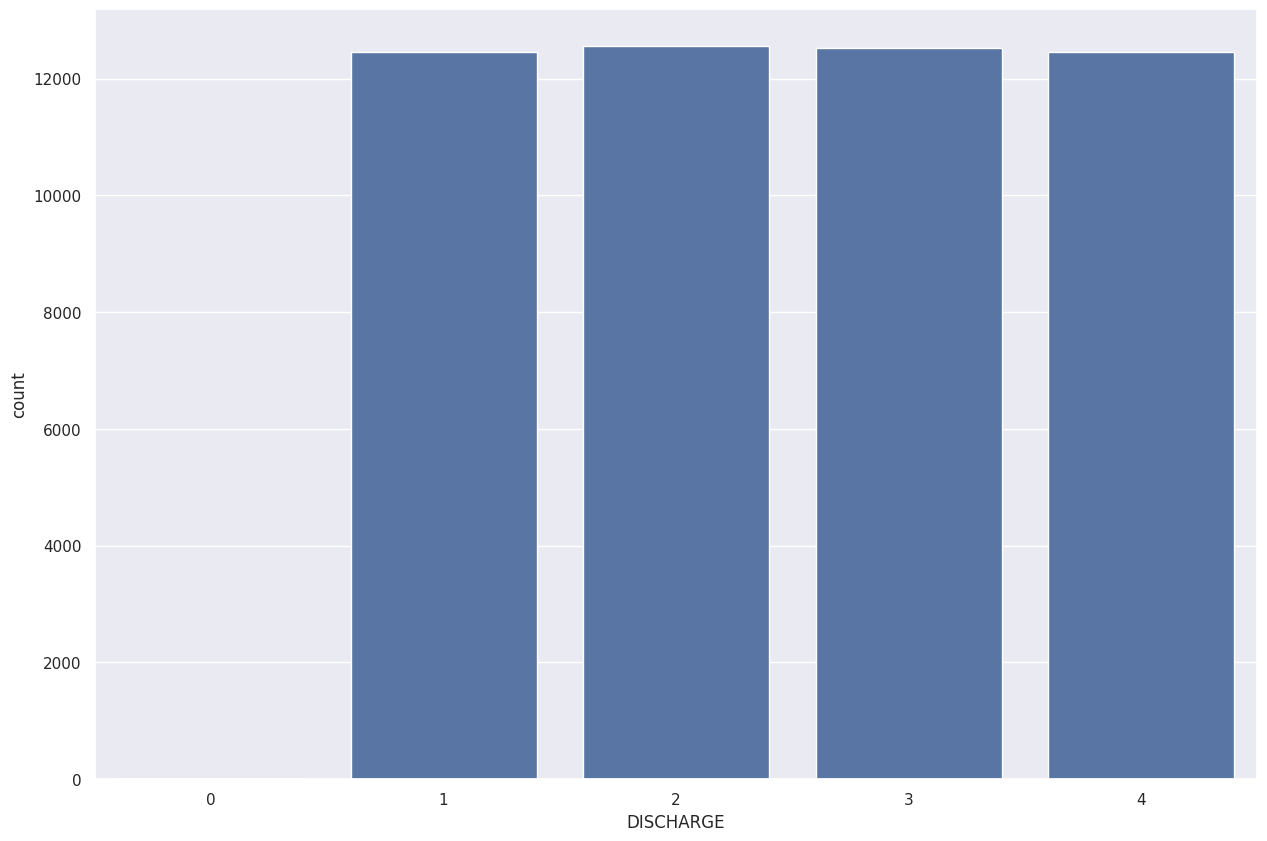

In [21]:
# after

display_countplot(data_filtered, 'DISCHARGE')

# TYPE_OF_ADMISSION       

Description: Code indicating the type of admission
<br> Coding Scheme: 
- 1 Emergency
- 2 Urgent
- 3 Elective
- 4 Newborn
- 5 Trauma Center
- 9 Information not available
- ` Invalid 

count     50000
unique       13
top           1
freq      13675
Name: TYPE_OF_ADMISSION, dtype: object
NA: 0.0%
Unique: 13
['3' '4' '1' '2' '9' '5' 'INVALID' 1 3 4 2 9 5]


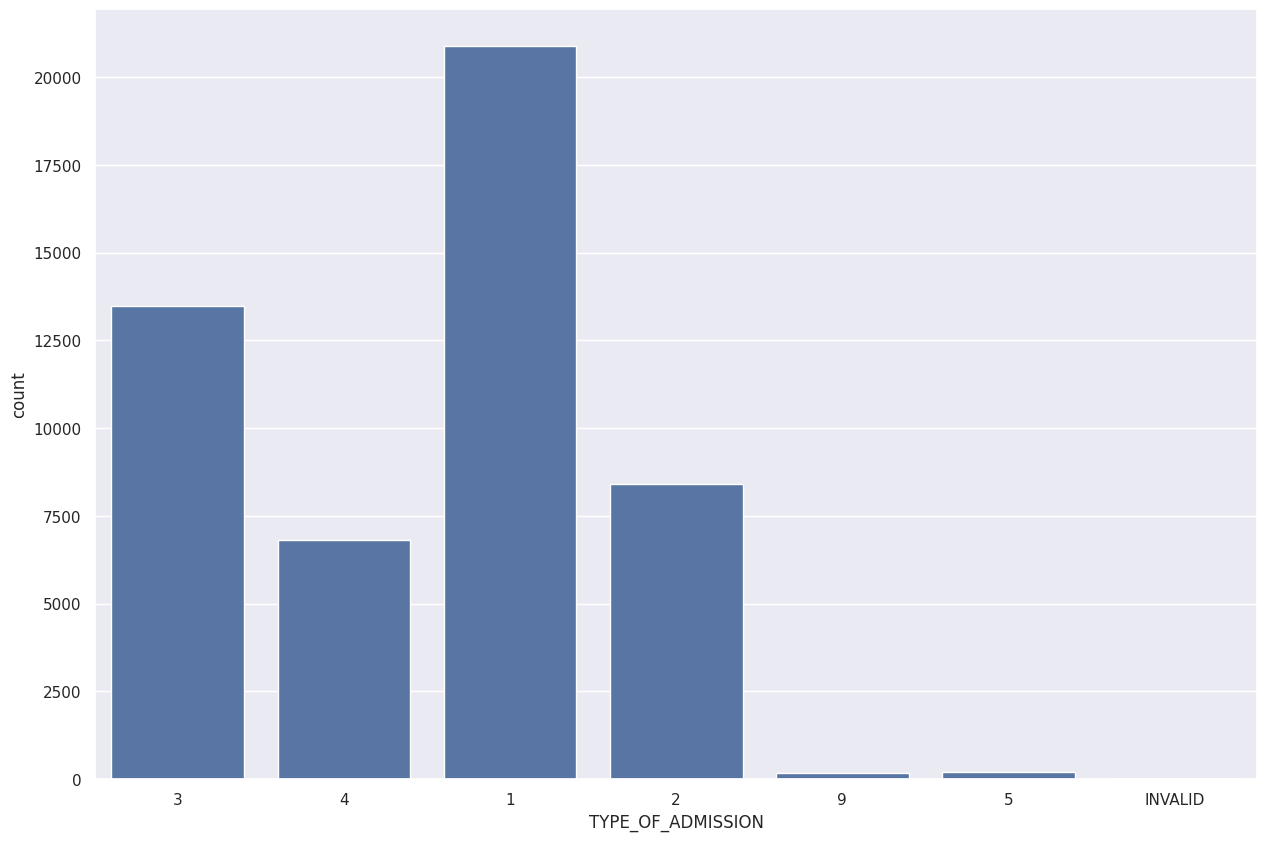

In [22]:
display_countplot(data_filtered, 'TYPE_OF_ADMISSION')

In [23]:
# convert invalid as 0

colname = 'TYPE_OF_ADMISSION'
data_filtered.loc[(data_filtered[colname] == 'INVALID'), colname] = 0
print(data_filtered[colname].unique())

# data_filtered_train.loc[(data_filtered_train[colname] == 'INVALID'), colname] = 0
# print(data_filtered_train[colname].unique())

# data_filtered_val.loc[(data_filtered_val[colname] == 'INVALID'), colname] = 0
# print(data_filtered_val[colname].unique())

# data_filtered_val.loc[(data_filtered_val[colname] == 'INVALID'), colname] = 0
# print(data_filtered_val[colname].unique())


['3' '4' '1' '2' '9' '5' 0 1 3 4 2 9 5]


In [24]:
# convert string values to numerical values

data_filtered[colname] = pd.to_numeric(data_filtered[colname])
print(data_filtered[colname].unique())

# data_filtered_train[colname] = pd.to_numeric(data_filtered_train[colname])
# print(data_filtered_train[colname].unique())

# data_filtered_val[colname] = pd.to_numeric(data_filtered_val[colname])
# print(data_filtered_val[colname].unique())

# data_filtered_test[colname] = pd.to_numeric(data_filtered_test[colname])
# print(data_filtered_test[colname].unique())

[3 4 1 2 9 5 0]


In [25]:
# encode categories

encode_variables(dataframe=data_filtered, column_name=colname, path=output_path)

# encode_variables(dataframe=data_filtered_train, column_name=colname, path=output_train)
# encode_variables(dataframe=data_filtered_test, column_name=colname, path=output_test)
# encode_variables(dataframe=data_filtered_val, column_name=colname, path=output_val)

Encoded classes: [0 1 2 3 4 5 9]
Unique values after encoding: [0 1 2 3 4 5 6]
Encoded values of the top rows: [3 4 1 2 2]


count    50000.000000
mean         2.151540
std          1.143049
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: TYPE_OF_ADMISSION, dtype: float64
NA: 0.0%
Unique: 7
[3 4 1 2 6 5 0]


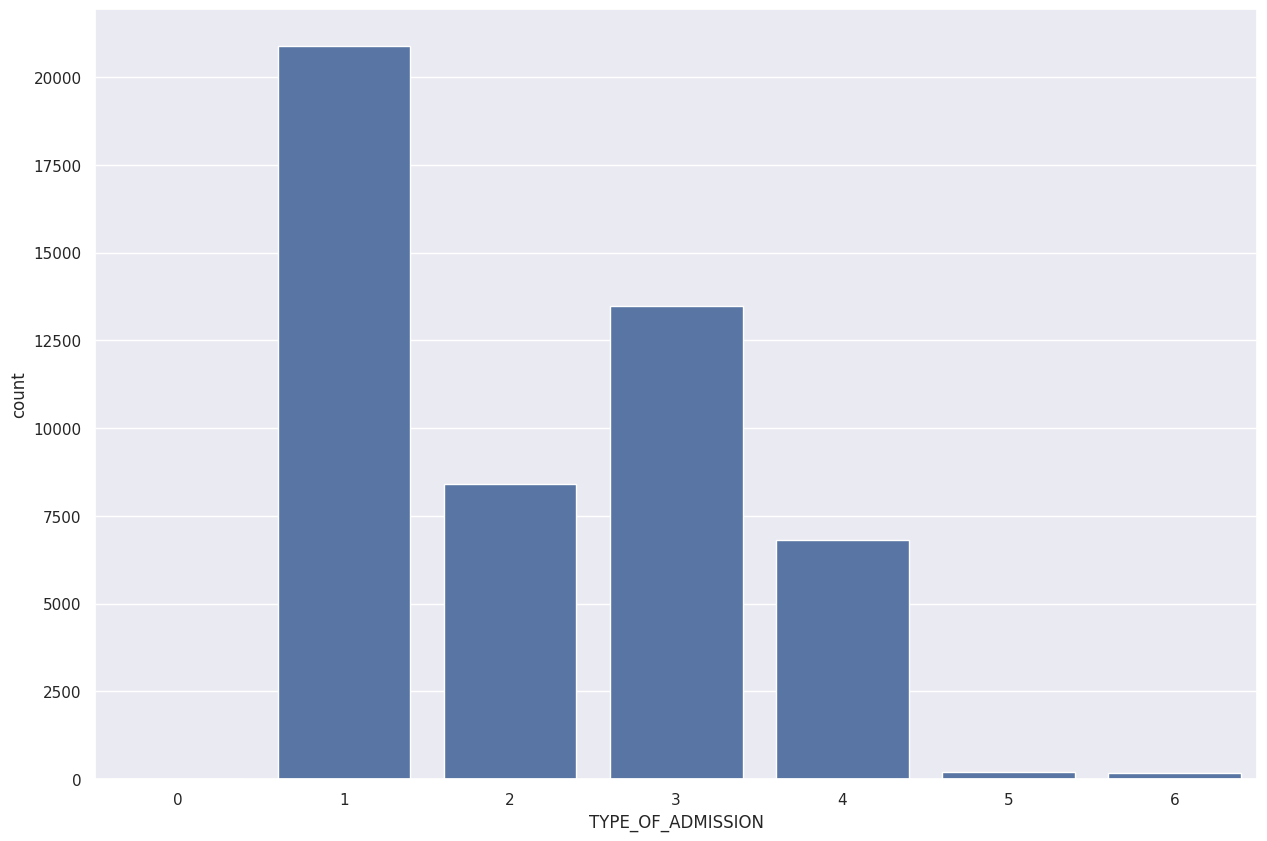

In [26]:
# after

display_countplot(dataframe=data_filtered, column_name=colname)

# PAT_STATE

Description: State of the patient’s mailing address in Texas and contiguous states. Standard 2-character Postal Service abbreviation. 
<br>Coding Scheme: 
- AR Arkansas
- LA Louisiana
- NM New Mexico
- OK Oklahoma
- TX Texas
- ZZ All other states and American Territories
- FC Foreign country
- XX Foreign country

count     50000
unique        9
top          TX
freq      48580
Name: PAT_STATE, dtype: object
NA: 0.0%
Unique: 9
['TX' 'NM' 'AR' 'ZZ' 'OK' 'FC' 'LA' 'XX' 'INVALID']


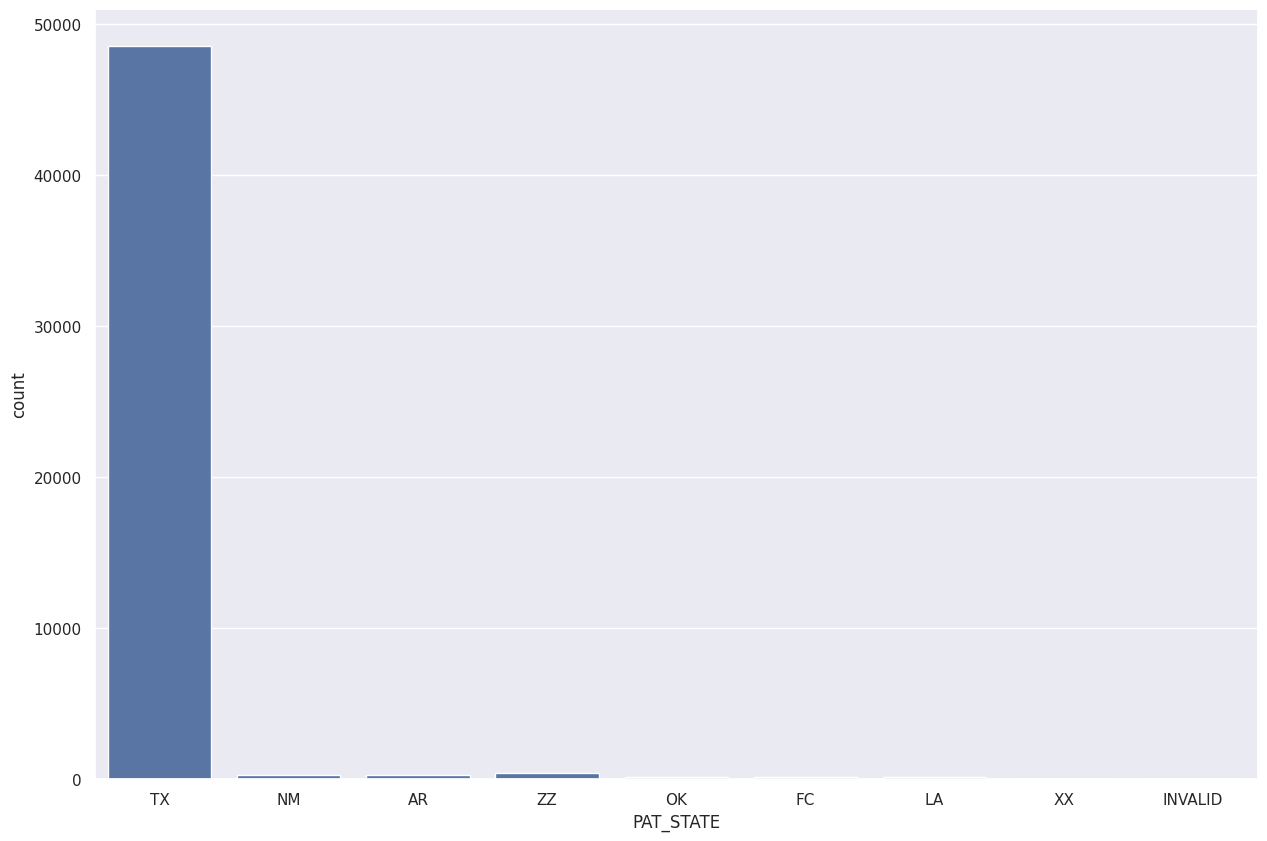

In [27]:
display_countplot(data_filtered, 'PAT_STATE')

In [28]:
# encode categories

colname = 'PAT_STATE'
print(f"Unique {colname}: {data_filtered[colname].unique()}")
encode_variables(dataframe=data_filtered, column_name=colname, path=output_path)

# print(f"Unique {colname}: {data_filtered_train[colname].unique()}")
# encode_variables(dataframe=data_filtered_train, column_name=colname, path=output_train)

# print(f"Unique {colname}: {data_filtered_val[colname].unique()}")
# encode_variables(dataframe=data_filtered_val, column_name=colname, path=output_val)

# print(f"Unique {colname}: {data_filtered_test[colname].unique()}")
# encode_variables(dataframe=data_filtered_test, column_name=colname, path=output_test)

Unique PAT_STATE: ['TX' 'NM' 'AR' 'ZZ' 'OK' 'FC' 'LA' 'XX' 'INVALID']
Encoded classes: ['AR' 'FC' 'INVALID' 'LA' 'NM' 'OK' 'TX' 'XX' 'ZZ']
Unique values after encoding: [0 1 2 3 4 5 6 7 8]
Encoded values of the top rows: [6 6 6 6 6]


count    50000.000000
mean         5.950580
std          0.580676
min          0.000000
25%          6.000000
50%          6.000000
75%          6.000000
max          8.000000
Name: PAT_STATE, dtype: float64
NA: 0.0%
Unique: 9
[6 4 0 8 5 1 3 7 2]


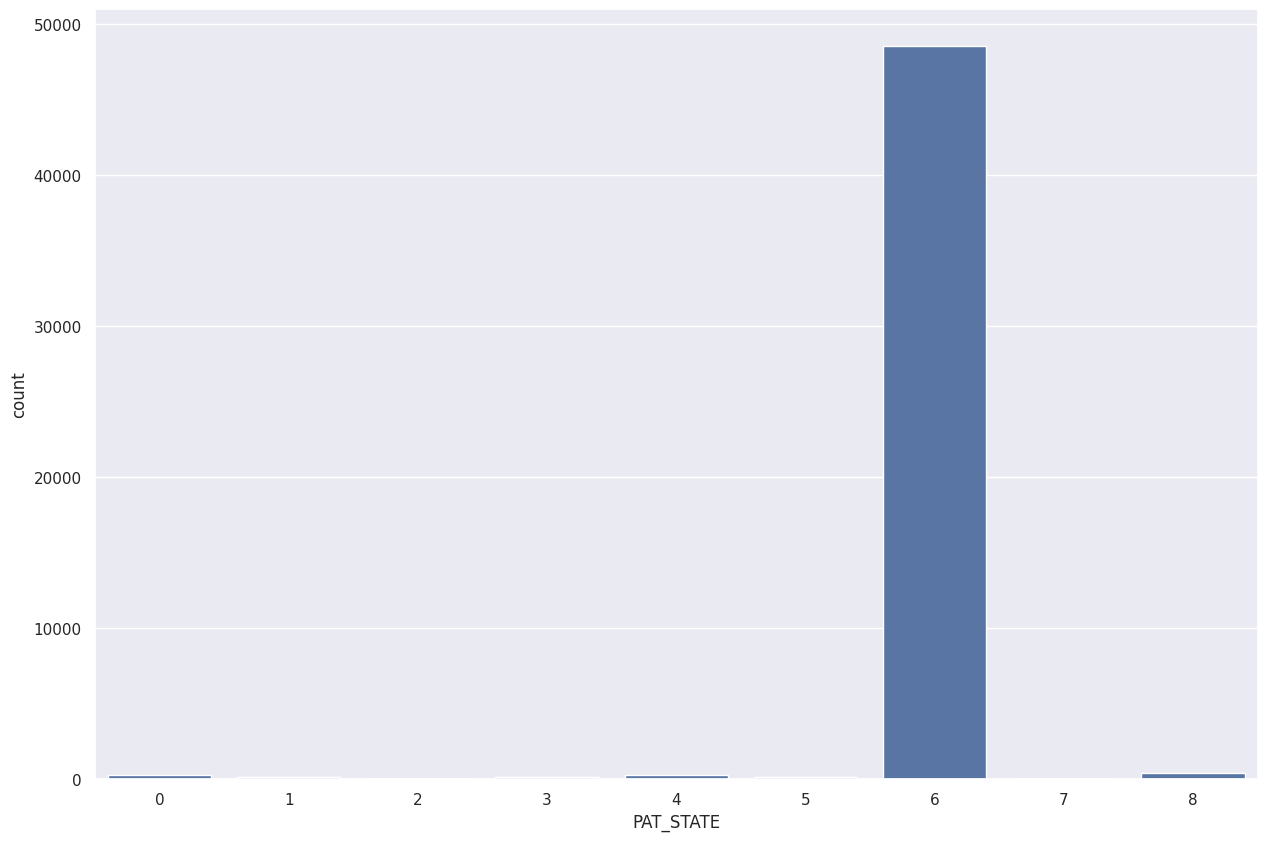

In [29]:
# after

display_countplot(data_filtered, 'PAT_STATE')

# PAT_STATUS             

Description: Code indicating patient status as of the ending date of service for the period of care reported
<br>Coding Scheme: 
- 1 Discharged to home or self-care (routine discharge)
- 2 Discharged to other short term general hospital
- 3 Discharged to skilled nursing facility
- 4 Discharged to intermediate care facility
- 5 Discharged/transferred to a Designated Cancer Center or Children's Hospital (effective 10-1-2007)
- 6 Discharged to care of home health service
- 7 Left against medical advice
- 8 Discharged to care of Home IV provider
- 9 Admitted as inpatient to this hospital
- 20 Expired
- 30 Still patient
- 40 Expired at home
- 41 Expired in a medical facility
- 42 Expired, place unknown
- 43 Discharged/transferred to federal health care facility
- 50 Discharged to hospice–home
- 51 Discharged to hospice–medical facility
- 61 Discharged/transferred within this institution to Medicare-approved swing bed
- 62 Discharged/transferred to inpatient rehabilitation facility
- 63 Discharged/transferred to Medicare-certified long term care hospital
- 64 Discharged/transferred to Medicaid-certified nursing facility
- 65 Discharged/transferred to psychiatric hospital or psychiatric distinct part of a hospital
- 66 Discharged/transferred to Critical Access Hospital (CAH)
- 71 Discharged/transferred to other outpatient service
- 72 Discharged/transferred to institution outpatient
- ` Invalid 

count     50000
unique       23
top           1
freq      37898
Name: PAT_STATUS, dtype: object
NA: 0.0%
Unique: 23
['6' '1' '3' '2' '51' '62' '50' '20' '65' '5' '63' '7' '9' '4' 'INVALID'
 '66' '61' '64' '30' '43' '8' '41' '40']


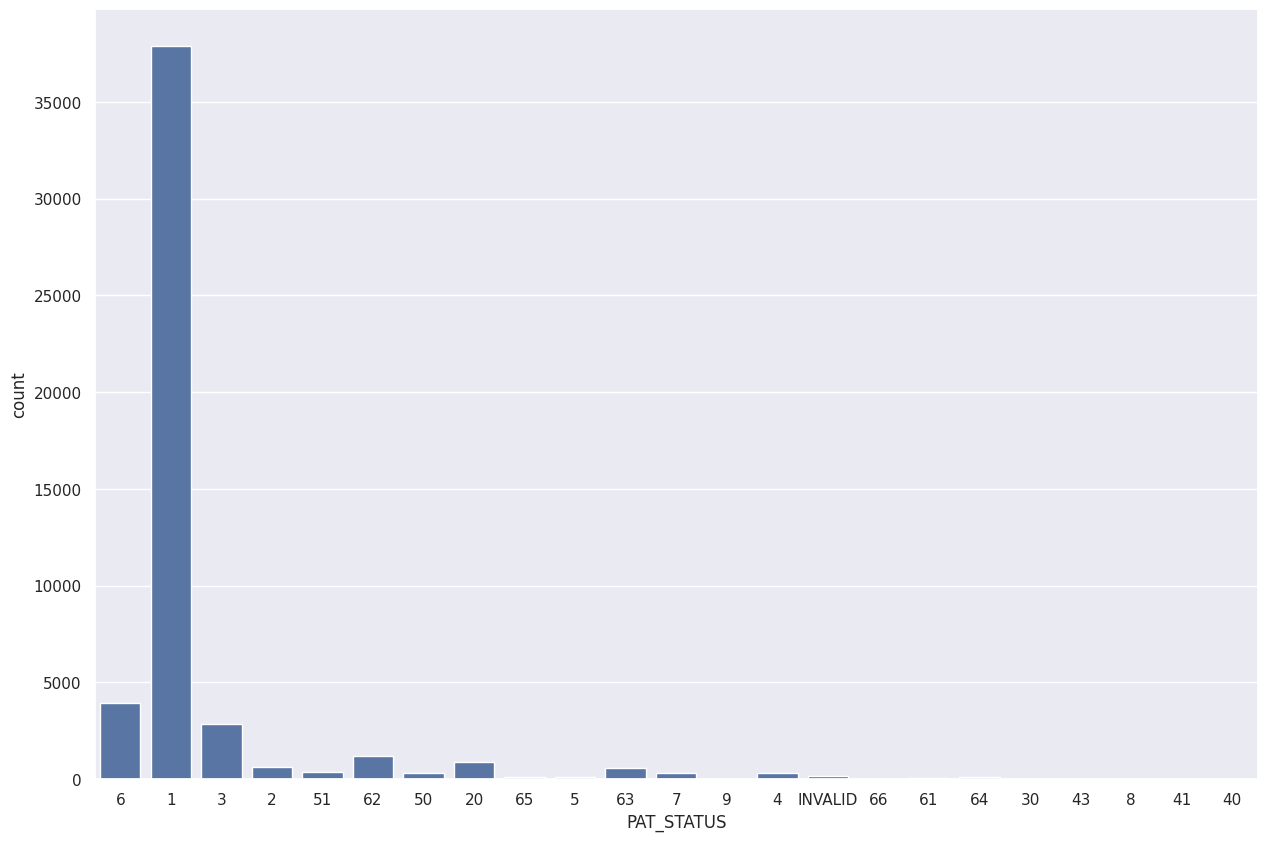

In [30]:
display_countplot(data_filtered, 'PAT_STATUS')

In [31]:
# convert invalid as 0

colname = 'PAT_STATUS'
data_filtered.loc[(data_filtered[colname] == 'INVALID'), colname] = 0
data_filtered[colname].unique()

# data_filtered_train.loc[(data_filtered_train[colname] == 'INVALID'), colname] = 0
# data_filtered_train[colname].unique()

# data_filtered_val.loc[(data_filtered_val[colname] == 'INVALID'), colname] = 0
# data_filtered_val[colname].unique()

# data_filtered_test.loc[(data_filtered_test[colname] == 'INVALID'), colname] = 0
# data_filtered_test[colname].unique()

array(['6', '1', '3', '2', '51', '62', '50', '20', '65', '5', '63', '7',
       '9', '4', 0, '66', '61', '64', '30', '43', '8', '41', '40'],
      dtype=object)

In [32]:
# convert string values to numerical values

data_filtered[colname] = pd.to_numeric(data_filtered[colname])
print(data_filtered[colname].unique())

# data_filtered_train[colname] = pd.to_numeric(data_filtered_train[colname])
# print(data_filtered_train[colname].unique())

# data_filtered_val[colname] = pd.to_numeric(data_filtered_val[colname])
# print(data_filtered_val[colname].unique())

# data_filtered_test[colname] = pd.to_numeric(data_filtered_test[colname])
# print(data_filtered_test[colname].unique())

[ 6  1  3  2 51 62 50 20 65  5 63  7  9  4  0 66 61 64 30 43  8 41 40]


In [33]:
# encode categories

encode_variables(dataframe=data_filtered, column_name=colname, path=output_path)

# encode_variables(dataframe=data_filtered_train, column_name=colname, path=output_train)
# encode_variables(dataframe=data_filtered_val, column_name=colname, path=output_val)
# encode_variables(dataframe=data_filtered_test, column_name=colname, path=output_test)

Encoded classes: [ 0  1  2  3  4  5  6  7  8  9 20 30 40 41 43 50 51 61 62 63 64 65 66]
Unique values after encoding: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
Encoded values of the top rows: [6 1 1 3 1]


count    50000.000000
mean         2.704680
std          4.158429
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         22.000000
Name: PAT_STATUS, dtype: float64
NA: 0.0%
Unique: 23
[ 6  1  3  2 16 18 15 10 21  5 19  7  9  4  0 22 17 20 11 14  8 13 12]


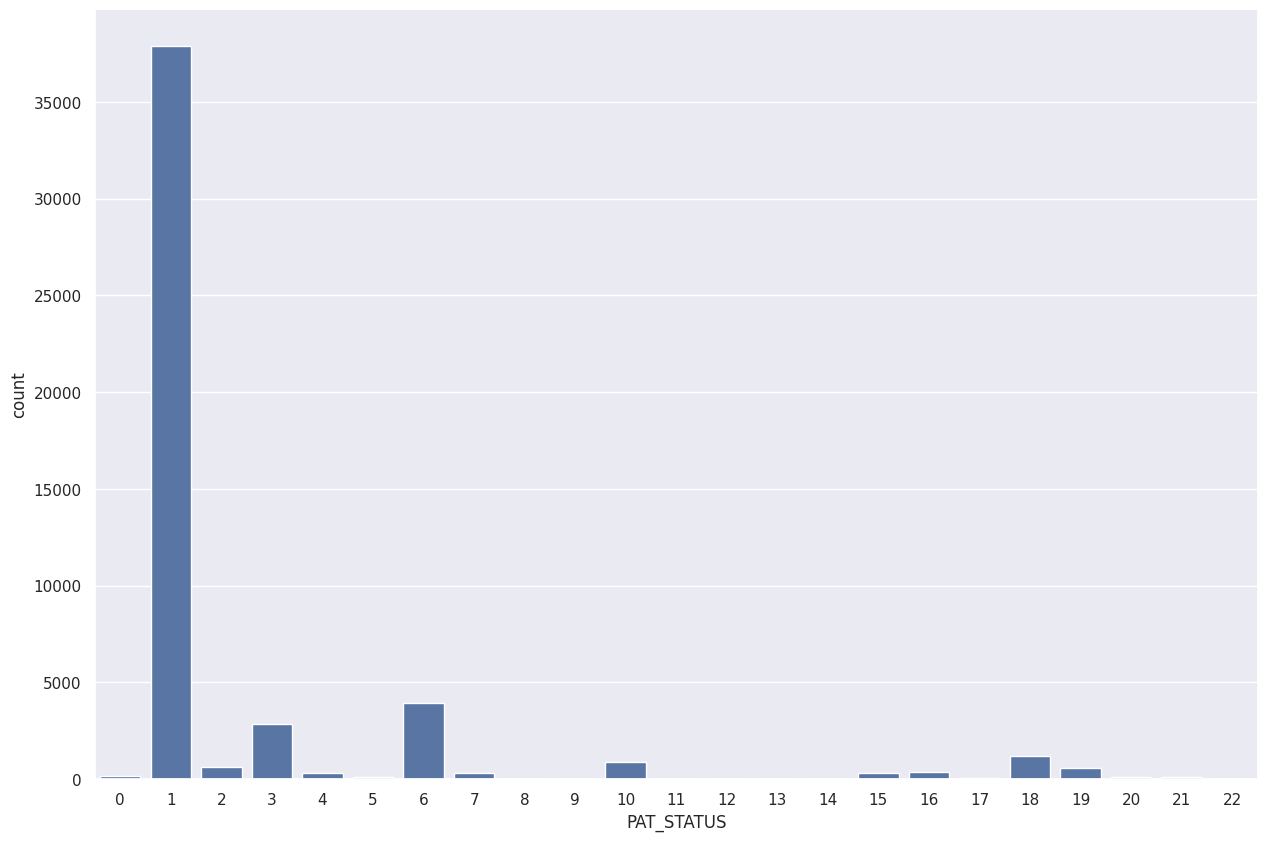

In [34]:
# after

display_countplot(dataframe=data_filtered, column_name=colname)

# SEX_CODE        

Description: Gender of the patient as recorded at date of admission or start of care.
<br>Suppression: Code is suppressed if an ICD-9-CM code indicates drug or alcohol use or an HIV diagnosis. If
a hospital has fewer than 5 patients of a particular gender, including unknown, Provider ID is
‘999998’ and Hospital Name and Patient ZIP Code are blank for those patients.
<br>Coding Scheme: 
- M Male
- F Female
- U Unknown
- ` Invalid

count     50000
unique        3
top           F
freq      30071
Name: SEX_CODE, dtype: object
NA: 0.0%
Unique: 3
['F' 'M' 'U']


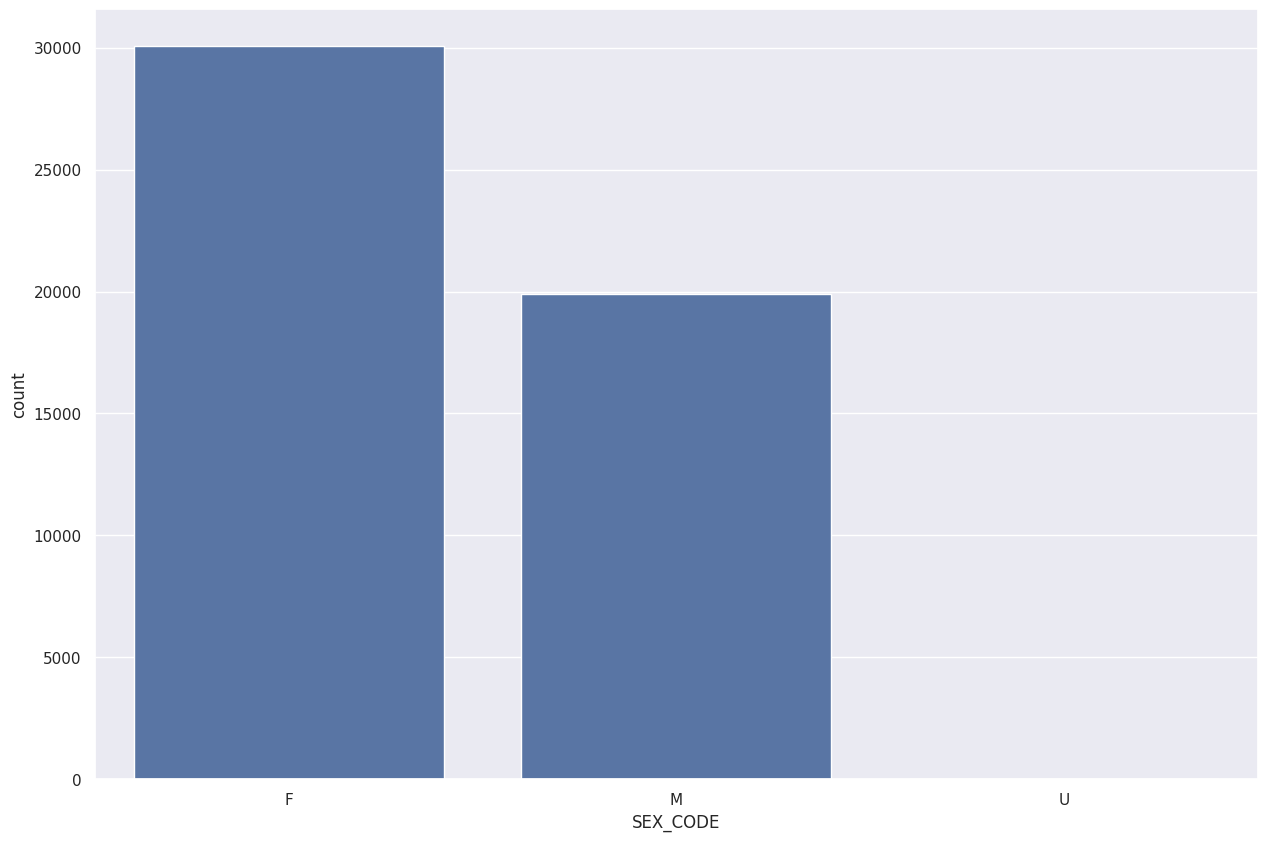

In [35]:
display_countplot(data_filtered, 'SEX_CODE')

In [36]:
# encode categories

colname = 'SEX_CODE'
encode_variables(dataframe=data_filtered, column_name=colname, path=output_path)

# encode_variables(dataframe=data_filtered_train, column_name=colname, path=output_train)
# encode_variables(dataframe=data_filtered_val, column_name=colname, path=output_val)
# encode_variables(dataframe=data_filtered_test, column_name=colname, path=output_test)


Encoded classes: ['F' 'M' 'U']
Unique values after encoding: [0 1 2]
Encoded values of the top rows: [0 0 0 1 1]


In [37]:
# there are 11 rows for value 'unknown'

data_filtered[data_filtered['SEX_CODE'] == 2].shape

(11, 20)

count    50000.000000
mean         0.398800
std          0.490105
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          2.000000
Name: SEX_CODE, dtype: float64
NA: 0.0%
Unique: 3
[0 1 2]


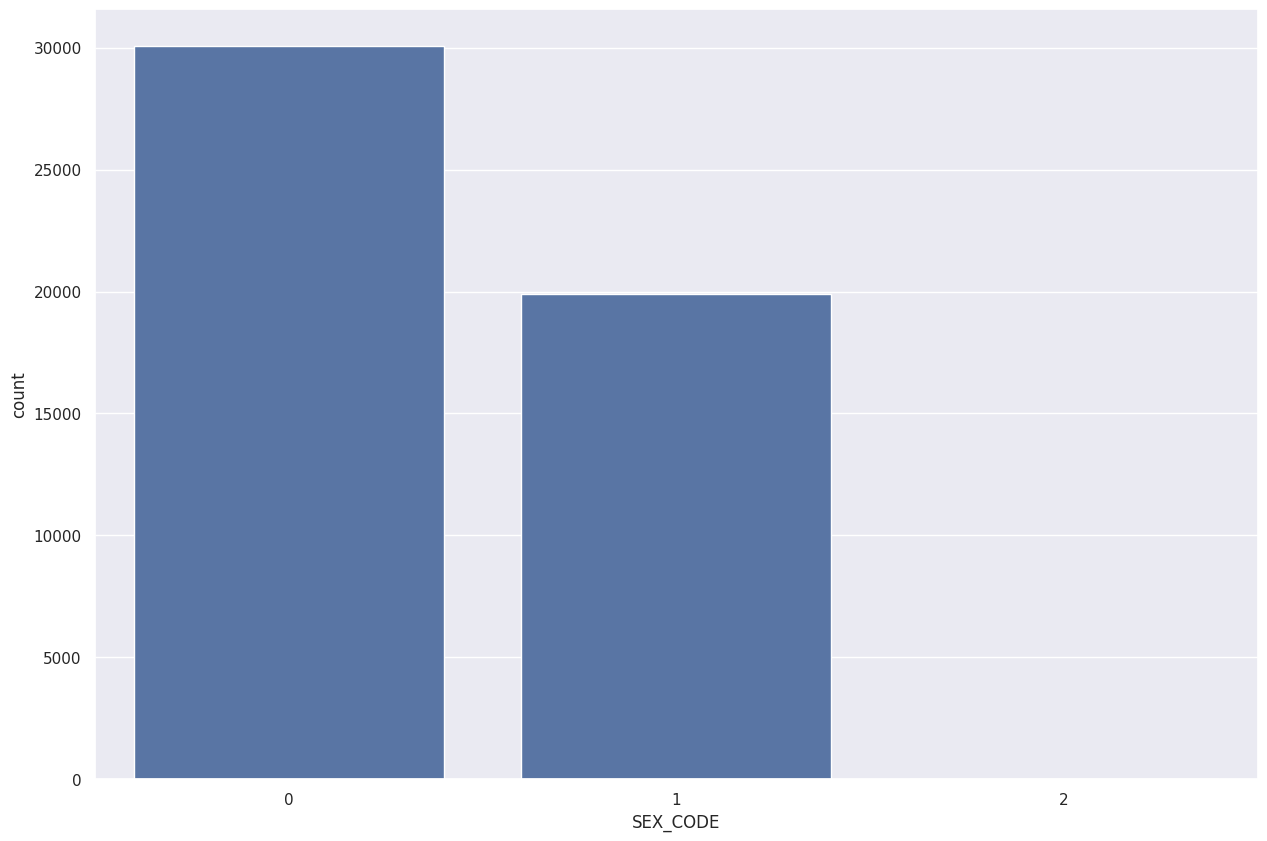

In [38]:
# after

display_countplot(dataframe=data_filtered, column_name=colname)

# RACE           

Description: Code indicating the patient’s race.
<br>Suppression: If a hospital has fewer than ten patients of one race that race is changed to ‘Other’ (code equals 5).
<br>Coding Scheme: 
- 1 American Indian/Eskimo/Aleut
- 2 Asian or Pacific Islander
- 3 Black
- 4 White
- 5 Other
- ` Invalid

count     50000
unique        6
top           4
freq      31389
Name: RACE, dtype: object
NA: 0.0%
Unique: 6
['4' '5' '3' '2' 'INVALID' '1']


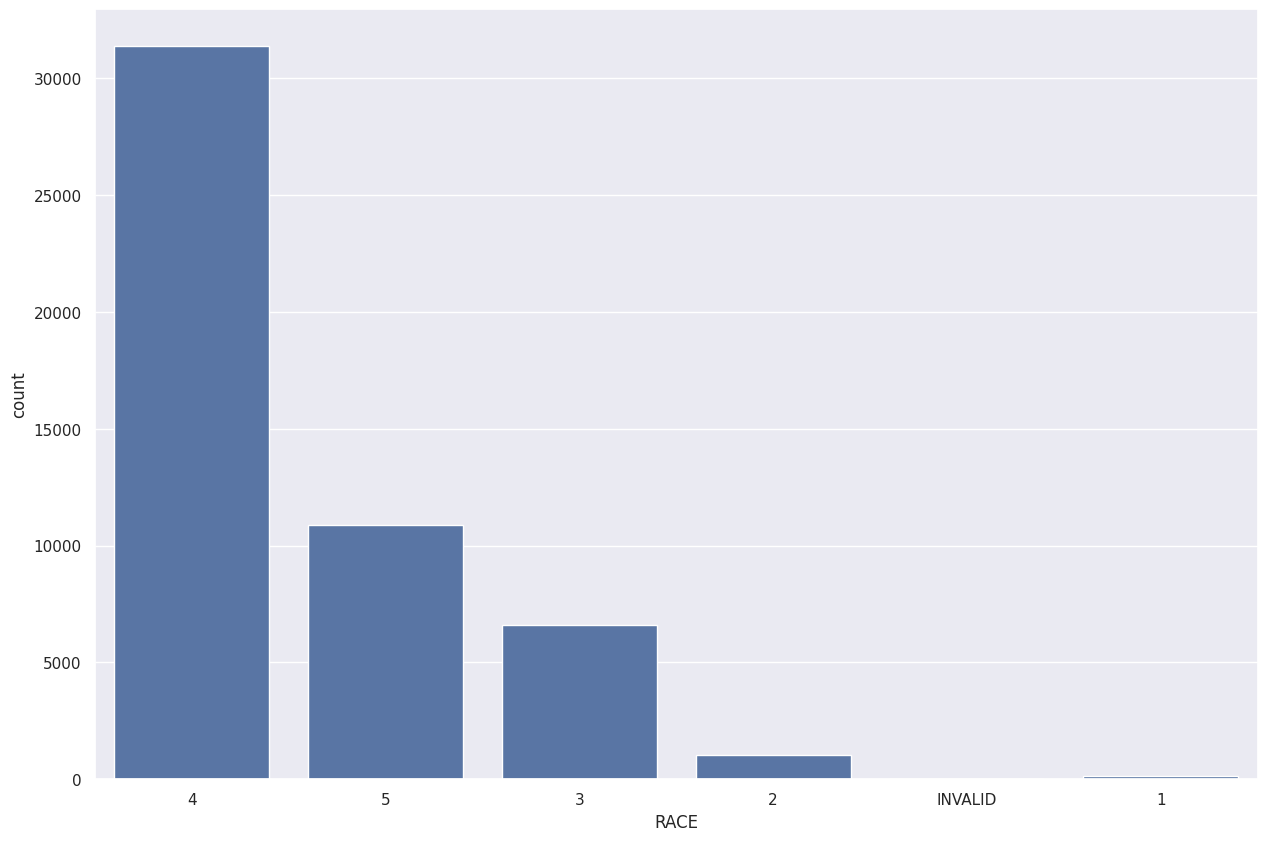

In [39]:
display_countplot(data_filtered, 'RACE')

In [40]:
# convert invalid as 0

colname = 'RACE'
data_filtered.loc[(data_filtered[colname] == 'INVALID'), colname] = 0
data_filtered[colname].unique()
# data_filtered_train.loc[(data_filtered_train[colname] == 'INVALID'), colname] = 0
# data_filtered_train[colname].unique()

# data_filtered_val.loc[(data_filtered_val[colname] == 'INVALID'), colname] = 0
# data_filtered_val[colname].unique()

# data_filtered_test.loc[(data_filtered_test[colname] == 'INVALID'), colname] = 0
# data_filtered_test[colname].unique()


array(['4', '5', '3', '2', 0, '1'], dtype=object)

In [41]:
# convert string values to numerical values

data_filtered[colname] = pd.to_numeric(data_filtered[colname])
data_filtered[colname].unique()

# data_filtered_train[colname] = pd.to_numeric(data_filtered_train[colname])
# data_filtered_train[colname].unique()

# data_filtered_val[colname] = pd.to_numeric(data_filtered_val[colname])
# data_filtered_val[colname].unique()

# data_filtered_test[colname] = pd.to_numeric(data_filtered_test[colname])
# data_filtered_test[colname].unique()


array([4, 5, 3, 2, 0, 1])

In [42]:
# encode categories

encode_variables(dataframe=data_filtered, column_name=colname, path=output_path)

# encode_variables(dataframe=data_filtered_train, column_name=colname, path=output_train)
# encode_variables(dataframe=data_filtered_val, column_name=colname, path=output_val)
# encode_variables(dataframe=data_filtered_test, column_name=colname, path=output_test)


Encoded classes: [0 1 2 3 4 5]
Unique values after encoding: [0 1 2 3 4 5]
Encoded values of the top rows: [4 4 4 4 4]


count    50000.000000
mean         4.036340
std          0.674469
min          0.000000
25%          4.000000
50%          4.000000
75%          4.000000
max          5.000000
Name: RACE, dtype: float64
NA: 0.0%
Unique: 6
[4 5 3 2 0 1]


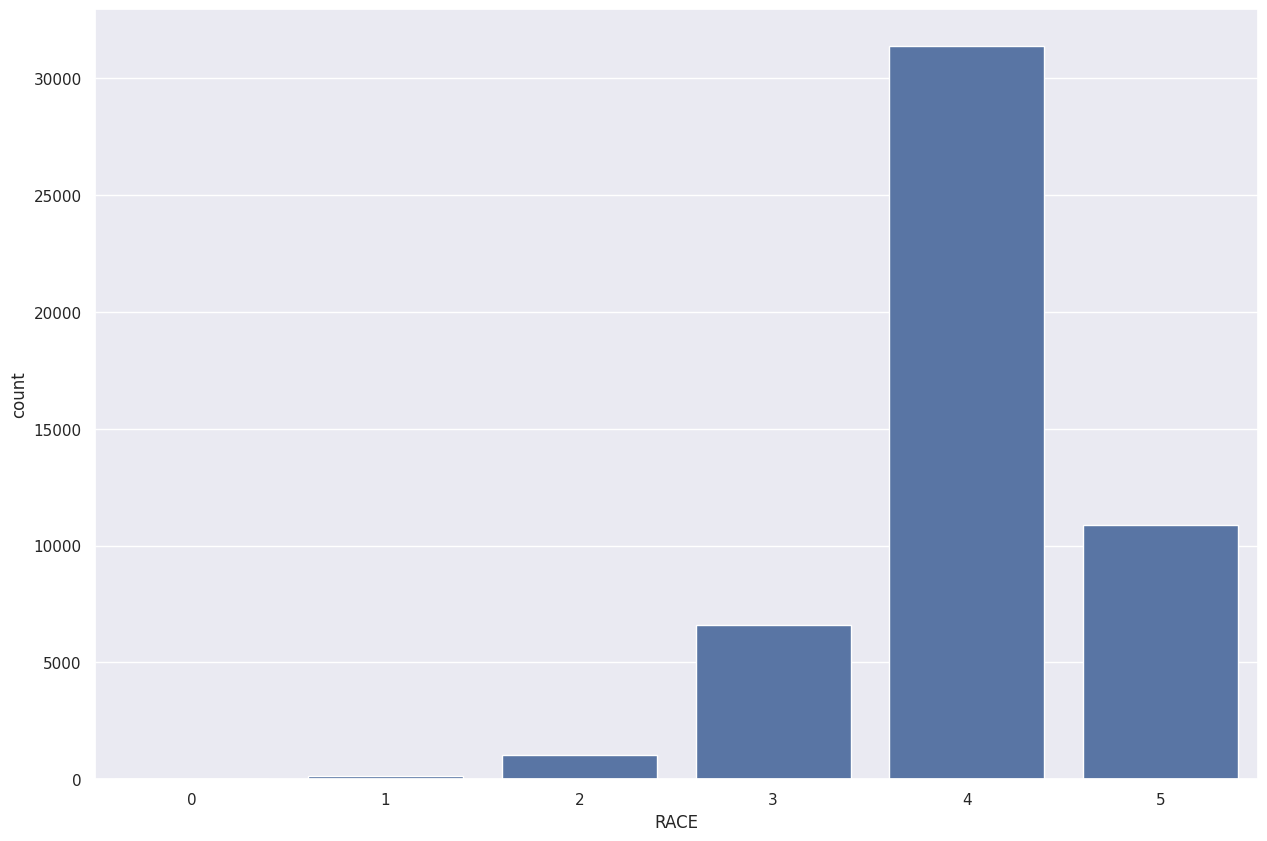

In [43]:
# after

display_countplot(dataframe=data_filtered, column_name=colname)

# ETHNICITY           

Description: Code indicating the Hispanic origin of the patient.
<br>Suppression: If a hospital has fewer than ten patients of one race the ethnicity of patients of that race is
suppressed (code is blank).
<br>Coding Scheme: 
- 1 Hispanic Origin
- 2 Not of Hispanic Origin
- ` Invalid

count     50000
unique        3
top           2
freq      35421
Name: ETHNICITY, dtype: object
NA: 0.0%
Unique: 3
['2' '1' 'INVALID']


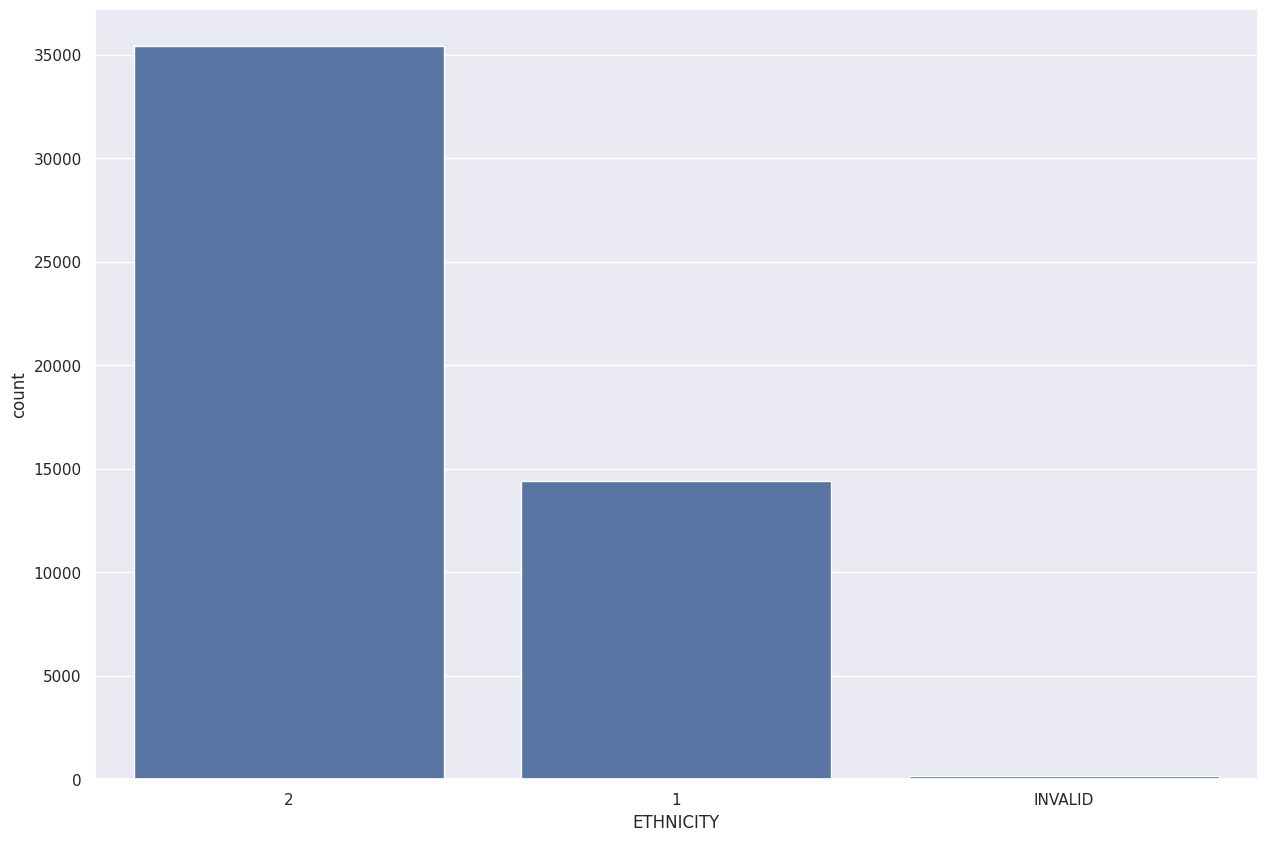

In [44]:
display_countplot(data_filtered, 'ETHNICITY')

In [45]:
# convert invalid as 0

colname = 'ETHNICITY'
data_filtered.loc[(data_filtered[colname] == 'INVALID'), colname] = 0
data_filtered[colname].unique()

# data_filtered_train.loc[(data_filtered_train[colname] == 'INVALID'), colname] = 0
# data_filtered_train[colname].unique()

# data_filtered_val.loc[(data_filtered_val[colname] == 'INVALID'), colname] = 0
# data_filtered_val[colname].unique()

# data_filtered_test.loc[(data_filtered_test[colname] == 'INVALID'), colname] = 0
# data_filtered_test[colname].unique()


array(['2', '1', 0], dtype=object)

In [46]:
# convert string values to numerical values

data_filtered[colname] = pd.to_numeric(data_filtered[colname])
data_filtered[colname].unique()

# data_filtered_train[colname] = pd.to_numeric(data_filtered_train[colname])
# data_filtered_train[colname].unique()

# data_filtered_val[colname] = pd.to_numeric(data_filtered_val[colname])
# data_filtered_val[colname].unique()

# data_filtered_test[colname] = pd.to_numeric(data_filtered_test[colname])
# data_filtered_test[colname].unique()


array([2, 1, 0])

In [47]:
# encode categories
# encode_variables(dataframe=data_filtered, column_name=colname)

encode_variables(dataframe=data_filtered, column_name=colname, path=output_path)

# encode_variables(dataframe=data_filtered_train, column_name=colname, path=output_train)
# encode_variables(dataframe=data_filtered_val, column_name=colname, path=output_val)
# encode_variables(dataframe=data_filtered_test, column_name=colname, path=output_test)

Encoded classes: [0 1 2]
Unique values after encoding: [0 1 2]
Encoded values of the top rows: [2 2 2 2 2]


count    50000.000000
mean         1.704820
std          0.463954
min          0.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: ETHNICITY, dtype: float64
NA: 0.0%
Unique: 3
[2 1 0]


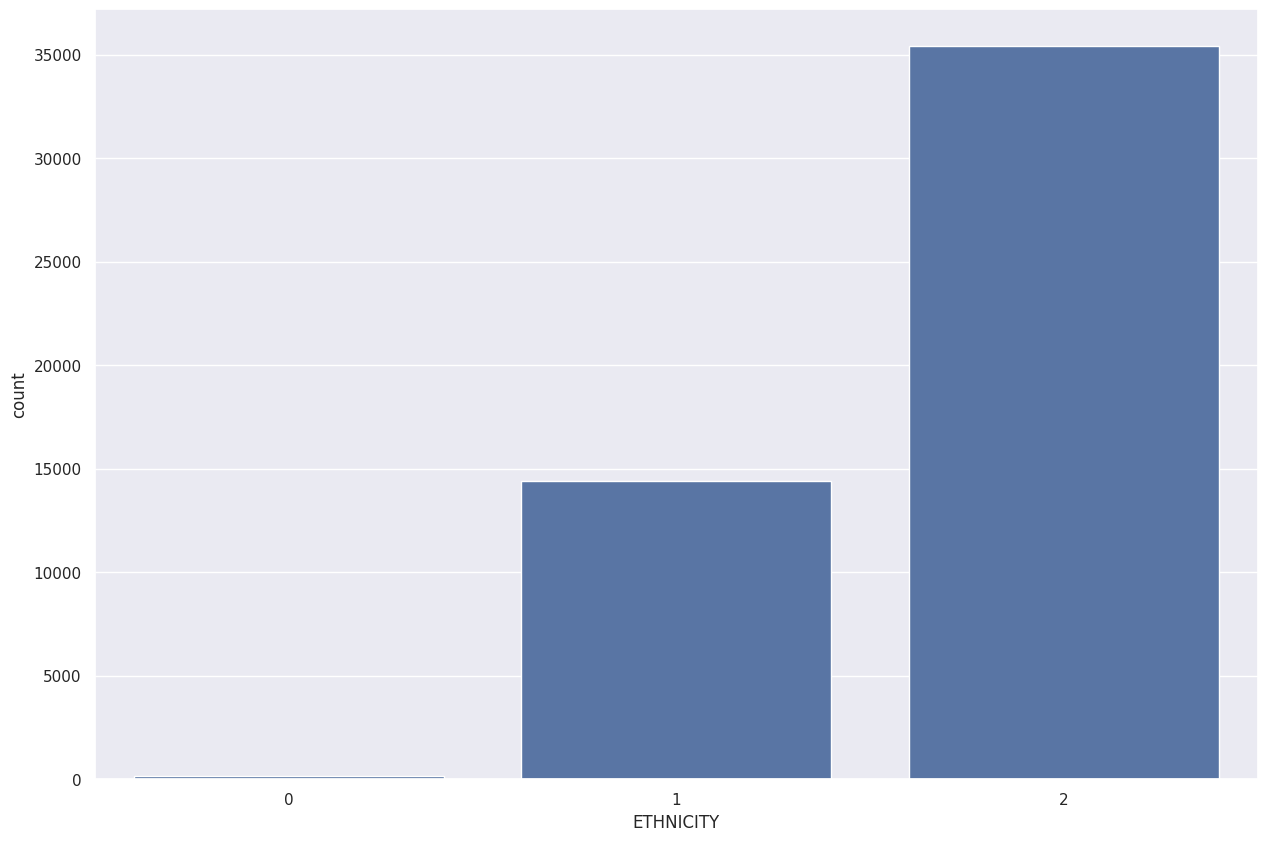

In [48]:
# after

display_countplot(dataframe=data_filtered, column_name=colname)

# ADMIT_WEEKDAY                 

Description: Code indicating day of week patient is admitted
<br>Coding Scheme: 
- 1 Monday 
- 2 Tuesday 
- 3 Wednesday 
- 4 Thursday 
- 5 Friday
- 6 Saturday
- 7 Sunday
- ` Invalid

count    50000.00000
mean         3.58816
std          1.89540
min          1.00000
25%          2.00000
50%          3.00000
75%          5.00000
max          7.00000
Name: ADMIT_WEEKDAY, dtype: float64
NA: 0.0%
Unique: 7
[3 4 1 2 7 5 6]


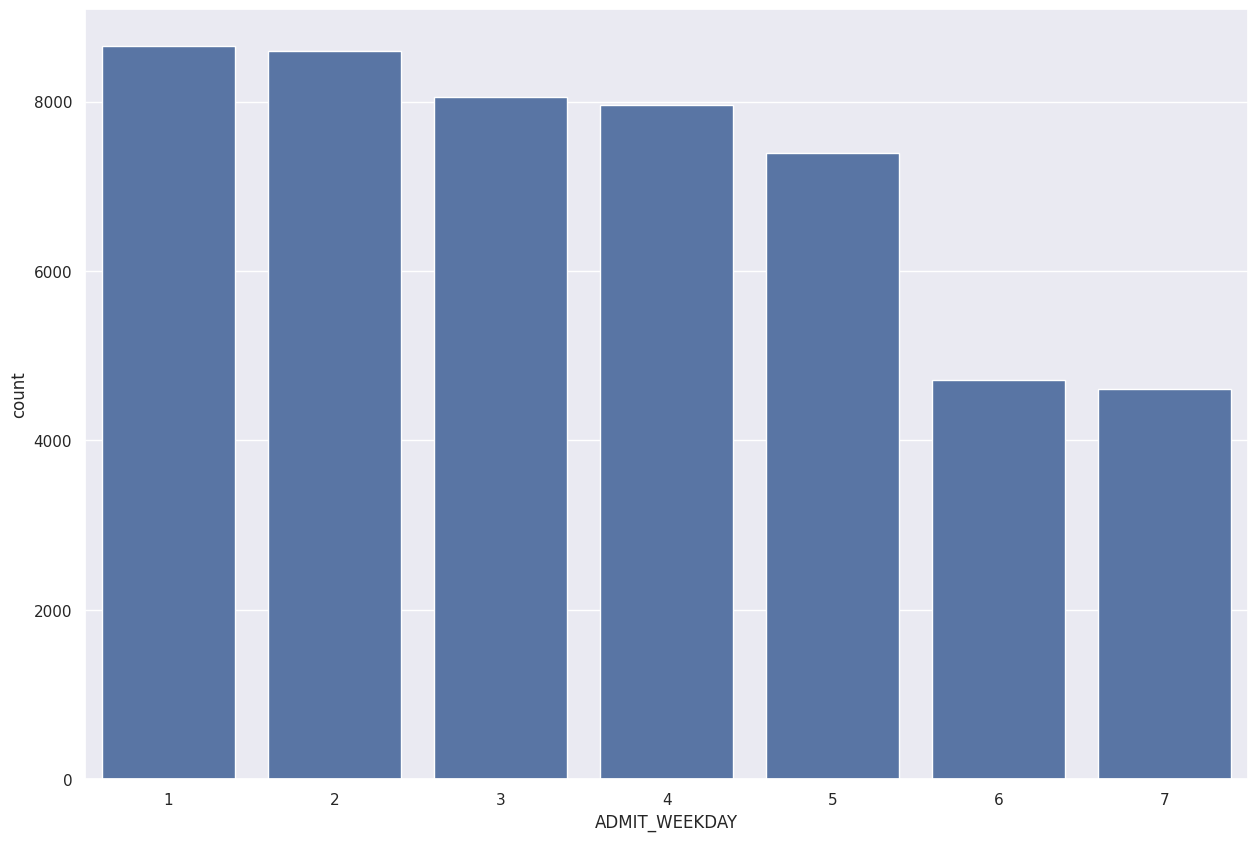

In [49]:
display_countplot(data_filtered, 'ADMIT_WEEKDAY')

In [50]:
# encode categories

colname = 'ADMIT_WEEKDAY'
# encode_variables(dataframe=data_filtered, column_name=colname)

encode_variables(dataframe=data_filtered, column_name=colname, path=output_path)

# encode_variables(dataframe=data_filtered_train, column_name=colname, path=output_train)
# encode_variables(dataframe=data_filtered_val, column_name=colname, path=output_val)
# encode_variables(dataframe=data_filtered_test, column_name=colname, path=output_test)

Encoded classes: [1 2 3 4 5 6 7]
Unique values after encoding: [0 1 2 3 4 5 6]
Encoded values of the top rows: [2 3 0 0 2]


count    50000.00000
mean         2.58816
std          1.89540
min          0.00000
25%          1.00000
50%          2.00000
75%          4.00000
max          6.00000
Name: ADMIT_WEEKDAY, dtype: float64
NA: 0.0%
Unique: 7
[2 3 0 1 6 4 5]


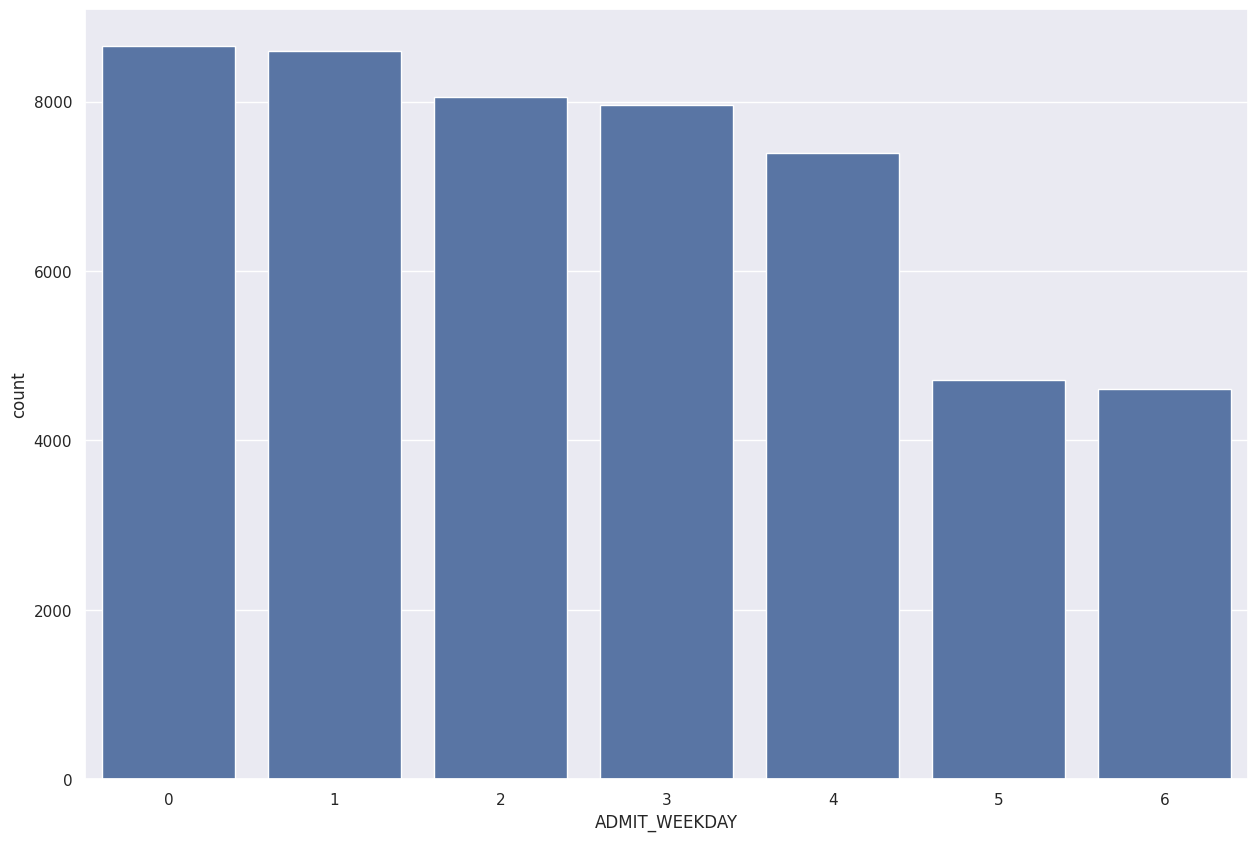

In [51]:
# after

display_countplot(dataframe=data_filtered, column_name=colname)

# PAT_AGE               

Description: Code indicating age of patient in days or years on date of discharge.
<br>Coding Scheme: 
- 00 1-28 days 
- 01 29-365 days 
- 02 1-4 years 
- 03 5-9 
- 04 10-14 
- 05 15-17 
- 06 18-19 
- 07 20-24 
- 08 25-29 
- 09 30-34 
- 10 35-39 
- 11 40-44 
- 12 45-49 
- 13 50-54 
- 14 55-59 
- 15 60-64 
- 16 65-69 
- 17 70-74 
- 18 75-79 
- 19 80-84
- 20 85-89
- 21 90+
- HIV and drug/alcohol use patients:
- 22 0-17
- 23 18-44
- 24 45-64
- 25 65-74
- 26 75+
- ` Invalid

count    50000.000000
mean         9.726160
std          7.466049
min          0.000000
25%          1.000000
50%         12.000000
75%         16.000000
max         21.000000
Name: PAT_AGE, dtype: float64
NA: 0.0%
Unique: 18
[16  1 11 18 14 17 15 12 21 20 13 10 19  0  9  8  7  6]


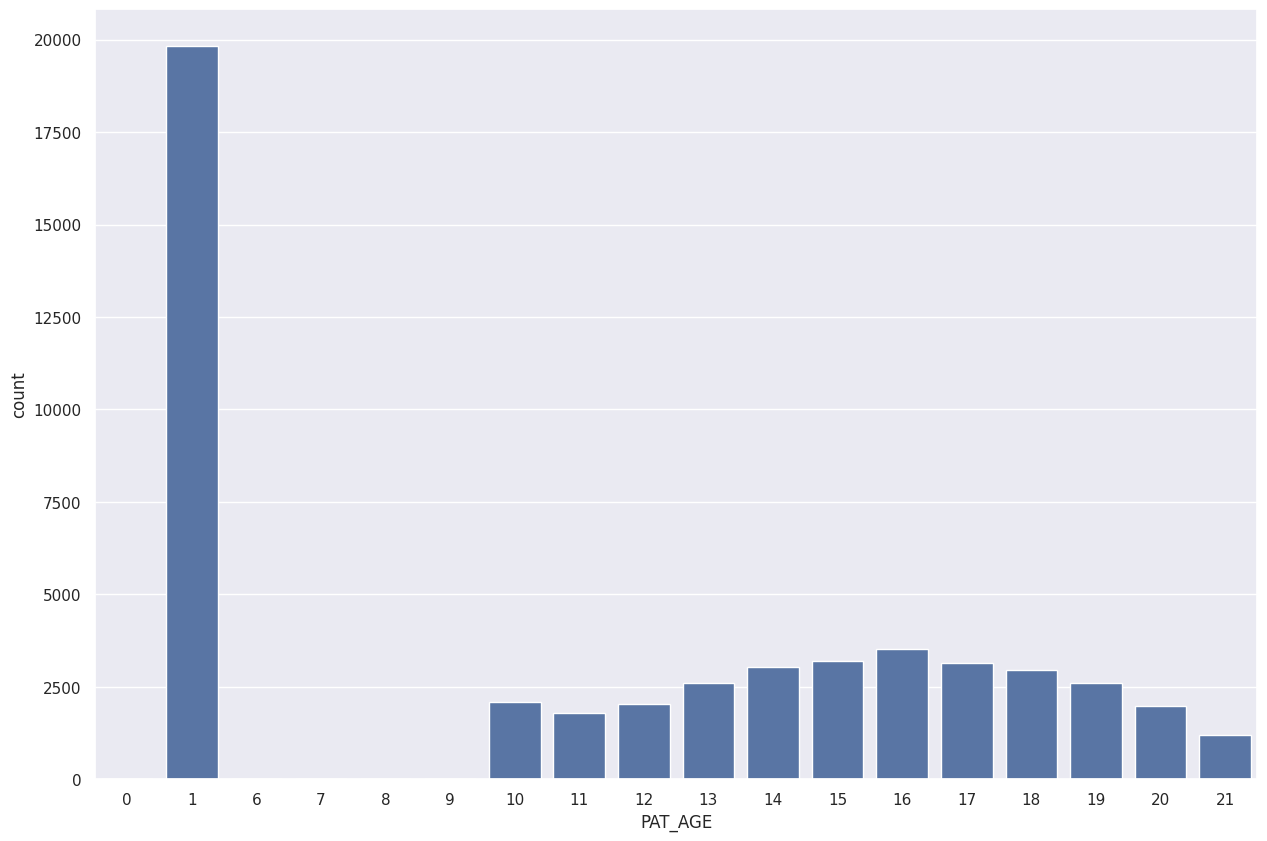

In [52]:
display_countplot(data_filtered, 'PAT_AGE')

In [53]:
# encode categories

colname = 'PAT_AGE'
# encode_variables(dataframe=data_filtered, column_name=colname)

encode_variables(dataframe=data_filtered, column_name=colname, path=output_path)

# encode_variables(dataframe=data_filtered_train, column_name=colname, path=output_train)
# encode_variables(dataframe=data_filtered_val, column_name=colname, path=output_val)
# encode_variables(dataframe=data_filtered_test, column_name=colname, path=output_test)

Encoded classes: [ 0  1  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Unique values after encoding: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Encoded values of the top rows: [12  1  7 14 12]


count    50000.00000
mean         7.31280
std          5.64618
min          0.00000
25%          1.00000
50%          8.00000
75%         12.00000
max         17.00000
Name: PAT_AGE, dtype: float64
NA: 0.0%
Unique: 18
[12  1  7 14 10 13 11  8 17 16  9  6 15  0  5  4  3  2]


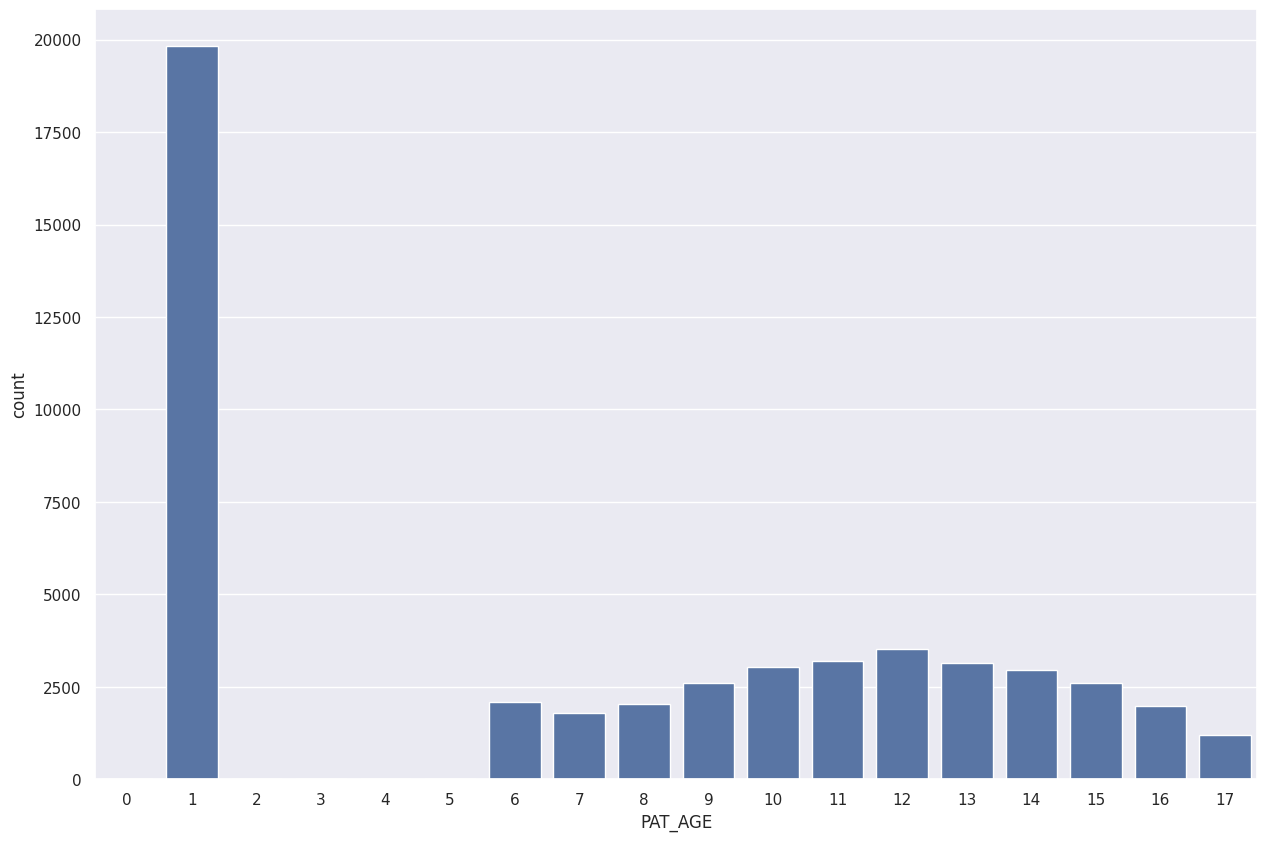

In [54]:
# after

display_countplot(data_filtered, 'PAT_AGE')

# RISK_MORTALITY       

Description: Assignment of a risk of mortality score from the All Patient Refined (APR) Diagnosis Related
Group (DRG) from the 3M APR-DRG Grouper. Indicates the likelihood of dying.
<br>Coding Scheme: 
- 1 Minor
- 2 Moderate
- 3 Major
- 4 Extreme 

count    50000.000000
mean         1.602840
std          0.886476
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: RISK_MORTALITY, dtype: float64
NA: 0.0%
Unique: 5
[1 2 3 4 0]


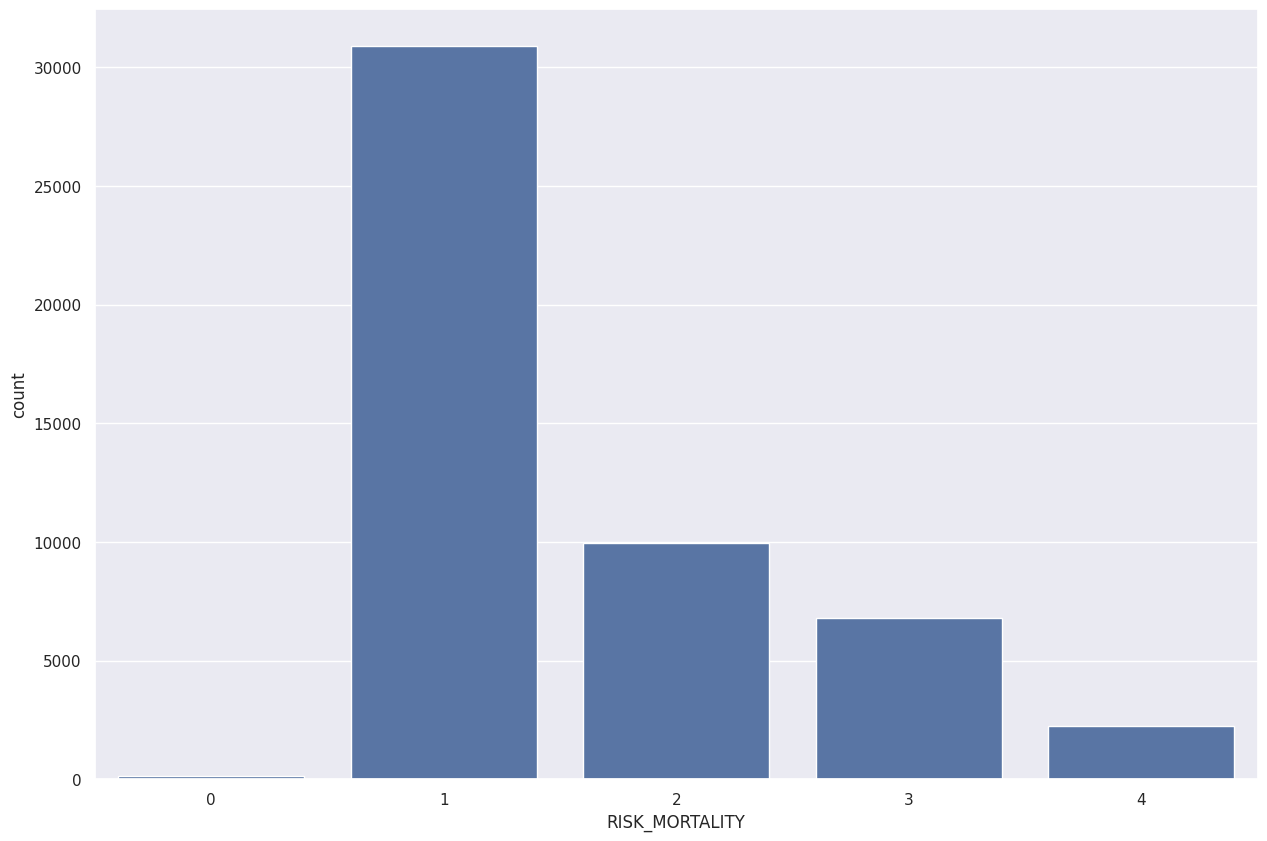

In [55]:
display_countplot(data_filtered, 'RISK_MORTALITY')

In [56]:
# encode categories

colname = 'RISK_MORTALITY'
# encode_variables(dataframe=data_filtered, column_name=colname)

encode_variables(dataframe=data_filtered, column_name=colname, path=output_path)

# encode_variables(dataframe=data_filtered_train, column_name=colname, path=output_train)
# encode_variables(dataframe=data_filtered_val, column_name=colname, path=output_val)
# encode_variables(dataframe=data_filtered_test, column_name=colname, path=output_test)

Encoded classes: [0 1 2 3 4]
Unique values after encoding: [0 1 2 3 4]
Encoded values of the top rows: [1 1 1 2 3]


count    50000.000000
mean         1.602840
std          0.886476
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: RISK_MORTALITY, dtype: float64
NA: 0.0%
Unique: 5
[1 2 3 4 0]


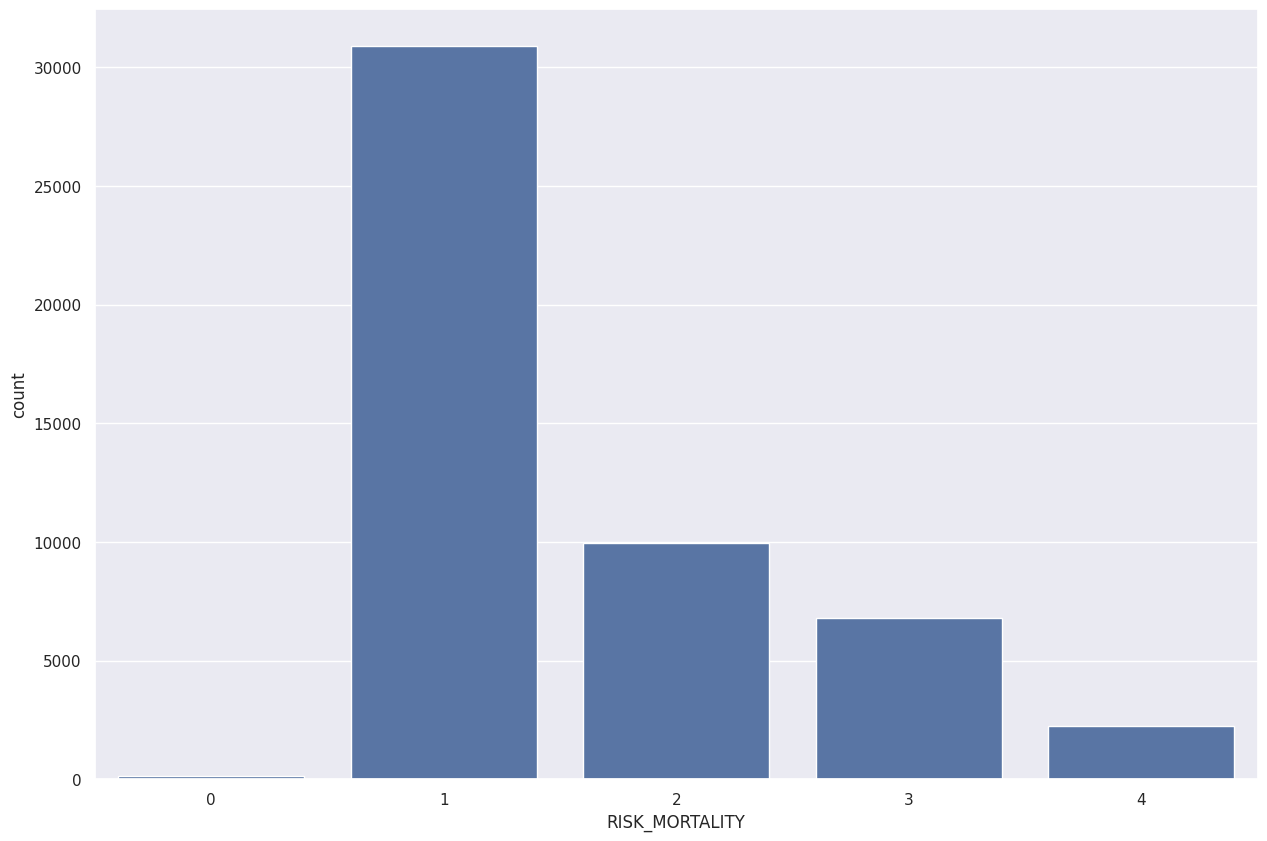

In [57]:
# after

display_countplot(dataframe=data_filtered, column_name=colname)

# ILLNESS_SEVERITY          
Description: Assignment of a severity of illness score from the All Patient Refined (APR) Diagnosis Related Group (DRG) from the 3M APR-DRG Grouper. Indicates the extent of physiologic decompensation.
<br>Coding Scheme: 
- 1 Minor
- 2 Moderate
- 3 Major
- 4 Extreme

count    50000.000000
mean         1.938020
std          0.917821
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: ILLNESS_SEVERITY, dtype: float64
NA: 0.0%
Unique: 5
[1 3 2 4 0]


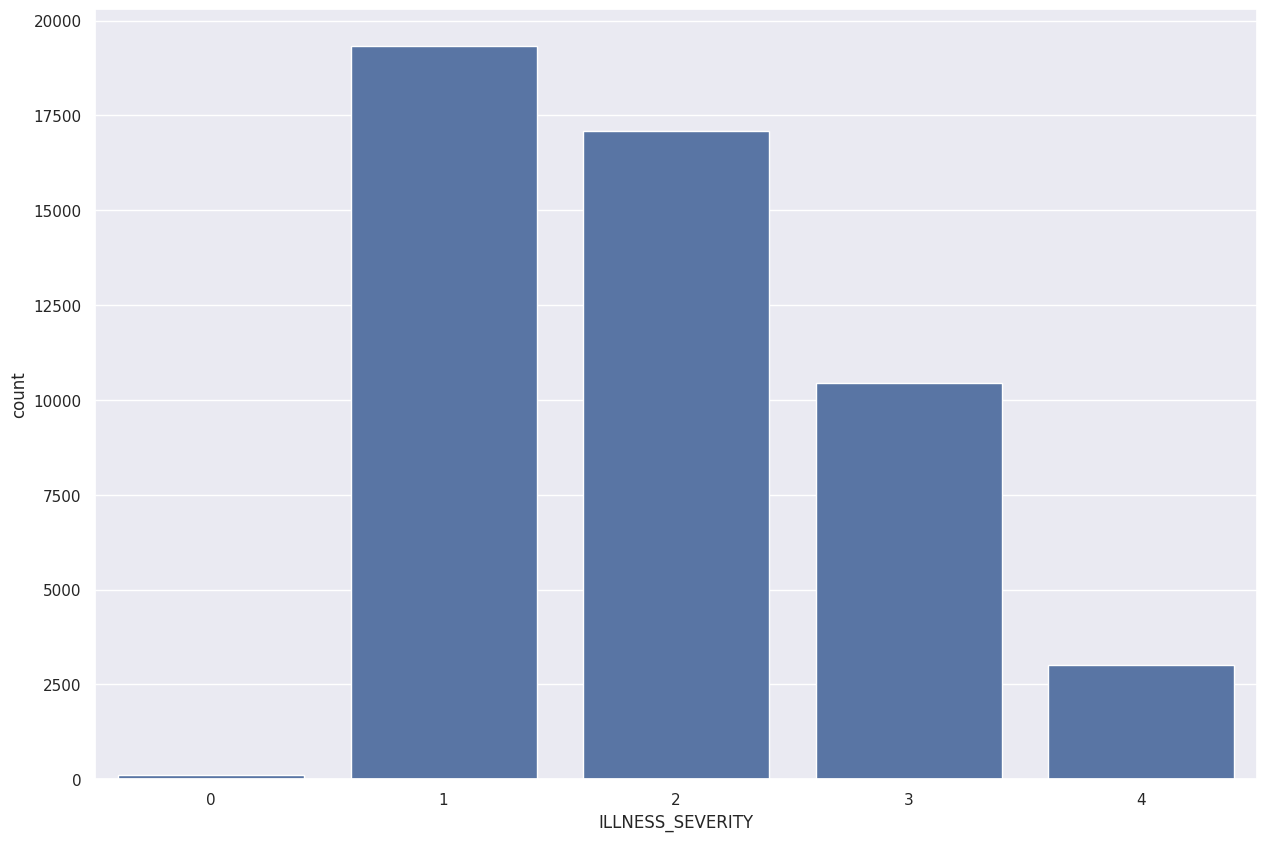

In [58]:
display_countplot(data_filtered, 'ILLNESS_SEVERITY')

In [59]:
# encode categories

colname = 'ILLNESS_SEVERITY'
# encode_variables(dataframe=data_filtered, column_name=colname)

encode_variables(dataframe=data_filtered, column_name=colname, path=output_path)

# encode_variables(dataframe=data_filtered_train, column_name=colname, path=output_train)
# encode_variables(dataframe=data_filtered_val, column_name=colname, path=output_val)
# encode_variables(dataframe=data_filtered_test, column_name=colname, path=output_test)

Encoded classes: [0 1 2 3 4]
Unique values after encoding: [0 1 2 3 4]
Encoded values of the top rows: [1 1 1 1 3]


count    50000.000000
mean         1.938020
std          0.917821
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: ILLNESS_SEVERITY, dtype: float64
NA: 0.0%
Unique: 5
[1 3 2 4 0]


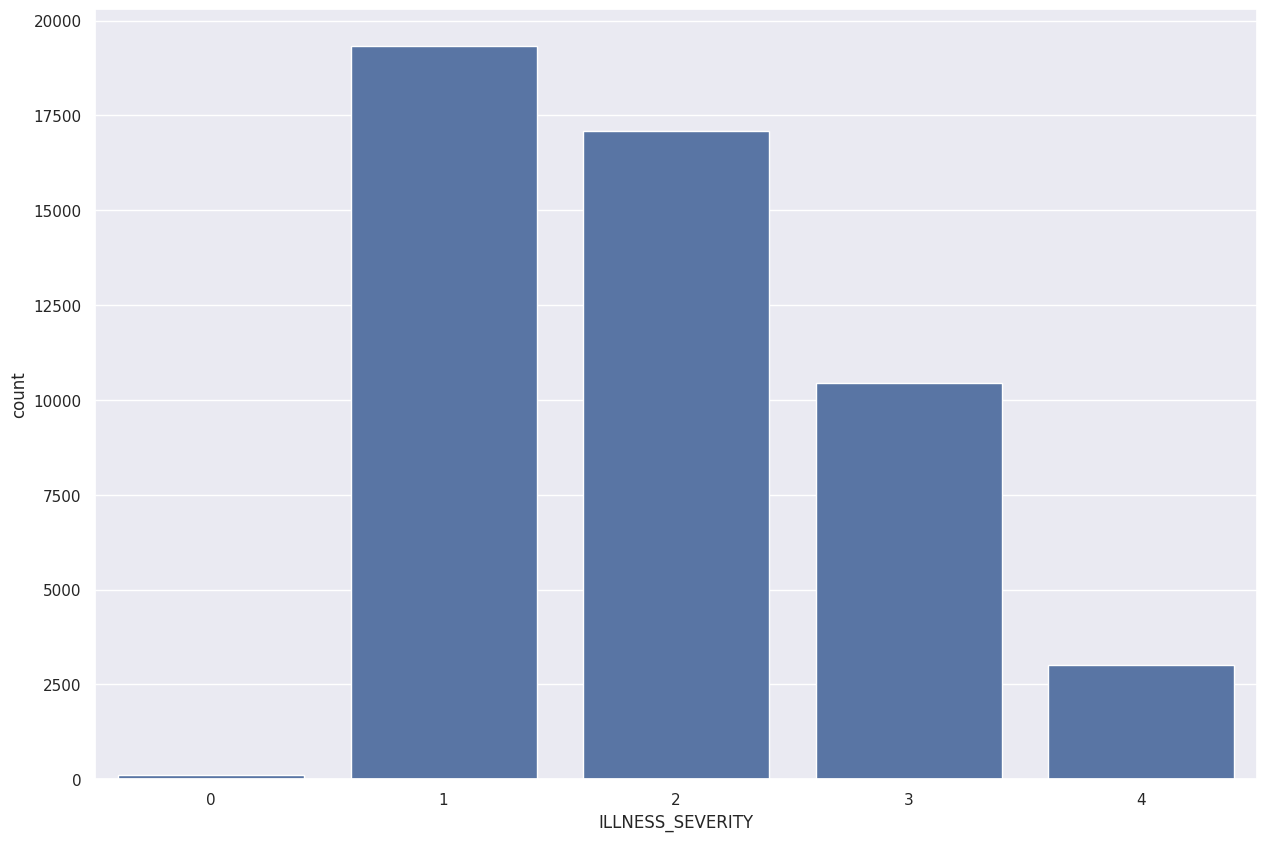

In [60]:
# after

display_countplot(dataframe=data_filtered, column_name=colname)

# LENGTH_OF_STAY   

Description: Length of stay in days equals Statement covers period through date minus Admission/start of care date. The minimum length of stay is 1 day. The maximum is 9999 days. 

count    50000.000000
mean         5.174160
std         10.406651
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        986.000000
Name: LENGTH_OF_STAY, dtype: float64
NA: 0.0%
Unique: 145


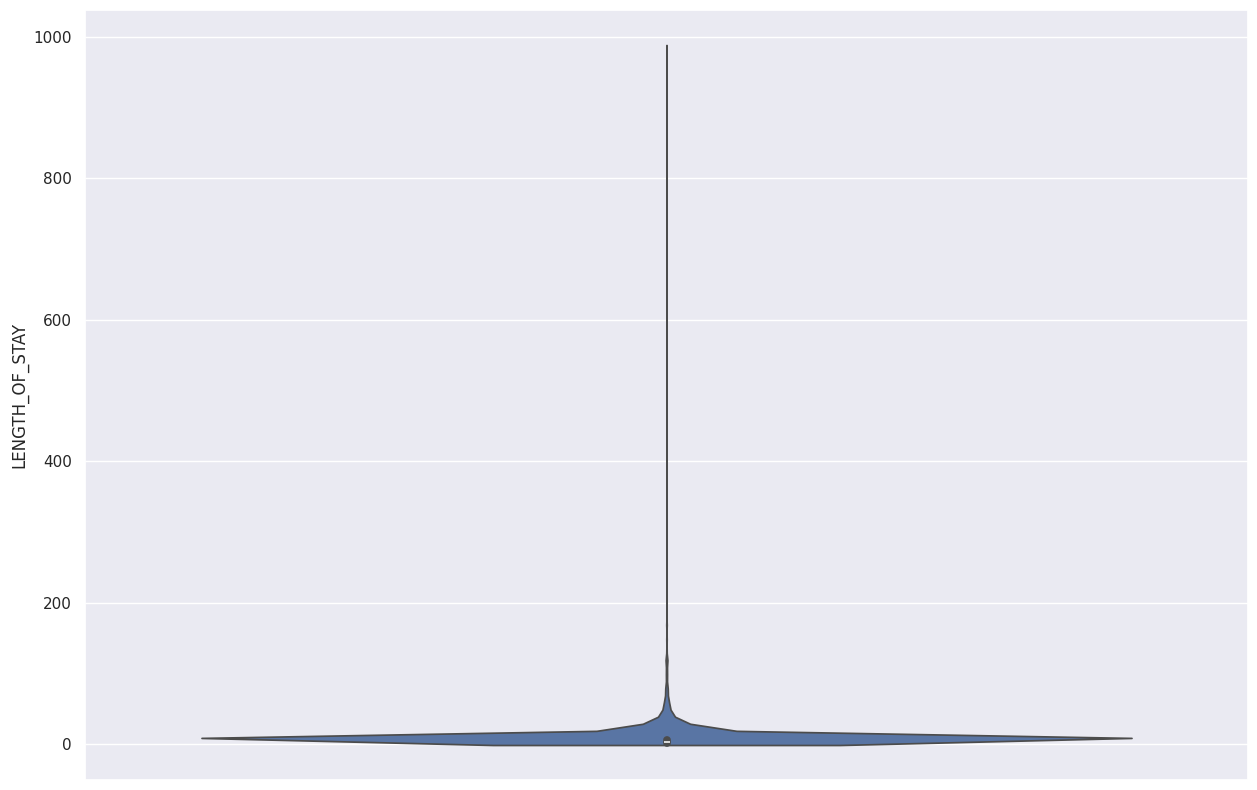

In [61]:
display_countplot(data_filtered, 'LENGTH_OF_STAY', is_vertical=True)

In [62]:
# convert float to integers

colname = 'LENGTH_OF_STAY'
data_filtered[colname] = data_filtered[colname].astype(int)

# data_filtered_train[colname] = data_filtered_train[colname].astype(int)
# data_filtered_val[colname] = data_filtered_val[colname].astype(int)
# data_filtered_test[colname] = data_filtered_test[colname].astype(int)


In [63]:
# square root transformation (use value **2 to revert back)

data_filtered[colname] = np.sqrt(data_filtered[colname])

# data_filtered_train[colname] = np.sqrt(data_filtered_train[colname])
# data_filtered_val[colname] = np.sqrt(data_filtered_val[colname])
# data_filtered_test[colname] = np.sqrt(data_filtered_test[colname])


In [64]:
# normalize variable

normalize_variable(dataframe=data_filtered, column_name=colname, path=output_path)

# normalize_variable(dataframe=data_filtered_train, column_name=colname, path=output_train)
# normalize_variable(dataframe=data_filtered_val, column_name=colname, path=output_val)
# normalize_variable(dataframe=data_filtered_test, column_name=colname, path=output_test)

Original max value: [31.40063694]
Original min value: [1.]
Scaled values of the top rows: [[0.03289405]
 [0.01362516]
 [0.        ]
 [0.02408011]
 [0.02408011]]


count    50000.000000
mean         0.032818
std          0.035785
min          0.000000
25%          0.013625
50%          0.024080
75%          0.040659
max          1.000000
Name: LENGTH_OF_STAY, dtype: float64
NA: 0.0%
Unique: 145


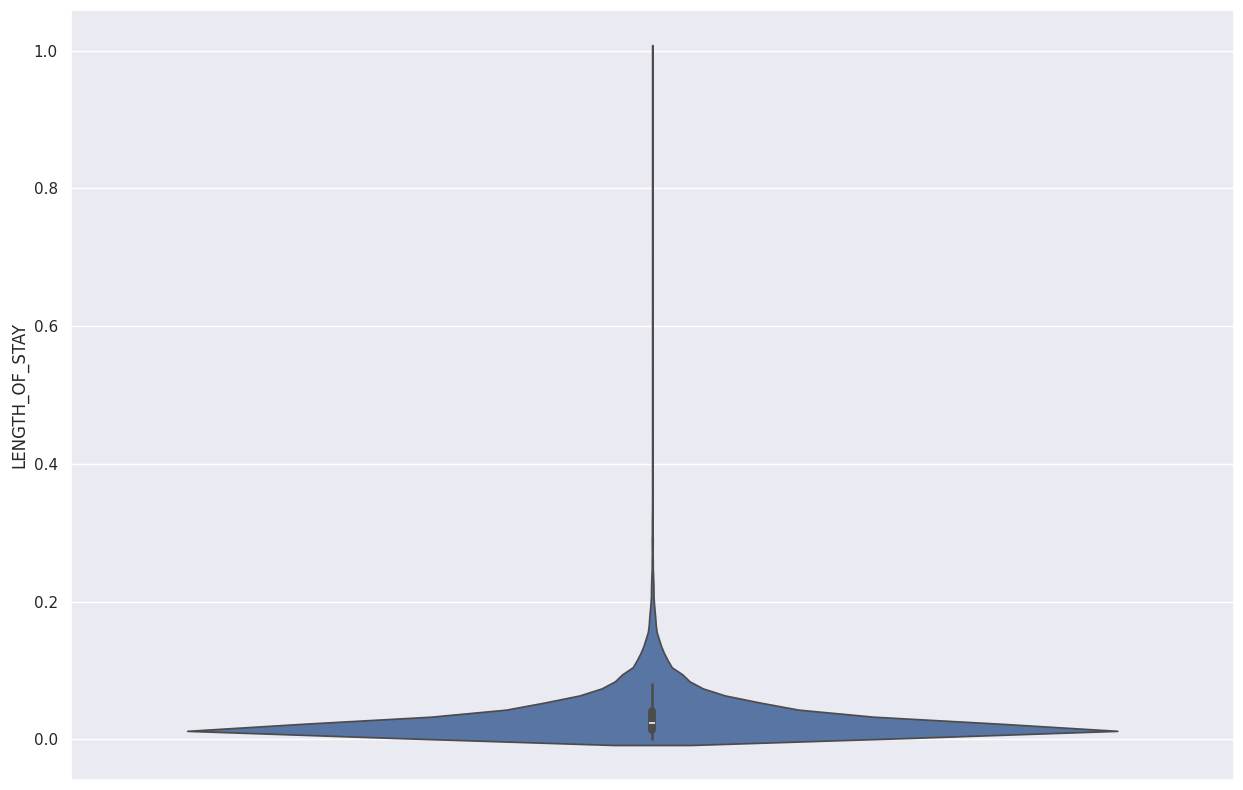

In [65]:
# after

display_countplot(dataframe=data_filtered, column_name=colname, is_vertical=True)

# TOTAL_CHARGES   

Description: Sum of accommodation charges, non-covered accommodation charges, ancillary charges, noncovered ancillary charges. 

count    5.000000e+04
mean     4.347324e+04
std      7.996046e+04
min      0.000000e+00
25%      1.112095e+04
50%      2.352960e+04
75%      4.844647e+04
max      3.293072e+06
Name: TOTAL_CHARGES, dtype: float64
NA: 0.0%
Unique: 46880


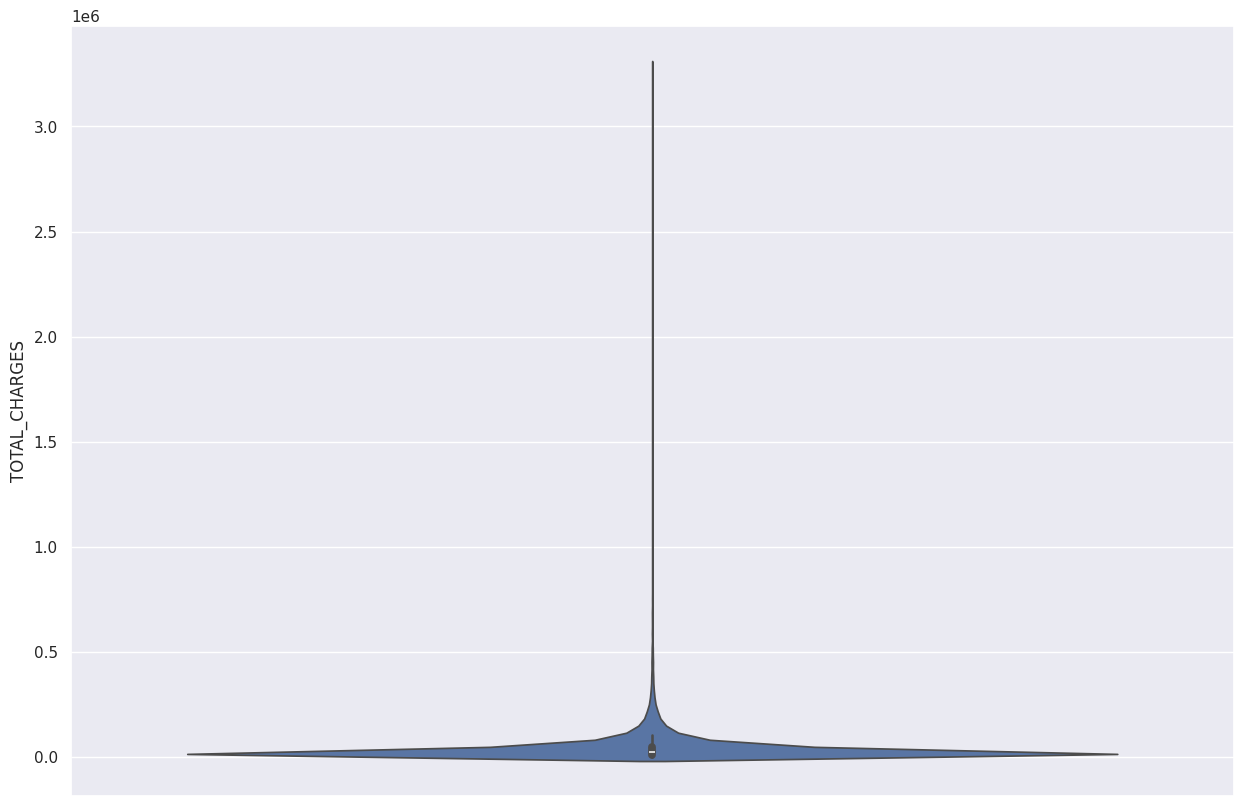

In [66]:
display_countplot(data_filtered, 'TOTAL_CHARGES', is_vertical=True)

In [67]:
# square root transformation (use value **2 to revert back)

colname = 'TOTAL_CHARGES'
data_filtered[colname] = np.sqrt(data_filtered[colname])

# data_filtered_train[colname] = np.sqrt(data_filtered_train[colname])
# data_filtered_val[colname] = np.sqrt(data_filtered_val[colname])
# data_filtered_test[colname] = np.sqrt(data_filtered_test[colname])


In [68]:
# square root transformation (use value **2 to revert back)

# ?? warum war das ein zweites mal hier
# data_filtered[colname] = np.sqrt(data_filtered[colname])



In [69]:
# normalize variable

# normalize_variable(dataframe=data_filtered, column_name=colname)

normalize_variable(dataframe=data_filtered, column_name=colname, path=output_path)

# normalize_variable(dataframe=data_filtered_train, column_name=colname, path=output_train)
# normalize_variable(dataframe=data_filtered_val, column_name=colname, path=output_val)
# normalize_variable(dataframe=data_filtered_test, column_name=colname, path=output_test)

Original max value: [1814.68230828]
Original min value: [0.]
Scaled values of the top rows: [[0.12932451]
 [0.02536675]
 [0.05380678]
 [0.14653479]
 [0.1422687 ]]


count    50000.000000
mean         0.097093
std          0.061436
min          0.000000
25%          0.058113
50%          0.084529
75%          0.121292
max          1.000000
Name: TOTAL_CHARGES, dtype: float64
NA: 0.0%
Unique: 46880


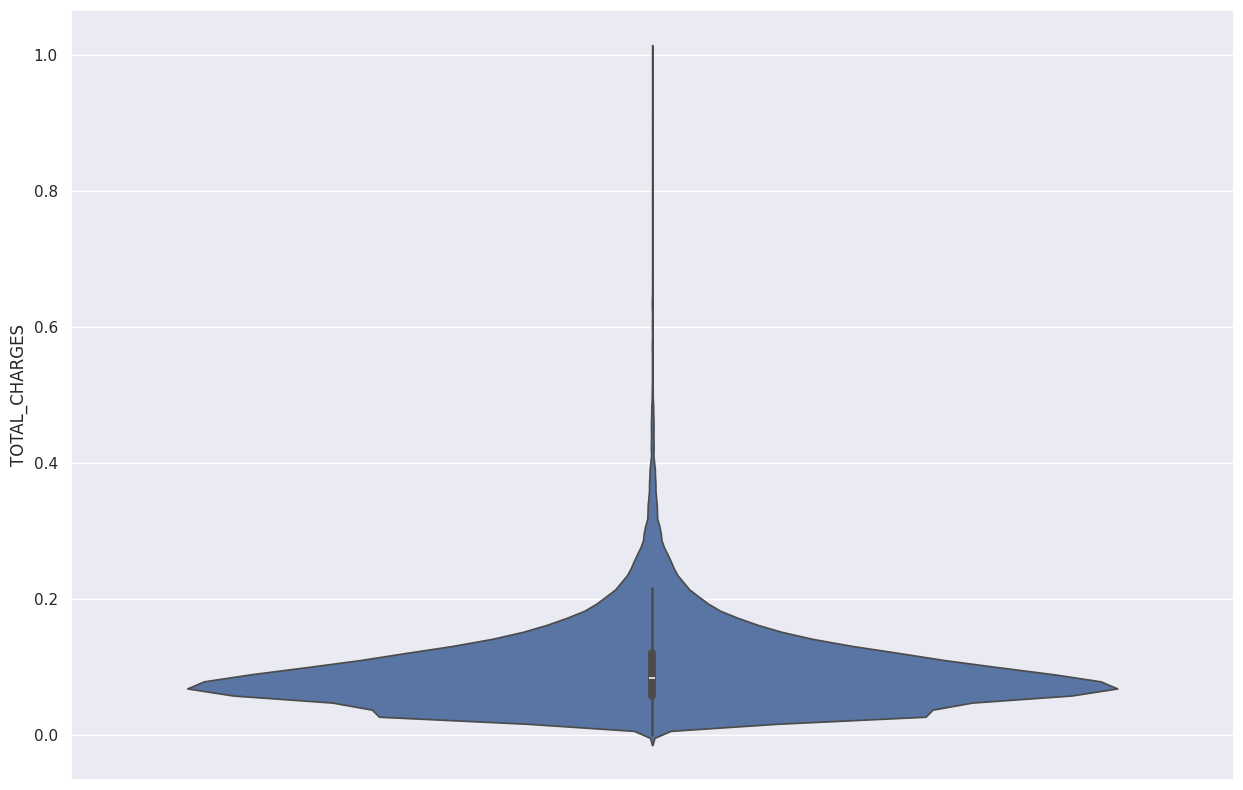

In [70]:
# after

display_countplot(dataframe=data_filtered, column_name=colname, is_vertical=True)

# TOTAL_NON_COV_CHARGES        

Description: Sum of non-covered accommodation charges, non-covered ancillary charges. 

count     50000.000000
mean        914.495462
std       14635.523574
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      969641.700000
Name: TOTAL_NON_COV_CHARGES, dtype: float64
NA: 0.0%
Unique: 1098


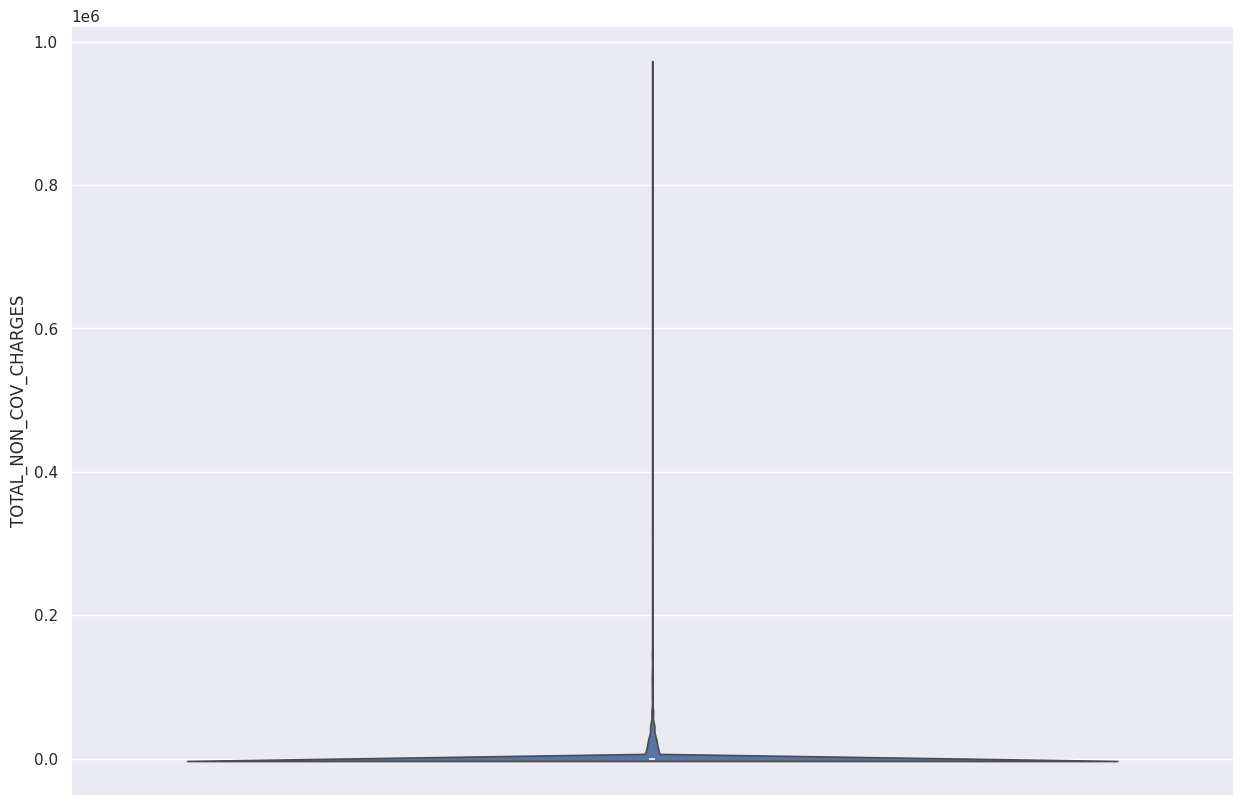

In [71]:
display_countplot(data_filtered, 'TOTAL_NON_COV_CHARGES', is_vertical=True)

In [72]:
# square root transformation (use value **2 to revert back)

colname = 'TOTAL_NON_COV_CHARGES'
data_filtered[colname] = np.sqrt(data_filtered[colname])

# data_filtered_train[colname] = np.sqrt(data_filtered_train[colname])
# data_filtered_val[colname] = np.sqrt(data_filtered_val[colname])
# data_filtered_test[colname] = np.sqrt(data_filtered_test[colname])

In [73]:
# square root transformation (use value **2 to revert back)

# ?? schon wieder
# data_filtered[colname] = np.sqrt(data_filtered[colname])

In [74]:
# normalize variable

# normalize_variable(dataframe=data_filtered, column_name=colname)

normalize_variable(dataframe=data_filtered, column_name=colname, path=output_path)

# normalize_variable(dataframe=data_filtered_train, column_name=colname, path=output_train)
# normalize_variable(dataframe=data_filtered_val, column_name=colname, path=output_val)
# normalize_variable(dataframe=data_filtered_test, column_name=colname, path=output_test)

Original max value: [984.70386411]
Original min value: [0.]
Scaled values of the top rows: [[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


count    50000.000000
mean         0.003381
std          0.030524
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: TOTAL_NON_COV_CHARGES, dtype: float64
NA: 0.0%
Unique: 1098


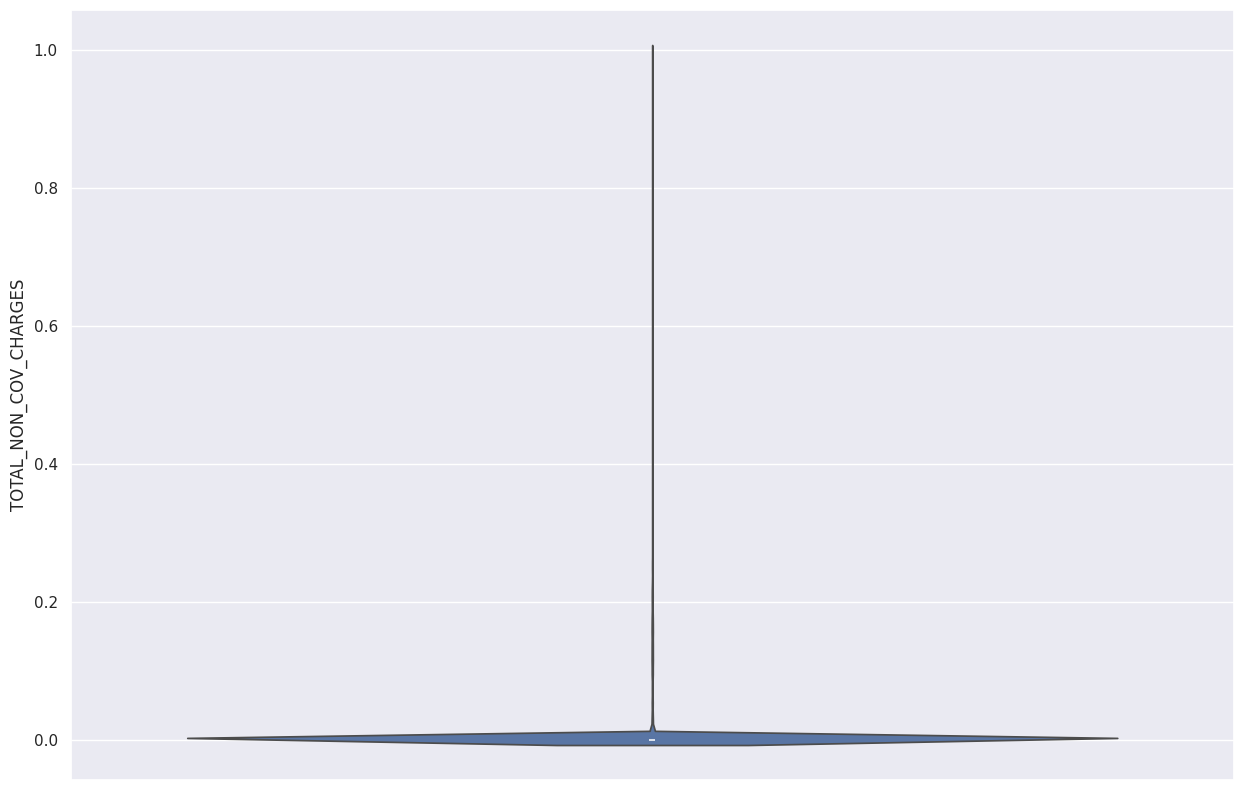

In [75]:
# after

display_countplot(dataframe=data_filtered, column_name=colname, is_vertical=True)

# TOTAL_CHARGES_ACCOMM        

Description: Sum of covered and non-covered accommodation charges. 

count     50000.000000
mean       9572.308708
std       23859.397335
min           0.000000
25%        2106.000000
50%        3975.000000
75%        8938.950000
max      974433.000000
Name: TOTAL_CHARGES_ACCOMM, dtype: float64
NA: 0.0%
Unique: 13202


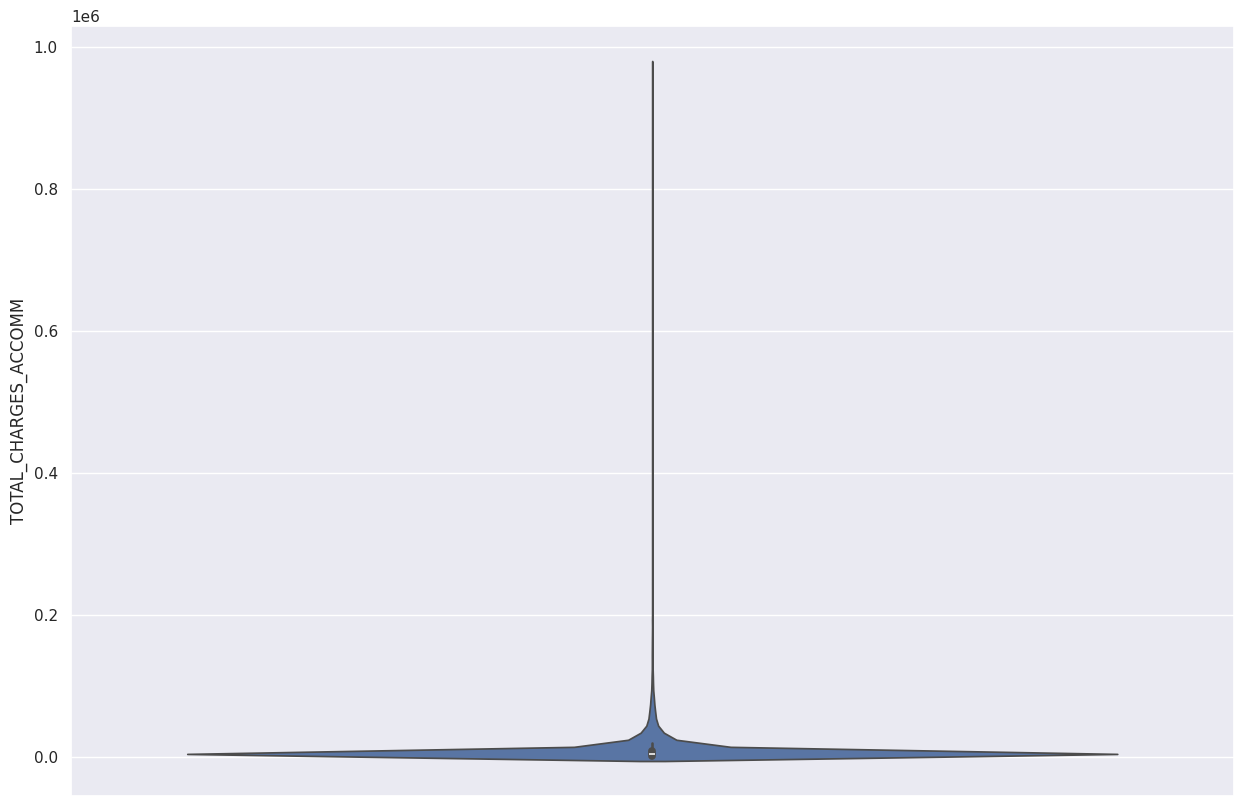

In [76]:
display_countplot(data_filtered, 'TOTAL_CHARGES_ACCOMM', is_vertical=True)

In [77]:
# square root transformation (use value **2 to revert back)

colname = 'TOTAL_CHARGES_ACCOMM'
data_filtered[colname] = np.sqrt(data_filtered[colname])

# data_filtered_train[colname] = np.sqrt(data_filtered_train[colname])
# data_filtered_val[colname] = np.sqrt(data_filtered_val[colname])
# data_filtered_test[colname] = np.sqrt(data_filtered_test[colname])

In [78]:
# square root transformation (use value **2 to revert back)

# grr
# data_filtered[colname] = np.sqrt(data_filtered[colname])

In [79]:
# normalize variable

# normalize_variable(dataframe=data_filtered, column_name=colname)
normalize_variable(dataframe=data_filtered, column_name=colname, path=output_path)

# normalize_variable(dataframe=data_filtered_train, column_name=colname, path=output_train)
# normalize_variable(dataframe=data_filtered_val, column_name=colname, path=output_val)
# normalize_variable(dataframe=data_filtered_test, column_name=colname, path=output_test)

Original max value: [987.13372954]
Original min value: [0.]
Scaled values of the top rows: [[0.07394454]
 [0.04285984]
 [0.0315345 ]
 [0.04721217]
 [0.10223616]]


count    50000.000000
mean         0.080382
std          0.057986
min          0.000000
25%          0.046489
50%          0.063869
75%          0.095778
max          1.000000
Name: TOTAL_CHARGES_ACCOMM, dtype: float64
NA: 0.0%
Unique: 13202


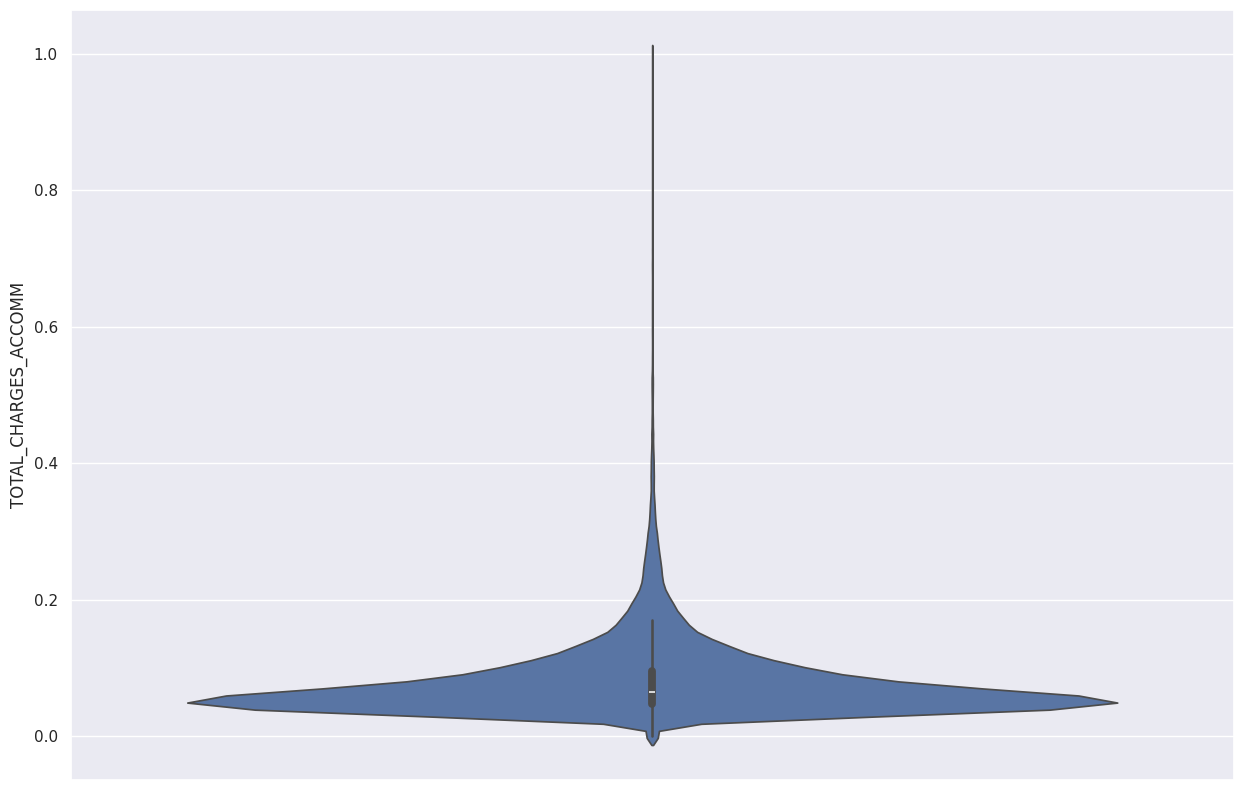

In [80]:
# after

display_countplot(dataframe=data_filtered, column_name=colname, is_vertical=True)

# TOTAL_NON_COV_CHARGES_ACCOMM  

Description: Sum of non-covered accommodations charges. 

count     50000.000000
mean        254.504691
std        5054.028800
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      412751.000000
Name: TOTAL_NON_COV_CHARGES_ACCOMM, dtype: float64
NA: 0.0%
Unique: 415


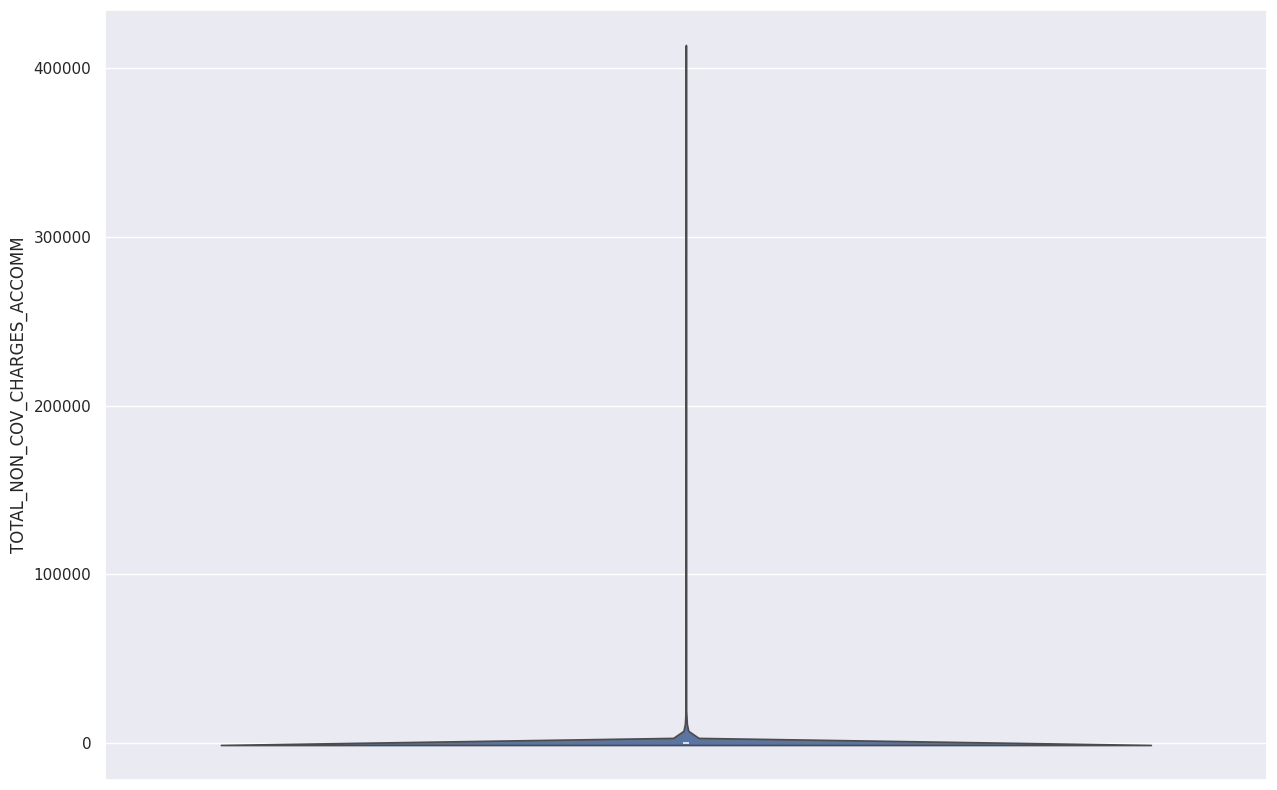

In [81]:
display_countplot(data_filtered, 'TOTAL_NON_COV_CHARGES_ACCOMM', is_vertical=True)

In [82]:
# square root transformation (use value **2 to revert back)

colname = 'TOTAL_NON_COV_CHARGES_ACCOMM'
data_filtered[colname] = np.sqrt(data_filtered[colname])

# data_filtered_train[colname] = np.sqrt(data_filtered_train[colname])
# data_filtered_val[colname] = np.sqrt(data_filtered_val[colname])
# data_filtered_test[colname] = np.sqrt(data_filtered_test[colname])

In [83]:
# square root transformation (use value **2 to revert back)

# ...
# data_filtered[colname] = np.sqrt(data_filtered[colname])

In [84]:
# normalize variable

# normalize_variable(dataframe=data_filtered, column_name=colname)
normalize_variable(dataframe=data_filtered, column_name=colname, path=output_path)

# normalize_variable(dataframe=data_filtered_train, column_name=colname, path=output_train)
# normalize_variable(dataframe=data_filtered_val, column_name=colname, path=output_val)
# normalize_variable(dataframe=data_filtered_test, column_name=colname, path=output_test)

Original max value: [642.45700245]
Original min value: [0.]
Scaled values of the top rows: [[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


count    50000.000000
mean         0.002410
std          0.024715
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: TOTAL_NON_COV_CHARGES_ACCOMM, dtype: float64
NA: 0.0%
Unique: 415


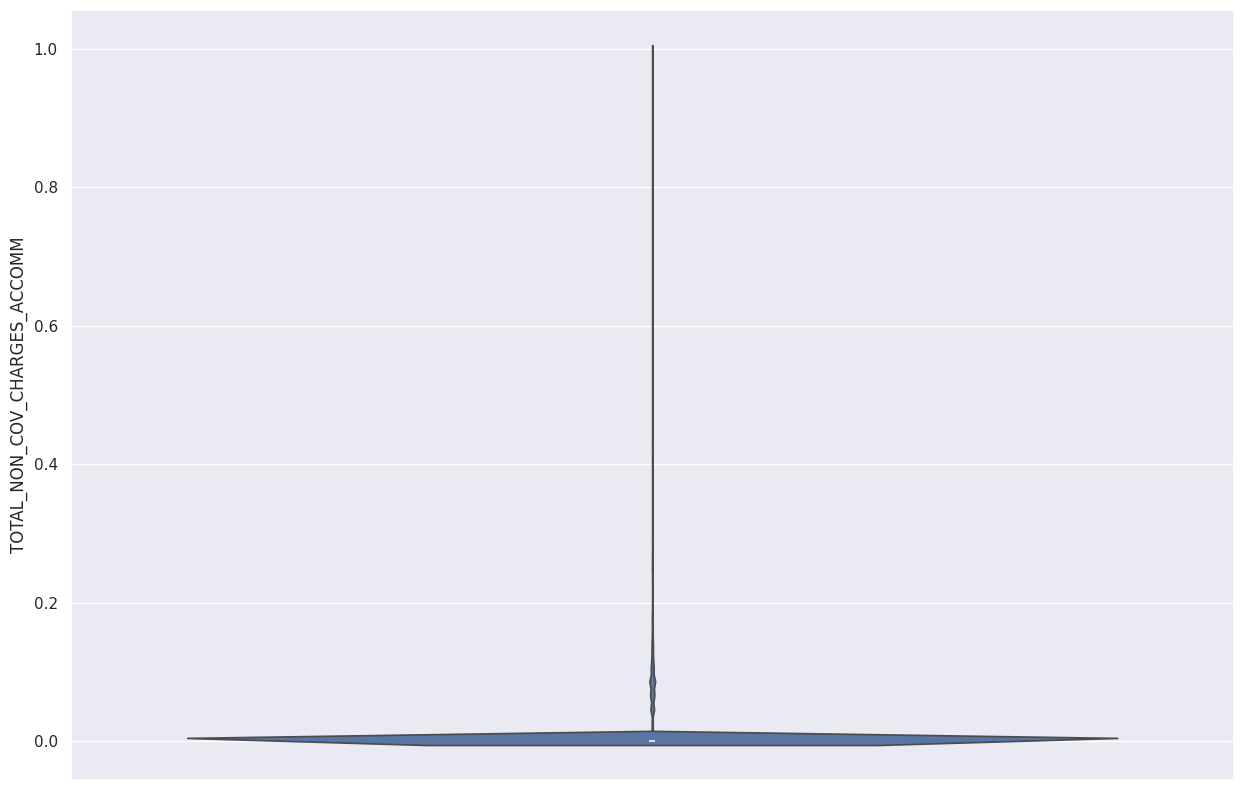

In [85]:
# after

display_countplot(dataframe=data_filtered, column_name=colname, is_vertical=True)

# TOTAL_CHARGES_ANCIL           

Description: Sum of covered and non-covered ancillary charges. 

count    5.000000e+04
mean     3.390496e+04
std      6.351596e+04
min      0.000000e+00
25%      7.289843e+03
50%      1.784434e+04
75%      3.896022e+04
max      2.994630e+06
Name: TOTAL_CHARGES_ANCIL, dtype: float64
NA: 0.0%
Unique: 45900


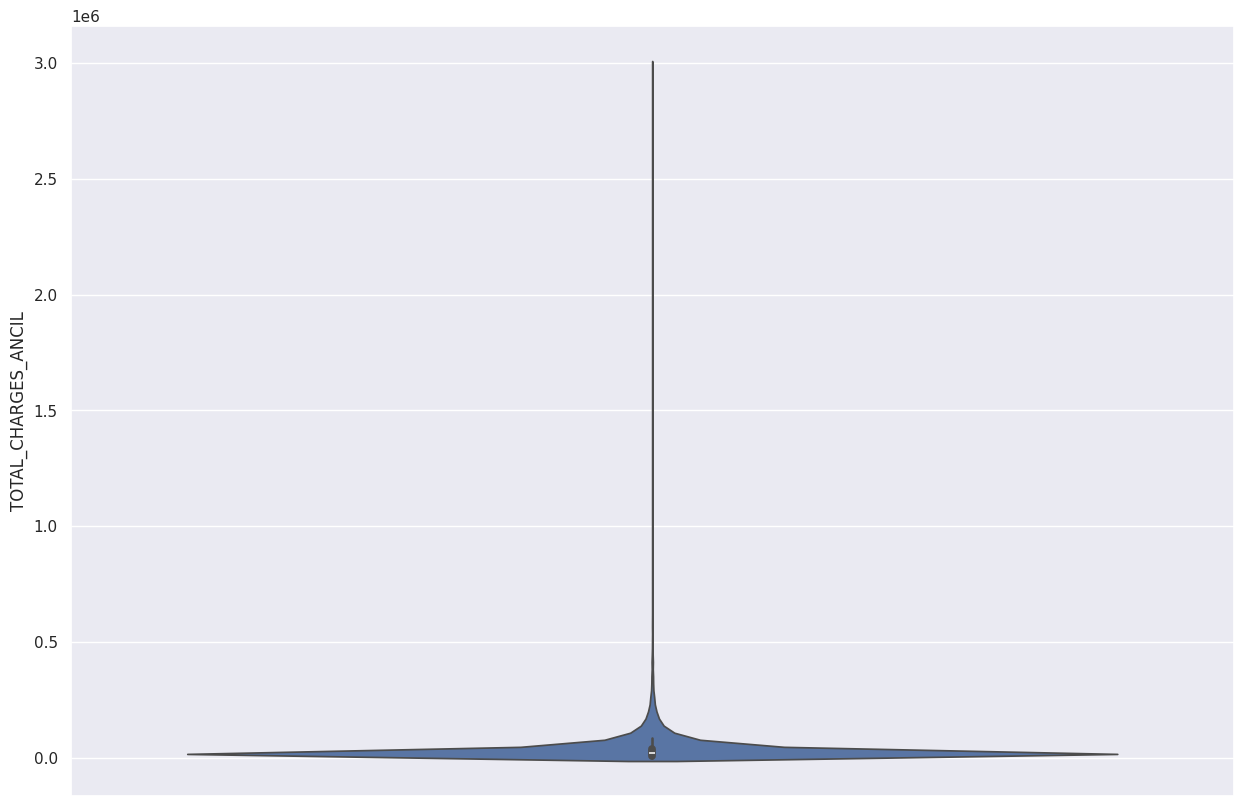

In [86]:
display_countplot(data_filtered, 'TOTAL_CHARGES_ANCIL', is_vertical=True)

In [87]:
# square root transformation (use value **2 to revert back)

colname = 'TOTAL_CHARGES_ANCIL'
data_filtered[colname] = np.sqrt(data_filtered[colname])

# data_filtered_train[colname] = np.sqrt(data_filtered_train[colname])
# data_filtered_val[colname] = np.sqrt(data_filtered_val[colname])
# data_filtered_test[colname] = np.sqrt(data_filtered_test[colname])

In [88]:
# square root transformation (use value **2 to revert back)

# why
# data_filtered[colname] = np.sqrt(data_filtered[colname])

In [89]:
# normalize variable

# normalize_variable(dataframe=data_filtered, column_name=colname)
normalize_variable(dataframe=data_filtered, column_name=colname, path=output_path)

# normalize_variable(dataframe=data_filtered_train, column_name=colname, path=output_train)
# normalize_variable(dataframe=data_filtered_val, column_name=colname, path=output_val)
# normalize_variable(dataframe=data_filtered_test, column_name=colname, path=output_test)

Original max value: [1730.50007223]
Original min value: [0.]
Scaled values of the top rows: [[0.12888918]
 [0.01048157]
 [0.05348008]
 [0.15128471]
 [0.13731872]]


count    50000.000000
mean         0.087476
std          0.060581
min          0.000000
25%          0.049339
50%          0.077193
75%          0.114061
max          1.000000
Name: TOTAL_CHARGES_ANCIL, dtype: float64
NA: 0.0%
Unique: 45900


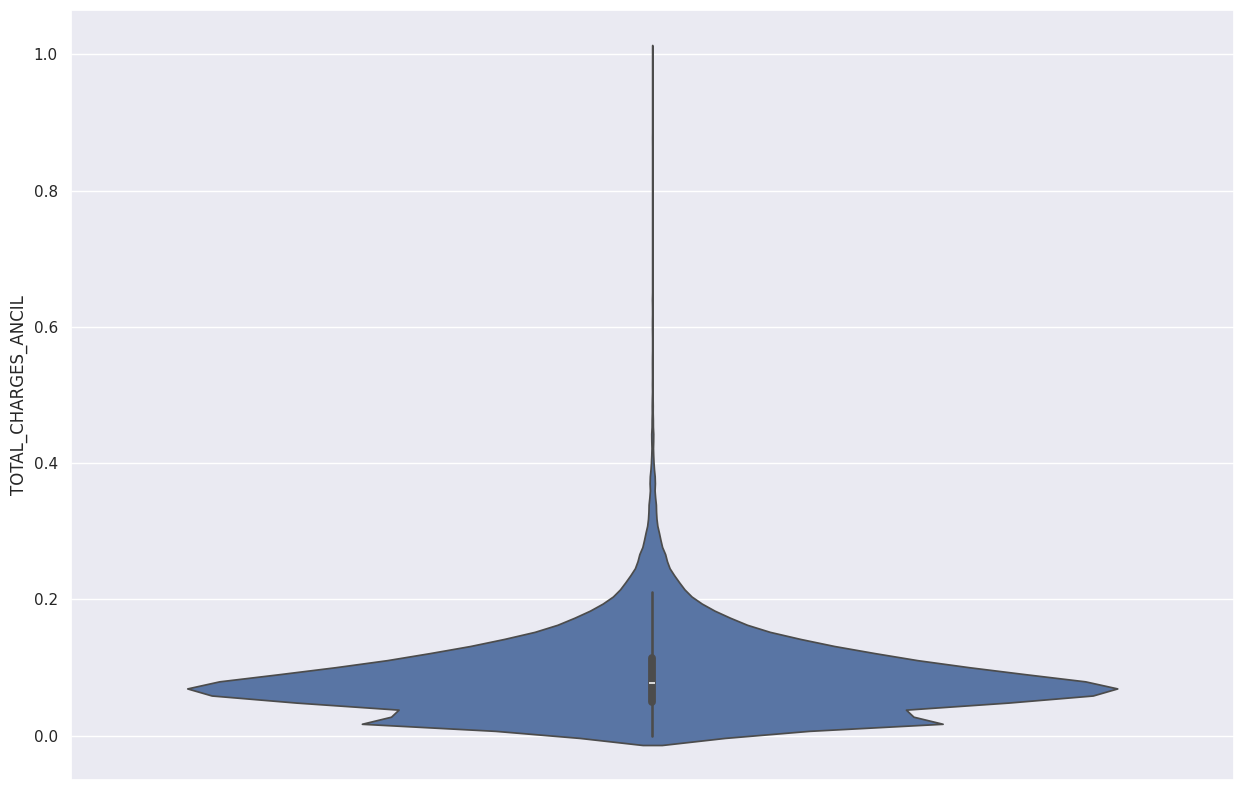

In [90]:
# after

display_countplot(dataframe=data_filtered, column_name=colname, is_vertical=True)

# TOTAL_NON_COV_CHARGES_ANCIL  

Description: Sum of non-covered ancillary charges.

count     50000.00000
mean        659.99077
std       10050.87048
min           0.00000
25%           0.00000
50%           0.00000
75%           0.00000
max      642920.64000
Name: TOTAL_NON_COV_CHARGES_ANCIL, dtype: float64
NA: 0.0%
Unique: 1047


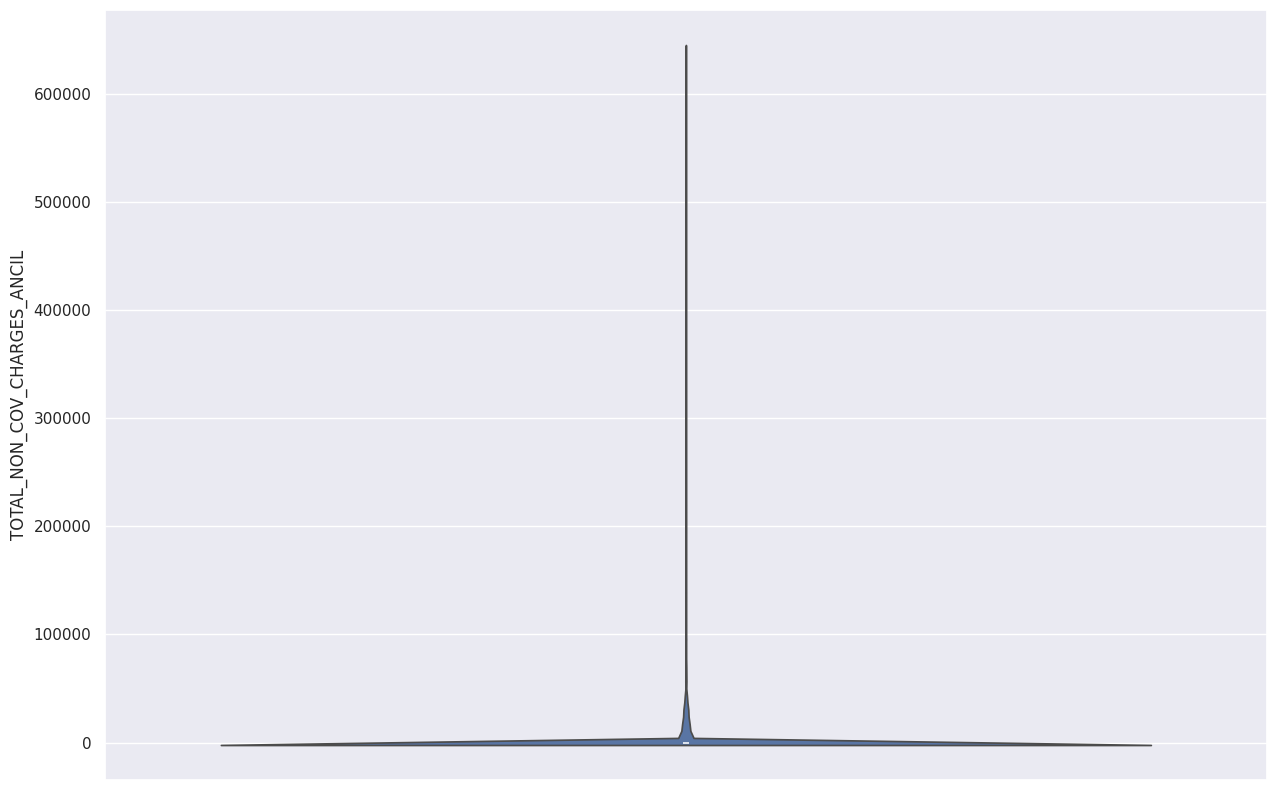

In [91]:
display_countplot(data_filtered, 'TOTAL_NON_COV_CHARGES_ANCIL', is_vertical=True)

In [92]:
# square root transformation (use value **2 to revert back)

colname = 'TOTAL_NON_COV_CHARGES_ANCIL'
data_filtered[colname] = np.sqrt(data_filtered[colname])

# data_filtered_train[colname] = np.sqrt(data_filtered_train[colname])
# data_filtered_val[colname] = np.sqrt(data_filtered_val[colname])
# data_filtered_test[colname] = np.sqrt(data_filtered_test[colname])

In [93]:
# square root transformation (use value **2 to revert back)

# mensch
# data_filtered[colname] = np.sqrt(data_filtered[colname])

In [94]:
# normalize variable

# normalize_variable(dataframe=data_filtered, column_name=colname)
normalize_variable(dataframe=data_filtered, column_name=colname, path=output_path)

# normalize_variable(dataframe=data_filtered_train, column_name=colname, path=output_train)
# normalize_variable(dataframe=data_filtered_val, column_name=colname, path=output_val)
# normalize_variable(dataframe=data_filtered_test, column_name=colname, path=output_test)

Original max value: [801.82332219]
Original min value: [0.]
Scaled values of the top rows: [[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


count    50000.000000
mean         0.003530
std          0.031845
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: TOTAL_NON_COV_CHARGES_ANCIL, dtype: float64
NA: 0.0%
Unique: 1047


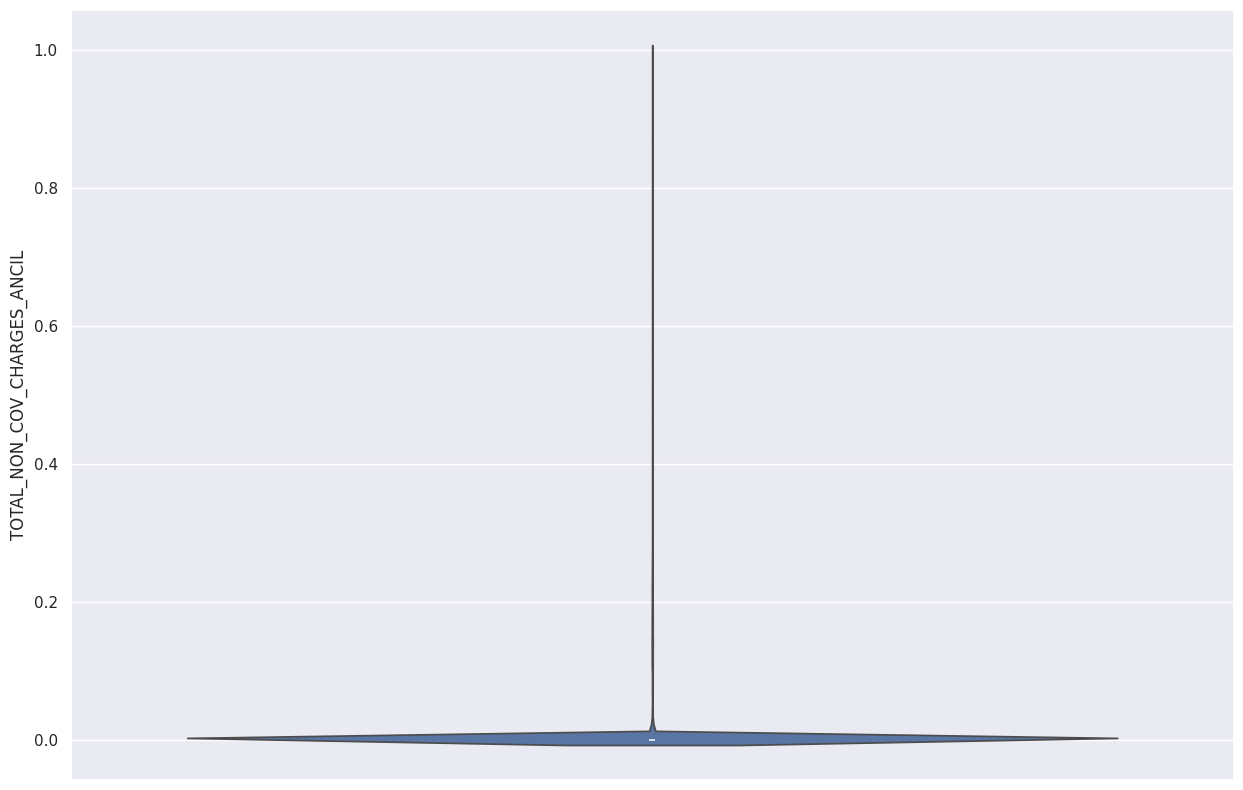

In [95]:
# after

display_countplot(dataframe=data_filtered, column_name=colname, is_vertical=True)

# Convert into respective datatypes

In [96]:
data_filtered = data_filtered.convert_dtypes()
data_filtered.info(verbose=True, show_counts=True)

# data_filtered_train = data_filtered_train.convert_dtypes()
# data_filtered_train.info(verbose=True, show_counts=True)

# data_filtered_val = data_filtered_val.convert_dtypes()
# data_filtered_val.info(verbose=True, show_counts=True)

# data_filtered_test = data_filtered_test.convert_dtypes()
# data_filtered_test.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SUBJID                        50000 non-null  Int64  
 1   VISIT                         50000 non-null  Int64  
 2   DISCHARGE                     50000 non-null  Int64  
 3   TYPE_OF_ADMISSION             50000 non-null  Int64  
 4   PAT_STATE                     50000 non-null  Int64  
 5   PAT_STATUS                    50000 non-null  Int64  
 6   SEX_CODE                      50000 non-null  Int64  
 7   RACE                          50000 non-null  Int64  
 8   ETHNICITY                     50000 non-null  Int64  
 9   ADMIT_WEEKDAY                 50000 non-null  Int64  
 10  PAT_AGE                       50000 non-null  Int64  
 11  RISK_MORTALITY                50000 non-null  Int64  
 12  ILLNESS_SEVERITY              50000 non-null  Int64  
 13  L

In [97]:
data_filtered.shape

(50000, 20)

In [98]:
data_filtered.head()

,SUBJID,VISIT,DISCHARGE,TYPE_OF_ADMISSION,PAT_STATE,PAT_STATUS,SEX_CODE,RACE,ETHNICITY,ADMIT_WEEKDAY,PAT_AGE,RISK_MORTALITY,ILLNESS_SEVERITY,LENGTH_OF_STAY,TOTAL_CHARGES,TOTAL_NON_COV_CHARGES,TOTAL_CHARGES_ACCOMM,TOTAL_NON_COV_CHARGES_ACCOMM,TOTAL_CHARGES_ANCIL,TOTAL_NON_COV_CHARGES_ANCIL
0,0,0,4,3,6,6,0,4,2,2,12,1,1,0.032894,0.129325,0.0,0.073945,0.0,0.128889,0.0
1,1,0,1,4,6,1,0,4,2,3,1,1,1,0.013625,0.025367,0.0,0.04286,0.0,0.010482,0.0
2,2,0,1,1,6,1,0,4,2,0,7,1,1,0.0,0.053807,0.0,0.031534,0.0,0.05348,0.0
3,3,0,3,2,6,3,1,4,2,0,14,2,1,0.02408,0.146535,0.0,0.047212,0.0,0.151285,0.0
4,4,0,4,2,6,1,1,4,2,2,12,3,3,0.02408,0.142269,0.0,0.102236,0.0,0.137319,0.0


In [100]:
data_filtered["VISIT"] = np.ones(data_filtered.shape[0]).astype(int)
data_filtered.head()

,SUBJID,VISIT,DISCHARGE,TYPE_OF_ADMISSION,PAT_STATE,PAT_STATUS,SEX_CODE,RACE,ETHNICITY,ADMIT_WEEKDAY,PAT_AGE,RISK_MORTALITY,ILLNESS_SEVERITY,LENGTH_OF_STAY,TOTAL_CHARGES,TOTAL_NON_COV_CHARGES,TOTAL_CHARGES_ACCOMM,TOTAL_NON_COV_CHARGES_ACCOMM,TOTAL_CHARGES_ANCIL,TOTAL_NON_COV_CHARGES_ANCIL
0,0,1,4,3,6,6,0,4,2,2,12,1,1,0.032894,0.129325,0.0,0.073945,0.0,0.128889,0.0
1,1,1,1,4,6,1,0,4,2,3,1,1,1,0.013625,0.025367,0.0,0.04286,0.0,0.010482,0.0
2,2,1,1,1,6,1,0,4,2,0,7,1,1,0.0,0.053807,0.0,0.031534,0.0,0.05348,0.0
3,3,1,3,2,6,3,1,4,2,0,14,2,1,0.02408,0.146535,0.0,0.047212,0.0,0.151285,0.0
4,4,1,4,2,6,1,1,4,2,2,12,3,3,0.02408,0.142269,0.0,0.102236,0.0,0.137319,0.0


In [101]:
path = "../data/raw/"
data_filtered.to_csv(f'{path}/input_texas.csv', index=False)

# Note for the Texas dataset:
- It has 18 columns, 50,000 rows originally.
- It does not contain NA values.
- It has 20 columns, 50,000 rows after preprocessing.
- 2 columns added: SUBJID and VISIT.
- Did square root transformation for continuous values.

###############################################################################################################################

# Step 3
# Create variable groups / modules

# Method 2: Create a variable group dict

In [ ]:
var_group = {
    # group all columns in one variable group
    dataset_name: data_filtered.columns.tolist()
}

In [ ]:
var_group

{'texas': ['SUBJID',
  'VISIT',
  'DISCHARGE',
  'TYPE_OF_ADMISSION',
  'PAT_STATE',
  'PAT_STATUS',
  'SEX_CODE',
  'RACE',
  'ETHNICITY',
  'ADMIT_WEEKDAY',
  'PAT_AGE',
  'RISK_MORTALITY',
  'ILLNESS_SEVERITY',
  'LENGTH_OF_STAY',
  'TOTAL_CHARGES',
  'TOTAL_NON_COV_CHARGES',
  'TOTAL_CHARGES_ACCOMM',
  'TOTAL_NON_COV_CHARGES_ACCOMM',
  'TOTAL_CHARGES_ANCIL',
  'TOTAL_NON_COV_CHARGES_ANCIL']}

In [ ]:
print(f"Total number of variable groups before separation of follow-up years: {len(var_group)}")

Total number of variable groups before separation of follow-up years: 1


# Assign dataset into each variable group

In [ ]:
unique_visits = list(data_filtered['VISIT'].unique())
unique_visits.sort()
unique_visits

# unique_visits_train = list(data_filtered_train['VISIT'].unique())
# unique_visits_train.sort()
# unique_visits_train

# unique_visits_val = list(data_filtered_val['VISIT'].unique())
# unique_visits_val.sort()
# unique_visits_val

# unique_visits_test = list(data_filtered_test['VISIT'].unique())
# unique_visits_test.sort()
# unique_visits_test

print(unique_visits)

[0]


In [ ]:
unique_ids = pd.DataFrame(data_filtered['SUBJID'].unique(), columns=['SUBJID'])
unique_ids.shape

# unique_ids_train = pd.DataFrame(data_filtered_train['SUBJID'].unique(), columns=['SUBJID'])
# unique_ids_train.shape

# unique_ids_val = pd.DataFrame(data_filtered_val['SUBJID'].unique(), columns=['SUBJID'])
# unique_ids_val.shape

# unique_ids_test = pd.DataFrame(data_filtered_test['SUBJID'].unique(), columns=['SUBJID'])
# print(f'{unique_ids_test.shape}')

(50000, 1)

In [ ]:
# Create a dict, where key = variable group name, and value = dataframe of that variable group
data_condensed = dict()

# load datasets by variable groups
for (key, cols) in var_group.items():
    
    # create an empty dataframe  
    single_group = pd.DataFrame()
    
    print(f"\nCurrently processing the variable group '{key}'...")
    
    # assign data per variable group
    single_group = data_filtered[cols]
    
    # separate single variable group by visits
    # if the single_group df is not empty, make subsets of the df by year
    for visit in unique_visits:
        single_group_visit = single_group[single_group['VISIT'] == visit]
        
        # remove VISIT column, not needed anymore
        single_group_visit = single_group_visit.drop(['VISIT'], axis=1)
        
        # merge with unique ids to ensure that all ids are present
        single_group_visit_complete = pd.merge(unique_ids, single_group_visit, on='SUBJID', how='left')
        
        # set the id as the index of the df
        single_group_visit_complete = single_group_visit_complete.set_index('SUBJID')
        print(f"df {key}_vis{visit} shape: {single_group_visit_complete.shape}")
        
        # add ids back as a column instead of index
        single_group_visit_complete.reset_index(inplace=True)
        
        # rename each column (add respective visits)
        single_group_visit_complete = single_group_visit_complete.rename(columns={c: f"{c}_VIS{visit}" for c in single_group_visit_complete.columns})
        
        # add or append df to dict
        dict_name = f"{key}_VIS{visit}"
        if dict_name not in data_condensed:
            data_condensed[dict_name] = single_group_visit_complete
        else:
            data_condensed[dict_name].append(single_group_visit_complete)


Currently processing the variable group 'texas'...
df texas_vis0 shape: (50000, 18)


In [ ]:
# # Create a dict, where key = variable group name, and value = dataframe of that variable group
# data_condensed_train = dict()

# # load datasets by variable groups
# for (key, cols) in var_group.items():

#     # create an empty dataframe
#     single_group = pd.DataFrame()

#     print(f"\nCurrently processing the variable group '{key}'...")

#     # assign data per variable group
#     single_group = data_filtered_train[cols]

#     # separate single variable group by visits
#     # if the single_group df is not empty, make subsets of the df by year
#     for visit in unique_visits_train:
#         single_group_visit = single_group[single_group['VISIT'] == visit]

#         # remove VISIT column, not needed anymore
#         single_group_visit = single_group_visit.drop(['VISIT'], axis=1)

#         # merge with unique ids to ensure that all ids are present
#         single_group_visit_complete = pd.merge(unique_ids_train, single_group_visit, on='SUBJID', how='left')

#         # set the id as the index of the df
#         single_group_visit_complete = single_group_visit_complete.set_index('SUBJID')
#         print(f"df {key}_vis{visit} shape: {single_group_visit_complete.shape}")

#         # add ids back as a column instead of index
#         single_group_visit_complete.reset_index(inplace=True)

#         # rename each column (add respective visits)
#         single_group_visit_complete = single_group_visit_complete.rename(columns={c: f"{c}_VIS{visit}" for c in single_group_visit_complete.columns})

#         # add or append df to dict
#         dict_name = f"{key}_VIS{visit}"
#         if dict_name not in data_condensed_train:
#             data_condensed_train[dict_name] = single_group_visit_complete
#         else:
#             data_condensed_train[dict_name].append(single_group_visit_complete)

In [ ]:
# # Create a dict, where key = variable group name, and value = dataframe of that variable group
# data_condensed_val = dict()

# # load datasets by variable groups
# for (key, cols) in var_group.items():

#     # create an empty dataframe
#     single_group = pd.DataFrame()

#     print(f"\nCurrently processing the variable group '{key}'...")

#     # assign data per variable group
#     single_group = data_filtered_val[cols]

#     # separate single variable group by visits
#     # if the single_group df is not empty, make subsets of the df by year
#     for visit in unique_visits_val:
#         single_group_visit = single_group[single_group['VISIT'] == visit]

#         # remove VISIT column, not needed anymore
#         single_group_visit = single_group_visit.drop(['VISIT'], axis=1)

#         # merge with unique ids to ensure that all ids are present
#         single_group_visit_complete = pd.merge(unique_ids_val, single_group_visit, on='SUBJID', how='left')

#         # set the id as the index of the df
#         single_group_visit_complete = single_group_visit_complete.set_index('SUBJID')
#         print(f"df {key}_vis{visit} shape: {single_group_visit_complete.shape}")

#         # add ids back as a column instead of index
#         single_group_visit_complete.reset_index(inplace=True)

#         # rename each column (add respective visits)
#         single_group_visit_complete = single_group_visit_complete.rename(columns={c: f"{c}_VIS{visit}" for c in single_group_visit_complete.columns})

#         # add or append df to dict
#         dict_name = f"{key}_VIS{visit}"
#         if dict_name not in data_condensed_val:
#             data_condensed_val[dict_name] = single_group_visit_complete
#         else:
#             data_condensed_val[dict_name].append(single_group_visit_complete)

In [ ]:
# # Create a dict, where key = variable group name, and value = dataframe of that variable group
# data_condensed_test = dict()

# # load datasets by variable groups
# for (key, cols) in var_group.items():

#     # create an empty dataframe
#     single_group = pd.DataFrame()

#     print(f"\nCurrently processing the variable group '{key}'...")

#     # assign data per variable group
#     single_group = data_filtered_test[cols]

#     # separate single variable group by visits
#     # if the single_group df is not empty, make subsets of the df by year
#     for visit in unique_visits_test:
#         single_group_visit = single_group[single_group['VISIT'] == visit]

#         # remove VISIT column, not needed anymore
#         single_group_visit = single_group_visit.drop(['VISIT'], axis=1)

#         # merge with unique ids to ensure that all ids are present
#         single_group_visit_complete = pd.merge(unique_ids_test, single_group_visit, on='SUBJID', how='left')

#         # set the id as the index of the df
#         single_group_visit_complete = single_group_visit_complete.set_index('SUBJID')
#         print(f"df {key}_vis{visit} shape: {single_group_visit_complete.shape}")

#         # add ids back as a column instead of index
#         single_group_visit_complete.reset_index(inplace=True)

#         # rename each column (add respective visits)
#         single_group_visit_complete = single_group_visit_complete.rename(columns={c: f"{c}_VIS{visit}" for c in single_group_visit_complete.columns})

#         # add or append df to dict
#         dict_name = f"{key}_VIS{visit}"
#         if dict_name not in data_condensed_test:
#             data_condensed_test[dict_name] = single_group_visit_complete
#         else:
#             data_condensed_test[dict_name].append(single_group_visit_complete)

In [ ]:
print(f"Number of variable groups after separation of follow-up years: {len(data_condensed.keys())}")

Number of variable groups after separation of follow-up years: 1


In [ ]:
data_condensed.keys()

dict_keys(['texas_VIS0'])

In [ ]:
# create a df of variable group names
module_names = list(data_condensed.keys())
module_names = pd.DataFrame(module_names, columns=['module'])
module_names.head()

# module_names_train = list(data_condensed_train.keys())
# module_names_train = pd.DataFrame(module_names_train, columns=['module'])
# module_names_train.head()

# module_names_val = list(data_condensed_val.keys())
# module_names_val = pd.DataFrame(module_names_val, columns=['module'])
# module_names_val.head()

# module_names_test = list(data_condensed_test.keys())
# module_names_test = pd.DataFrame(module_names_test, columns=['module'])
# module_names_test.head()



,module
0,texas_VIS0


In [ ]:
# sanity check
data_condensed[f'{dataset_name}_VIS0'].head()

,SUBJID_VIS0,DISCHARGE_VIS0,TYPE_OF_ADMISSION_VIS0,PAT_STATE_VIS0,PAT_STATUS_VIS0,SEX_CODE_VIS0,RACE_VIS0,ETHNICITY_VIS0,ADMIT_WEEKDAY_VIS0,PAT_AGE_VIS0,RISK_MORTALITY_VIS0,ILLNESS_SEVERITY_VIS0,LENGTH_OF_STAY_VIS0,TOTAL_CHARGES_VIS0,TOTAL_NON_COV_CHARGES_VIS0,TOTAL_CHARGES_ACCOMM_VIS0,TOTAL_NON_COV_CHARGES_ACCOMM_VIS0,TOTAL_CHARGES_ANCIL_VIS0,TOTAL_NON_COV_CHARGES_ANCIL_VIS0
0,0,4,3,6,6,0,4,2,2,12,1,1,0.032894,0.129325,0.0,0.073945,0.0,0.128889,0.0
1,1,1,4,6,1,0,4,2,3,1,1,1,0.013625,0.025367,0.0,0.04286,0.0,0.010482,0.0
2,2,1,1,6,1,0,4,2,0,7,1,1,0.0,0.053807,0.0,0.031534,0.0,0.05348,0.0
3,3,3,2,6,3,1,4,2,0,14,2,1,0.02408,0.146535,0.0,0.047212,0.0,0.151285,0.0
4,4,4,2,6,1,1,4,2,2,12,3,3,0.02408,0.142269,0.0,0.102236,0.0,0.137319,0.0


In [ ]:
data_condensed[f'{dataset_name}_VIS0'].shape

(50000, 19)

# Save preprocessed data as excel

In [ ]:
# first excel sheet contains the module names
# the rest are one module data (df) per sheet
with pd.ExcelWriter(f"{output_path}/{dataset_name}-modules.xlsx") as writer:
    module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in data_condensed.items():
        data_condensed[key].to_excel(writer, sheet_name=key, index=False)


# with pd.ExcelWriter(f"{output_train}/{dataset_name}-modules.xlsx") as writer:
#     module_names_train.to_excel(writer, sheet_name='module_names', index=False)
#     for (key, value) in data_condensed_train.items():
#         data_condensed_train[key].to_excel(writer, sheet_name=key, index=False)

# with pd.ExcelWriter(f"{output_val}/{dataset_name}-modules.xlsx") as writer:
#     module_names_val.to_excel(writer, sheet_name='module_names', index=False)
#     for (key, value) in data_condensed_val.items():
#         data_condensed_val[key].to_excel(writer, sheet_name=key, index=False)

# with pd.ExcelWriter(f"{output_test}/{dataset_name}-modules.xlsx") as writer:
#     module_names_test.to_excel(writer, sheet_name='module_names', index=False)
#     for (key, value) in data_condensed_test.items():
#         data_condensed_test[key].to_excel(writer, sheet_name=key, index=False)


In [ ]:
data_condensed[f'{dataset_name}_VIS0'].to_csv(f"{output_path}/{dataset_name}-modules.csv", index=False)

# data_condensed_train[f'{dataset_name}_VIS0'].to_csv(f"{output_train}/{dataset_name}-modules.csv", index=False)

# data_condensed_val[f'{dataset_name}_VIS0'].to_csv(f"{output_val}/{dataset_name}-modules.csv", index=False)

# data_condensed_test[f'{dataset_name}_VIS0'].to_csv(f"{output_test}/{dataset_name}-modules.csv", index=False)

Screenshot for reference: rosmap-modules.xlsx (sheet: module_names)
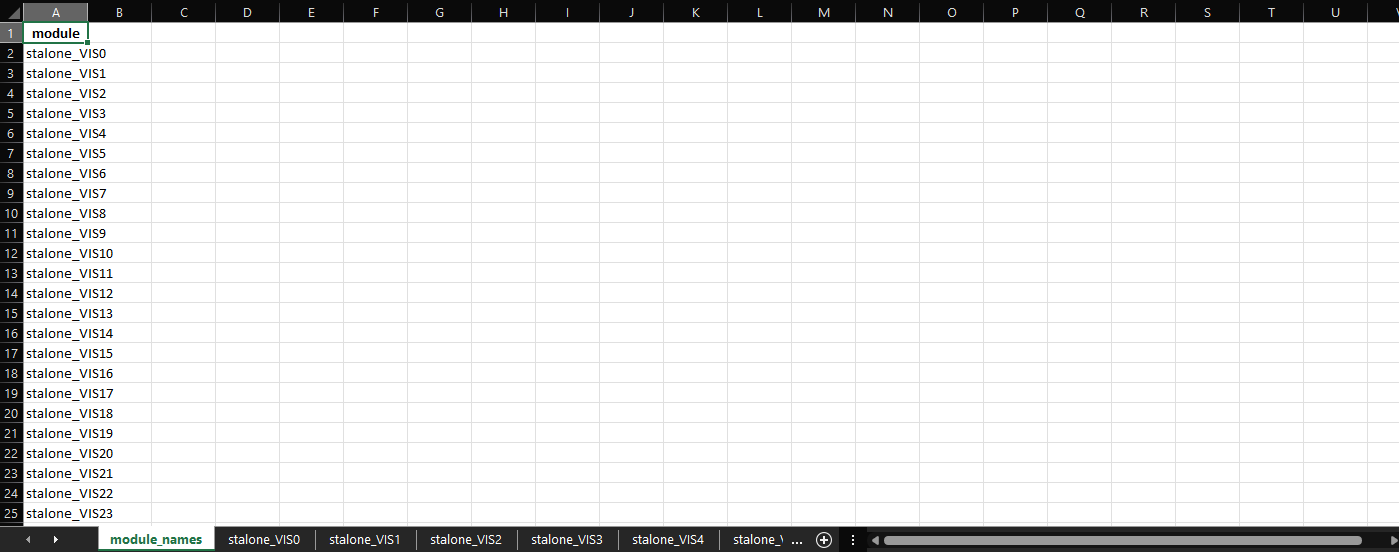

Screenshot for reference: rosmap-modules.xlsx (sheet: stalone_VIS0)
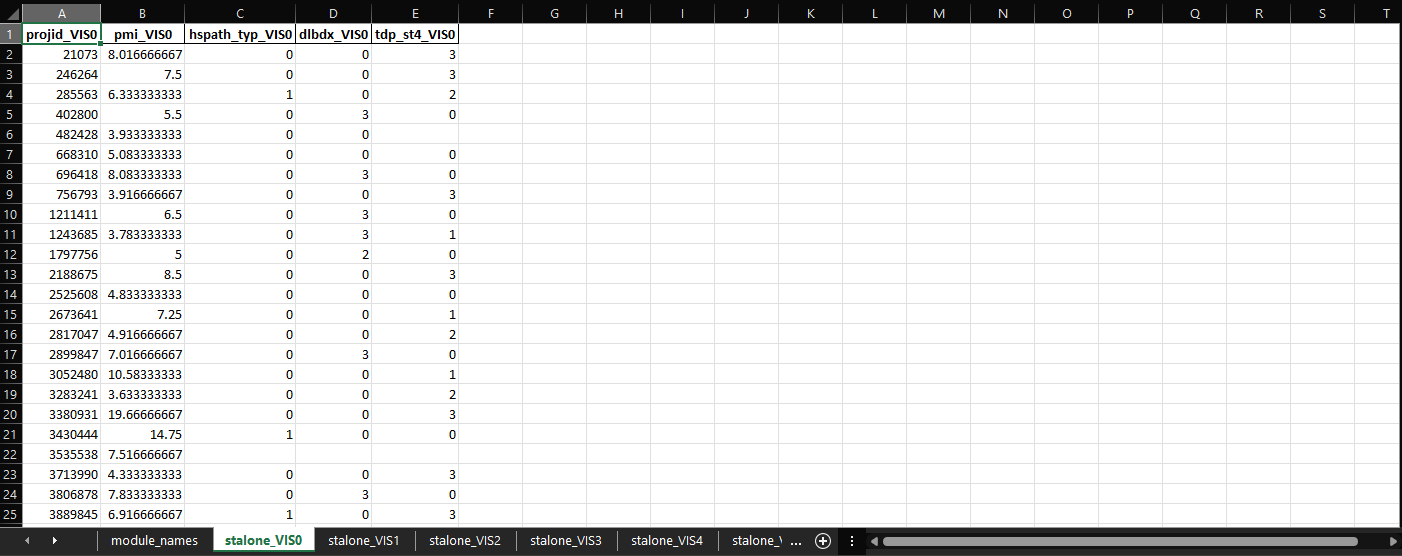

###############################################################################################################################

# Step 4 and 5
# Filter data, define aux variables, impute stalone data, define missing value positions, create data type files, subject files, columns files, save all files

- [] Filter data
- [] Define aux variables
- [] Impute stalone data
- [] Define missing value positions
- [] Create data type files
- [] Create subject files
- [] Create columns files
- [] Save all files

# Create datatypes df

- Method 1: Create an excel sheet, where the first column is the column/variable name, the second column is the datatype of the column values. Then import the excel sheet as a dataframe to this Jupyter Notebook. 
- The datatypes that I use here (referred from what is used in VAMBN-ADNI): integer, categorical, float.
- [] Method 2: Create a dataframe, where one column contains the variable names, and the other column contains the respective datatypes (shown in the code below).
- [] Make sure all column names are included.
- [] Compare the datatypes with the existing datatypes.

Screenshot for reference: datatypes on an Excel sheet
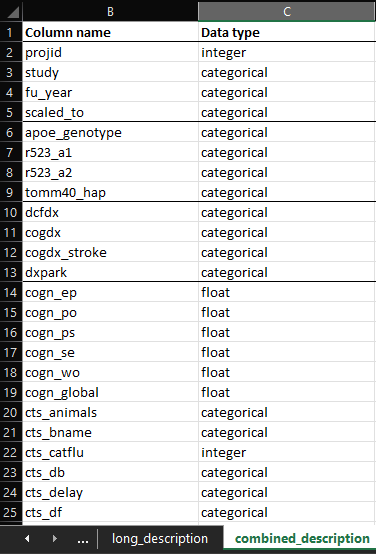

In [ ]:
data_filtered.dtypes

SUBJID                            Int64
VISIT                             Int64
DISCHARGE                         Int64
TYPE_OF_ADMISSION                 Int64
PAT_STATE                         Int64
PAT_STATUS                        Int64
SEX_CODE                          Int64
RACE                              Int64
ETHNICITY                         Int64
ADMIT_WEEKDAY                     Int64
PAT_AGE                           Int64
RISK_MORTALITY                    Int64
ILLNESS_SEVERITY                  Int64
LENGTH_OF_STAY                  Float64
TOTAL_CHARGES                   Float64
TOTAL_NON_COV_CHARGES           Float64
TOTAL_CHARGES_ACCOMM            Float64
TOTAL_NON_COV_CHARGES_ACCOMM    Float64
TOTAL_CHARGES_ANCIL             Float64
TOTAL_NON_COV_CHARGES_ANCIL     Float64
dtype: object

In [ ]:
data_filtered.head()

,SUBJID,VISIT,DISCHARGE,TYPE_OF_ADMISSION,PAT_STATE,PAT_STATUS,SEX_CODE,RACE,ETHNICITY,ADMIT_WEEKDAY,PAT_AGE,RISK_MORTALITY,ILLNESS_SEVERITY,LENGTH_OF_STAY,TOTAL_CHARGES,TOTAL_NON_COV_CHARGES,TOTAL_CHARGES_ACCOMM,TOTAL_NON_COV_CHARGES_ACCOMM,TOTAL_CHARGES_ANCIL,TOTAL_NON_COV_CHARGES_ANCIL
0,0,0,4,3,6,6,0,4,2,2,12,1,1,0.032894,0.129325,0.0,0.073945,0.0,0.128889,0.0
1,1,0,1,4,6,1,0,4,2,3,1,1,1,0.013625,0.025367,0.0,0.04286,0.0,0.010482,0.0
2,2,0,1,1,6,1,0,4,2,0,7,1,1,0.0,0.053807,0.0,0.031534,0.0,0.05348,0.0
3,3,0,3,2,6,3,1,4,2,0,14,2,1,0.02408,0.146535,0.0,0.047212,0.0,0.151285,0.0
4,4,0,4,2,6,1,1,4,2,2,12,3,3,0.02408,0.142269,0.0,0.102236,0.0,0.137319,0.0


- SUBJID ordinal
- VISIT ordinal
- DISCHARGE categorical
- TYPE_OF_ADMISSION categorical
- PAT_STATE categorical

- PAT_STATUS categorical
- SEX_CODE categorical
- RACE categorical
- ETHNICITY categorical
- ADMIT_WEEKDAY categorical

- PAT_AGE categorical
- RISK_MORTALITY categorical
- ILLNESS_SEVERITY categorical
- LENGTH_OF_STAY continuous
- TOTAL_CHARGES continuous

- TOTAL_NON_COV_CHARGES continuous
- TOTAL_CHARGES_ACCOMM continuous
- TOTAL_NON_COV_CHARGES_ACCOMM continuous
- TOTAL_CHARGES_ANCIL continuous
- TOTAL_NON_COV_CHARGES_ANCIL continuous

In [ ]:
# categorical, ordinal, continuous (there is count, but not applied)
colnames = data_filtered.columns.tolist()
datatypes = ['ordinal', 'ordinal', 'categorical', 'categorical', 'categorical',
             'categorical', 'categorical', 'categorical', 'categorical', 'categorical',
             'categorical', 'categorical', 'categorical', 'continuous', 'continuous',
             'continuous', 'continuous', 'continuous', 'continuous', 'continuous']

In [ ]:
print(colnames)
# print(data_filtered_test.columns.tolist())

['SUBJID', 'VISIT', 'DISCHARGE', 'TYPE_OF_ADMISSION', 'PAT_STATE', 'PAT_STATUS', 'SEX_CODE', 'RACE', 'ETHNICITY', 'ADMIT_WEEKDAY', 'PAT_AGE', 'RISK_MORTALITY', 'ILLNESS_SEVERITY', 'LENGTH_OF_STAY', 'TOTAL_CHARGES', 'TOTAL_NON_COV_CHARGES', 'TOTAL_CHARGES_ACCOMM', 'TOTAL_NON_COV_CHARGES_ACCOMM', 'TOTAL_CHARGES_ANCIL', 'TOTAL_NON_COV_CHARGES_ANCIL']


In [ ]:
df_datatypes = pd.DataFrame(columns=['Column name', 'Data type'])
df_datatypes['Column name'] = colnames
df_datatypes['Data type'] = datatypes
df_datatypes

,Column name,Data type
0,SUBJID,ordinal
1,VISIT,ordinal
2,DISCHARGE,categorical
3,TYPE_OF_ADMISSION,categorical
4,PAT_STATE,categorical
5,PAT_STATUS,categorical
6,SEX_CODE,categorical
7,RACE,categorical
8,ETHNICITY,categorical
9,ADMIT_WEEKDAY,categorical


In [ ]:
# Create folders if not exist (to save preprocessed files)
folder_names = ['data_python', 'python_names']

for i in folder_names:
    folder_path = f"{output_path}/{i}"
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder {i} created in the current directory.")
    else:
        print(f"Folder {i} exists in the current directory.")

# for i in folder_names:
#     folder_path = f"{output_val}/{i}"
#     if not os.path.exists(folder_path):
#         os.makedirs(folder_path)
#         print(f"Folder {i} created in the current directory.")
#     else:
#         print(f"Folder {i} exists in the current directory.")

# for i in folder_names:
#     folder_path = f"{output_test}/{i}"
#     if not os.path.exists(folder_path):
#         os.makedirs(folder_path)
#         print(f"Folder {i} created in the current directory.")
#     else:
#         print(f"Folder {i} exists in the current directory.")

# for i in folder_names:
#     folder_path = f"{output_train}/{i}"
#     if not os.path.exists(folder_path):
#         os.makedirs(folder_path)
#         print(f"Folder {i} created in the current directory.")
#     else:
#         print(f"Folder {i} exists in the current directory.")

Folder data_python exists in the current directory.
Folder python_names exists in the current directory.


In [ ]:
# check variable group names df from previous step
module_names.head()

,module
0,texas_VIS0


In [ ]:
# check data_condensed dict from previous step
data_condensed.keys()

dict_keys(['texas_VIS0'])

# Preprocessing for steps 4 and 5

Filter data, define aux variables, impute stalone data, define missing value positions, create data type files, subject files, columns files, save all files

In [ ]:
dict_aux = dict()
dict_data = dict()
dict_types = dict()
aux_module_names = list()

for i in module_names.values:
    current_module_name = i[0]
    current_vis = current_module_name.split('_')[1]
    print(f"\n[*] Currently loading variable group {current_module_name}...")
    
    # load excel sheet of current variable group
    var_group_current = data_condensed[current_module_name]
    print(f"[*] Columns: {var_group_current.columns}")
    
    ################################# FILTER DATA #################################
    
    print("[*] Step 1: Data filtering in progress...")
    
    # remove ids from the filtering process
    var_group_no_ids = var_group_current.copy()
    ids = var_group_no_ids.pop(f'SUBJID_{current_vis}')
        
    # check variance of each column
    # get column name if variance value is more than 0
    var_columns = var_group_no_ids.var(skipna=True)
    var_column_names = var_columns[var_columns > 0].keys()
    
    # check percentage of NA values in each column
    # get column name if null percentage is less than 50%
    na_columns = (var_group_no_ids.isnull().sum() / len(var_group_current)) * 100
    na_column_names = na_columns[na_columns < 50].keys()
    
    # retain columns that have variance bigger than 0 and missing data less than 50%
    #columns_selected = (var_column_names & na_column_names)
    columns_selected = var_column_names.intersection(na_column_names)
    var_group_no_ids_filtered = var_group_no_ids[columns_selected]
    print(f"[*] Selected columns: {columns_selected}")
    
    ############################## DEFINE AUXILIARY VARIABLES #####################
    
    # only proceed on this variable group if its columns are not empty from the filtering
    if var_group_no_ids_filtered.shape[1] <= 0:
        print("[*] Step 2: This variable group is filtered out. Skipped from further data-preprocessing.")
    else:
        print("[*] Step 2: Auxiliary variables creation in progress...")
        
        # record missing values as auxiliary variables
        if 'stalone_' in current_module_name:
            df_auxiliary = pd.DataFrame(columns=['ID'])
            df_auxiliary['ID'] = ids
            # if the row value is NA, assign value of 1, otherwise 0
            # change stalone column names to SA
            for column in var_group_no_ids_filtered:
                col_name = f'AUX_SA_{column}'
                for (row_key, row_value) in var_group_no_ids_filtered[column].items():
                    if pd.isna(row_value):
                        df_auxiliary.loc[df_auxiliary['ID'] == ids[row_key], col_name] = 1
                    else:
                        df_auxiliary.loc[df_auxiliary['ID'] == ids[row_key], col_name] = 0
        else:
            df_auxiliary = pd.DataFrame(columns=[f'AUX_{current_module_name}', 'ID'])
            # if the row values are all NA, assign value of 1, otherwise 0
            for (row_key, row_value) in var_group_no_ids_filtered.iterrows():
                if row_value.isnull().all():
                    df_auxiliary = df_auxiliary.append({f'AUX_{current_module_name}': 1, 'ID': ids[row_key]}, 
                                                       ignore_index=True)
                else:
                    df_auxiliary = df_auxiliary.append({f'AUX_{current_module_name}': 0, 'ID': ids[row_key]}, 
                                                       ignore_index=True)

        # append module name to aux_module_names
        aux_module_names.append(current_module_name)

        # append auxiliary variables to dict_aux_all dict
        dict_aux[current_module_name] = df_auxiliary

        print("[*] Auxiliary variables done.")
        
        ################################## IMPUTE STANDALONE DATA #######################
        
        # attach project id column to filtered data
        var_group_no_ids_filtered_copy = var_group_no_ids_filtered.copy()
            
        # if standalone, do imputation
        if 'stalone_' in current_module_name:
            print("[*] Step 3: Standalone data imputation in progress...")

            # loop through each column (without projid), but change value at the original df
            # if float value, impute value is mean. Else, impute value is mode
            for column in var_group_no_ids_filtered:
                # get data type
                col_name_no_vis = column.split('_VIS')[0]
                col_dtype = df_datatypes[df_datatypes['Column name'] == col_name_no_vis]['Data type'].values[0]
                
                # if value is float, use mean as impute value.
                if col_dtype == 'float':
                    fill_val = var_group_no_ids_filtered_copy[column].mean()
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)
                
                # if value is integer, use mode as impute value. Convert all values to int.
                elif col_dtype == 'integer':
                    fill_val = var_group_no_ids_filtered_copy[column].mode(dropna=True).values[0]
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(int)
                
                # if value is categorical, use mode as impute value. 
                elif col_dtype == 'categorical':
                    fill_val = var_group_no_ids_filtered_copy[column].mode(dropna=True).values[0]
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)
                    
                    # convert numerical values to int.
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(str)
                    if var_group_no_ids_filtered_copy[column].str.isnumeric().all():
                        var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(int)
                else:
                    print(f"[*] Column {column} type not identified. ")
                
                # check if all NA values are imputed
                nan_check = var_group_no_ids_filtered_copy[column].isna().all()
                if nan_check:
                    print(f"Note: Column {column} still contains NA.")
                
                # Add 'SA' to column names
                var_group_no_ids_filtered_copy = var_group_no_ids_filtered_copy.rename(columns={column: f"SA_{column}"})
        else:
            print("[*] Step 3: This is not a standalone variable group. Data imputation step is skipped.")
            
        # append variable group data to dict_data_all
        if not var_group_no_ids_filtered_copy.empty:
            dict_data[current_module_name] = var_group_no_ids_filtered_copy
        
        print("[*] Data imputation done.")
        
        ################################### DEFINE MISSING VALUE POSITIONS ##############

        print("[*] Step 4: Missing value searching in progress...")
        
        # create a copy of imputed df without projid 
        # reset index to get the correct row indices for missing files
        var_group_no_ids = var_group_current.reset_index(drop=True)
        ids = var_group_no_ids.pop(f'SUBJID_{current_vis}')
        df_missing = pd.DataFrame(columns=['row_index', 'column_index'])
        
        for column in var_group_no_ids:
            # get row index of every NA values 
            na_row_indices = var_group_no_ids[var_group_no_ids[column].isna()].index.tolist()

            # if there exists NA values, append row and column indices to df_missing
            # if no missing value, don't have to create missing file
            # skip file saving for standalone (not needed)
            if not 'SA_' in column:
                col_index = var_group_no_ids.columns.get_loc(column)
                if len(na_row_indices) > 0:
                    for i in range(len(na_row_indices)):
                        # column index follows R indexing - starts at 1 instead of 0
                        new_row = {'row_index': na_row_indices[i]+1, 'column_index': col_index+1}
                        df_missing = df_missing.append(new_row, ignore_index=True)

        # save the df (without projid) as csv
        if not var_group_no_ids.empty:
            # skip standalone modules
            if not 'stalone_' in current_module_name: 
                var_group_no_ids.to_csv(f'{output_path}/data_python/{current_module_name}.csv', index=False, header=None, 
                                           na_rep='NaN')
                
                # save as 'groupname_missing' csv file 
                if not df_missing.empty:
                    df_missing.to_csv(f'{output_path}/data_python/{current_module_name}_missing.csv', index=False, header=None)

            # save the projid as csv
            # make sure _subj and _cols CSV files has "x" as column names
            ids = ids.rename("x")
            ids.to_csv(f'{output_path}/python_names/{current_module_name}_subj.csv', index=False, na_rep='NaN')

            # save column names as csv
            column_names = pd.DataFrame(var_group_no_ids.columns, columns=['x'])
            column_names.to_csv(f'{output_path}/python_names/{current_module_name}_cols.csv', index=False, na_rep='NaN')
        
        print("[*] Missing value search done.")
        
        ################################## CREATE DATA TYPE FILES #####################
        
        print("[*] Step 5: Data types files saving in progress...")
        
        df_types = pd.DataFrame(columns=['type', 'dim', 'nclass'])
        
        for column in var_group_no_ids:
            # get data type
            col_name_no_vis = column.split('_VIS')[0]
            if 'SA_' in col_name_no_vis:
                col_name_no_vis = col_name_no_vis.split('SA_')[1]
            col_dtype = df_datatypes[df_datatypes['Column name'] == col_name_no_vis]['Data type'].values[0]

            # if the column is of integer type, type=ordinal, dim & nclass=number of unique values (skip na)
            if col_dtype == 'ordinal':
                row_nunique_val = var_group_no_ids[column].nunique(dropna=True)
                new_row = {'type': 'ordinal', 'dim': row_nunique_val, 'nclass': row_nunique_val}
                df_types = df_types.append(new_row, ignore_index=True)

            # if the column is of float type, type=real, dim=1, nclass=""
            # if the column is of float type, has positive value after na removed, type=pos, dim=1, nclass=""
            elif col_dtype == 'continuous':
                # check on not na values, if they are all positive
                selected = var_group_no_ids[column][~var_group_no_ids[column].isnull()]
                if all(selected > 0.0):
                    d_type = 'pos'
                else:
                    d_type = 'real'
                new_row = {'type': d_type, 'dim': 1, 'nclass': ''}
                df_types = df_types.append(new_row, ignore_index=True)

            # if the column is of categorical type, type=cat, dim & nclass=number of unique values
            elif col_dtype == 'categorical':
                row_nunique_val = var_group_no_ids[column].nunique(dropna=True)
                new_row = {'type': 'cat', 'dim': row_nunique_val, 'nclass': row_nunique_val}
                df_types = df_types.append(new_row, ignore_index=True)

            # just in case some data types are not covered
            else:
                print(f"Note: Data type not attended - {var_group_no_ids[column].dtypes}")
        
        # make a copy of the df with no na values in all rows
        df_types_filtered = df_types.dropna()
        
        # save types file if df not empty
        if not df_types_filtered.empty:
            df_types_filtered.to_csv(f'{output_path}/data_python/{current_module_name}_types.csv', index=False, na_rep='NaN')
            dict_types[current_module_name] = df_types_filtered
        
        print("[*] Data types saving done.")

################################# SAVE FILES AS A WHOLE ##############################

print("[*] Step 6: Further files saving in progress...")

# save data_aux as excel file
aux_module_names = pd.DataFrame(aux_module_names, columns=['module'])
with pd.ExcelWriter(f'{output_path}/{dataset_name}_pp_data_all_aux.xlsx') as writer:
    aux_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_aux.items():
        dict_aux[key].to_excel(writer, sheet_name=key, index=False)

# save data_all as excel file
data_module_names = pd.DataFrame(dict_data.keys(), columns=['module'])
with pd.ExcelWriter(f'{output_path}/{dataset_name}_pp_data_all_imp.xlsx') as writer:
    data_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_data.items():
        dict_data[key].to_excel(writer, sheet_name=key, index=False)    

# save dict_types as excel file
types_module_names = pd.DataFrame(dict_types.keys(), columns=['module'])
with pd.ExcelWriter(f'{output_path}/{dataset_name}_pp_data_all_types.xlsx') as writer:
    types_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_types.items():
        dict_types[key].to_excel(writer, sheet_name=key, index=False)

print("[*] All steps completed.")


[*] Currently loading variable group texas_VIS0...
[*] Columns: Index(['SUBJID_VIS0', 'DISCHARGE_VIS0', 'TYPE_OF_ADMISSION_VIS0',
       'PAT_STATE_VIS0', 'PAT_STATUS_VIS0', 'SEX_CODE_VIS0', 'RACE_VIS0',
       'ETHNICITY_VIS0', 'ADMIT_WEEKDAY_VIS0', 'PAT_AGE_VIS0',
       'RISK_MORTALITY_VIS0', 'ILLNESS_SEVERITY_VIS0', 'LENGTH_OF_STAY_VIS0',
       'TOTAL_CHARGES_VIS0', 'TOTAL_NON_COV_CHARGES_VIS0',
       'TOTAL_CHARGES_ACCOMM_VIS0', 'TOTAL_NON_COV_CHARGES_ACCOMM_VIS0',
       'TOTAL_CHARGES_ANCIL_VIS0', 'TOTAL_NON_COV_CHARGES_ANCIL_VIS0'],
      dtype='object')
[*] Step 1: Data filtering in progress...
[*] Selected columns: Index(['DISCHARGE_VIS0', 'TYPE_OF_ADMISSION_VIS0', 'PAT_STATE_VIS0',
       'PAT_STATUS_VIS0', 'SEX_CODE_VIS0', 'RACE_VIS0', 'ETHNICITY_VIS0',
       'ADMIT_WEEKDAY_VIS0', 'PAT_AGE_VIS0', 'RISK_MORTALITY_VIS0',
       'ILLNESS_SEVERITY_VIS0', 'LENGTH_OF_STAY_VIS0', 'TOTAL_CHARGES_VIS0',
       'TOTAL_NON_COV_CHARGES_VIS0', 'TOTAL_CHARGES_ACCOMM_VIS0',
       'TO

AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
dict_aux = dict()
dict_data = dict()
dict_types = dict()
aux_module_names = list()

for i in module_names.values:
    current_module_name = i[0]
    current_vis = current_module_name.split('_')[1]
    print(f"\n[*] Currently loading variable group {current_module_name}...")

    # load excel sheet of current variable group
    var_group_current = data_condensed_train[current_module_name]
    print(f"[*] Columns: {var_group_current.columns}")

    ################################# FILTER DATA #################################

    print("[*] Step 1: Data filtering in progress...")

    # remove ids from the filtering process
    var_group_no_ids = var_group_current.copy()
    ids = var_group_no_ids.pop(f'SUBJID_{current_vis}')

    # check variance of each column
    # get column name if variance value is more than 0
    var_columns = var_group_no_ids.var(skipna=True)
    var_column_names = var_columns[var_columns > 0].keys()

    # check percentage of NA values in each column
    # get column name if null percentage is less than 50%
    na_columns = (var_group_no_ids.isnull().sum() / len(var_group_current)) * 100
    na_column_names = na_columns[na_columns < 50].keys()

    # retain columns that have variance bigger than 0 and missing data less than 50%
    #columns_selected = (var_column_names & na_column_names)
    columns_selected = var_column_names.intersection(na_column_names)
    var_group_no_ids_filtered = var_group_no_ids[columns_selected]
    print(f"[*] Selected columns: {columns_selected}")

    ############################## DEFINE AUXILIARY VARIABLES #####################

    # only proceed on this variable group if its columns are not empty from the filtering
    if var_group_no_ids_filtered.shape[1] <= 0:
        print("[*] Step 2: This variable group is filtered out. Skipped from further data-preprocessing.")
    else:
        print("[*] Step 2: Auxiliary variables creation in progress...")

        # record missing values as auxiliary variables
        if 'stalone_' in current_module_name:
            df_auxiliary = pd.DataFrame(columns=['ID'])
            df_auxiliary['ID'] = ids
            # if the row value is NA, assign value of 1, otherwise 0
            # change stalone column names to SA
            for column in var_group_no_ids_filtered:
                col_name = f'AUX_SA_{column}'
                for (row_key, row_value) in var_group_no_ids_filtered[column].items():
                    if pd.isna(row_value):
                        df_auxiliary.loc[df_auxiliary['ID'] == ids[row_key], col_name] = 1
                    else:
                        df_auxiliary.loc[df_auxiliary['ID'] == ids[row_key], col_name] = 0
        else:
            df_auxiliary = pd.DataFrame(columns=[f'AUX_{current_module_name}', 'ID'])
            # if the row values are all NA, assign value of 1, otherwise 0
            for (row_key, row_value) in var_group_no_ids_filtered.iterrows():
                if row_value.isnull().all():
                    df_auxiliary = df_auxiliary.append({f'AUX_{current_module_name}': 1, 'ID': ids[row_key]},
                                                       ignore_index=True)
                else:
                    df_auxiliary = df_auxiliary.append({f'AUX_{current_module_name}': 0, 'ID': ids[row_key]},
                                                       ignore_index=True)

        # append module name to aux_module_names
        aux_module_names.append(current_module_name)

        # append auxiliary variables to dict_aux_all dict
        dict_aux[current_module_name] = df_auxiliary

        print("[*] Auxiliary variables done.")

        ################################## IMPUTE STANDALONE DATA #######################

        # attach project id column to filtered data
        var_group_no_ids_filtered_copy = var_group_no_ids_filtered.copy()

        # if standalone, do imputation
        if 'stalone_' in current_module_name:
            print("[*] Step 3: Standalone data imputation in progress...")

            # loop through each column (without projid), but change value at the original df
            # if float value, impute value is mean. Else, impute value is mode
            for column in var_group_no_ids_filtered:
                # get data type
                col_name_no_vis = column.split('_VIS')[0]
                col_dtype = df_datatypes[df_datatypes['Column name'] == col_name_no_vis]['Data type'].values[0]

                # if value is float, use mean as impute value.
                if col_dtype == 'float':
                    fill_val = var_group_no_ids_filtered_copy[column].mean()
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)

                # if value is integer, use mode as impute value. Convert all values to int.
                elif col_dtype == 'integer':
                    fill_val = var_group_no_ids_filtered_copy[column].mode(dropna=True).values[0]
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(int)

                # if value is categorical, use mode as impute value.
                elif col_dtype == 'categorical':
                    fill_val = var_group_no_ids_filtered_copy[column].mode(dropna=True).values[0]
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)

                    # convert numerical values to int.
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(str)
                    if var_group_no_ids_filtered_copy[column].str.isnumeric().all():
                        var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(int)
                else:
                    print(f"[*] Column {column} type not identified. ")

                # check if all NA values are imputed
                nan_check = var_group_no_ids_filtered_copy[column].isna().all()
                if nan_check:
                    print(f"Note: Column {column} still contains NA.")

                # Add 'SA' to column names
                var_group_no_ids_filtered_copy = var_group_no_ids_filtered_copy.rename(columns={column: f"SA_{column}"})
        else:
            print("[*] Step 3: This is not a standalone variable group. Data imputation step is skipped.")

        # append variable group data to dict_data_all
        if not var_group_no_ids_filtered_copy.empty:
            dict_data[current_module_name] = var_group_no_ids_filtered_copy

        print("[*] Data imputation done.")

        ################################### DEFINE MISSING VALUE POSITIONS ##############

        print("[*] Step 4: Missing value searching in progress...")

        # create a copy of imputed df without projid
        # reset index to get the correct row indices for missing files
        var_group_no_ids = var_group_current.reset_index(drop=True)
        ids = var_group_no_ids.pop(f'SUBJID_{current_vis}')
        df_missing = pd.DataFrame(columns=['row_index', 'column_index'])

        for column in var_group_no_ids:
            # get row index of every NA values
            na_row_indices = var_group_no_ids[var_group_no_ids[column].isna()].index.tolist()

            # if there exists NA values, append row and column indices to df_missing
            # if no missing value, don't have to create missing file
            # skip file saving for standalone (not needed)
            if not 'SA_' in column:
                col_index = var_group_no_ids.columns.get_loc(column)
                if len(na_row_indices) > 0:
                    for i in range(len(na_row_indices)):
                        # column index follows R indexing - starts at 1 instead of 0
                        new_row = {'row_index': na_row_indices[i]+1, 'column_index': col_index+1}
                        df_missing = df_missing.append(new_row, ignore_index=True)

        # save the df (without projid) as csv
        if not var_group_no_ids.empty:
            # skip standalone modules
            if not 'stalone_' in current_module_name:
                var_group_no_ids.to_csv(f'{output_train}/data_python/{current_module_name}.csv', index=False, header=None,
                                           na_rep='NaN')

                # save as 'groupname_missing' csv file
                if not df_missing.empty:
                    df_missing.to_csv(f'{output_train}/data_python/{current_module_name}_missing.csv', index=False, header=None)

            # save the projid as csv
            # make sure _subj and _cols CSV files has "x" as column names
            ids = ids.rename("x")
            ids.to_csv(f'{output_train}/python_names/{current_module_name}_subj.csv', index=False, na_rep='NaN')

            # save column names as csv
            column_names = pd.DataFrame(var_group_no_ids.columns, columns=['x'])
            column_names.to_csv(f'{output_train}/python_names/{current_module_name}_cols.csv', index=False, na_rep='NaN')

        print("[*] Missing value search done.")

        ################################## CREATE DATA TYPE FILES #####################

        print("[*] Step 5: Data types files saving in progress...")

        df_types = pd.DataFrame(columns=['type', 'dim', 'nclass'])

        for column in var_group_no_ids:
            # get data type
            col_name_no_vis = column.split('_VIS')[0]
            if 'SA_' in col_name_no_vis:
                col_name_no_vis = col_name_no_vis.split('SA_')[1]
            col_dtype = df_datatypes[df_datatypes['Column name'] == col_name_no_vis]['Data type'].values[0]

            # if the column is of integer type, type=ordinal, dim & nclass=number of unique values (skip na)
            if col_dtype == 'ordinal':
                row_nunique_val = var_group_no_ids[column].nunique(dropna=True)
                new_row = {'type': 'ordinal', 'dim': row_nunique_val, 'nclass': row_nunique_val}
                df_types = df_types.append(new_row, ignore_index=True)

            # if the column is of float type, type=real, dim=1, nclass=""
            # if the column is of float type, has positive value after na removed, type=pos, dim=1, nclass=""
            elif col_dtype == 'continuous':
                # check on not na values, if they are all positive
                selected = var_group_no_ids[column][~var_group_no_ids[column].isnull()]
                if all(selected > 0.0):
                    d_type = 'pos'
                else:
                    d_type = 'real'
                new_row = {'type': d_type, 'dim': 1, 'nclass': ''}
                df_types = df_types.append(new_row, ignore_index=True)

            # if the column is of categorical type, type=cat, dim & nclass=number of unique values
            elif col_dtype == 'categorical':
                row_nunique_val = var_group_no_ids[column].nunique(dropna=True)
                new_row = {'type': 'cat', 'dim': row_nunique_val, 'nclass': row_nunique_val}
                df_types = df_types.append(new_row, ignore_index=True)

            # just in case some data types are not covered
            else:
                print(f"Note: Data type not attended - {var_group_no_ids[column].dtypes}")

        # make a copy of the df with no na values in all rows
        df_types_filtered = df_types.dropna()

        # save types file if df not empty
        if not df_types_filtered.empty:
            df_types_filtered.to_csv(f'{output_train}/data_python/{current_module_name}_types.csv', index=False, na_rep='NaN')
            dict_types[current_module_name] = df_types_filtered

        print("[*] Data types saving done.")

################################# SAVE FILES AS A WHOLE ##############################

print("[*] Step 6: Further files saving in progress...")

# save data_aux as excel file
aux_module_names = pd.DataFrame(aux_module_names, columns=['module'])
with pd.ExcelWriter(f'{output_train}/{dataset_name}_pp_data_all_aux.xlsx') as writer:
    aux_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_aux.items():
        dict_aux[key].to_excel(writer, sheet_name=key, index=False)

# save data_all as excel file
data_module_names = pd.DataFrame(dict_data.keys(), columns=['module'])
with pd.ExcelWriter(f'{output_train}/{dataset_name}_pp_data_all_imp.xlsx') as writer:
    data_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_data.items():
        dict_data[key].to_excel(writer, sheet_name=key, index=False)

# save dict_types as excel file
types_module_names = pd.DataFrame(dict_types.keys(), columns=['module'])
with pd.ExcelWriter(f'{output_train}/{dataset_name}_pp_data_all_types.xlsx') as writer:
    types_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_types.items():
        dict_types[key].to_excel(writer, sheet_name=key, index=False)

print("[*] All steps completed.")

In [ ]:
dict_aux = dict()
dict_data = dict()
dict_types = dict()
aux_module_names = list()

for i in module_names.values:
    current_module_name = i[0]
    current_vis = current_module_name.split('_')[1]
    print(f"\n[*] Currently loading variable group {current_module_name}...")

    # load excel sheet of current variable group
    var_group_current = data_condensed_val[current_module_name]
    print(f"[*] Columns: {var_group_current.columns}")

    ################################# FILTER DATA #################################

    print("[*] Step 1: Data filtering in progress...")

    # remove ids from the filtering process
    var_group_no_ids = var_group_current.copy()
    ids = var_group_no_ids.pop(f'SUBJID_{current_vis}')

    # check variance of each column
    # get column name if variance value is more than 0
    var_columns = var_group_no_ids.var(skipna=True)
    var_column_names = var_columns[var_columns > 0].keys()

    # check percentage of NA values in each column
    # get column name if null percentage is less than 50%
    na_columns = (var_group_no_ids.isnull().sum() / len(var_group_current)) * 100
    na_column_names = na_columns[na_columns < 50].keys()

    # retain columns that have variance bigger than 0 and missing data less than 50%
    #columns_selected = (var_column_names & na_column_names)
    columns_selected = var_column_names.intersection(na_column_names)
    var_group_no_ids_filtered = var_group_no_ids[columns_selected]
    print(f"[*] Selected columns: {columns_selected}")

    ############################## DEFINE AUXILIARY VARIABLES #####################

    # only proceed on this variable group if its columns are not empty from the filtering
    if var_group_no_ids_filtered.shape[1] <= 0:
        print("[*] Step 2: This variable group is filtered out. Skipped from further data-preprocessing.")
    else:
        print("[*] Step 2: Auxiliary variables creation in progress...")

        # record missing values as auxiliary variables
        if 'stalone_' in current_module_name:
            df_auxiliary = pd.DataFrame(columns=['ID'])
            df_auxiliary['ID'] = ids
            # if the row value is NA, assign value of 1, otherwise 0
            # change stalone column names to SA
            for column in var_group_no_ids_filtered:
                col_name = f'AUX_SA_{column}'
                for (row_key, row_value) in var_group_no_ids_filtered[column].items():
                    if pd.isna(row_value):
                        df_auxiliary.loc[df_auxiliary['ID'] == ids[row_key], col_name] = 1
                    else:
                        df_auxiliary.loc[df_auxiliary['ID'] == ids[row_key], col_name] = 0
        else:
            df_auxiliary = pd.DataFrame(columns=[f'AUX_{current_module_name}', 'ID'])
            # if the row values are all NA, assign value of 1, otherwise 0
            for (row_key, row_value) in var_group_no_ids_filtered.iterrows():
                if row_value.isnull().all():
                    df_auxiliary = df_auxiliary.append({f'AUX_{current_module_name}': 1, 'ID': ids[row_key]},
                                                       ignore_index=True)
                else:
                    df_auxiliary = df_auxiliary.append({f'AUX_{current_module_name}': 0, 'ID': ids[row_key]},
                                                       ignore_index=True)

        # append module name to aux_module_names
        aux_module_names.append(current_module_name)

        # append auxiliary variables to dict_aux_all dict
        dict_aux[current_module_name] = df_auxiliary

        print("[*] Auxiliary variables done.")

        ################################## IMPUTE STANDALONE DATA #######################

        # attach project id column to filtered data
        var_group_no_ids_filtered_copy = var_group_no_ids_filtered.copy()

        # if standalone, do imputation
        if 'stalone_' in current_module_name:
            print("[*] Step 3: Standalone data imputation in progress...")

            # loop through each column (without projid), but change value at the original df
            # if float value, impute value is mean. Else, impute value is mode
            for column in var_group_no_ids_filtered:
                # get data type
                col_name_no_vis = column.split('_VIS')[0]
                col_dtype = df_datatypes[df_datatypes['Column name'] == col_name_no_vis]['Data type'].values[0]

                # if value is float, use mean as impute value.
                if col_dtype == 'float':
                    fill_val = var_group_no_ids_filtered_copy[column].mean()
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)

                # if value is integer, use mode as impute value. Convert all values to int.
                elif col_dtype == 'integer':
                    fill_val = var_group_no_ids_filtered_copy[column].mode(dropna=True).values[0]
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(int)

                # if value is categorical, use mode as impute value.
                elif col_dtype == 'categorical':
                    fill_val = var_group_no_ids_filtered_copy[column].mode(dropna=True).values[0]
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)

                    # convert numerical values to int.
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(str)
                    if var_group_no_ids_filtered_copy[column].str.isnumeric().all():
                        var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(int)
                else:
                    print(f"[*] Column {column} type not identified. ")

                # check if all NA values are imputed
                nan_check = var_group_no_ids_filtered_copy[column].isna().all()
                if nan_check:
                    print(f"Note: Column {column} still contains NA.")

                # Add 'SA' to column names
                var_group_no_ids_filtered_copy = var_group_no_ids_filtered_copy.rename(columns={column: f"SA_{column}"})
        else:
            print("[*] Step 3: This is not a standalone variable group. Data imputation step is skipped.")

        # append variable group data to dict_data_all
        if not var_group_no_ids_filtered_copy.empty:
            dict_data[current_module_name] = var_group_no_ids_filtered_copy

        print("[*] Data imputation done.")

        ################################### DEFINE MISSING VALUE POSITIONS ##############

        print("[*] Step 4: Missing value searching in progress...")

        # create a copy of imputed df without projid
        # reset index to get the correct row indices for missing files
        var_group_no_ids = var_group_current.reset_index(drop=True)
        ids = var_group_no_ids.pop(f'SUBJID_{current_vis}')
        df_missing = pd.DataFrame(columns=['row_index', 'column_index'])

        for column in var_group_no_ids:
            # get row index of every NA values
            na_row_indices = var_group_no_ids[var_group_no_ids[column].isna()].index.tolist()

            # if there exists NA values, append row and column indices to df_missing
            # if no missing value, don't have to create missing file
            # skip file saving for standalone (not needed)
            if not 'SA_' in column:
                col_index = var_group_no_ids.columns.get_loc(column)
                if len(na_row_indices) > 0:
                    for i in range(len(na_row_indices)):
                        # column index follows R indexing - starts at 1 instead of 0
                        new_row = {'row_index': na_row_indices[i]+1, 'column_index': col_index+1}
                        df_missing = df_missing.append(new_row, ignore_index=True)

        # save the df (without projid) as csv
        if not var_group_no_ids.empty:
            # skip standalone modules
            if not 'stalone_' in current_module_name:
                var_group_no_ids.to_csv(f'{output_val}/data_python/{current_module_name}.csv', index=False, header=None,
                                           na_rep='NaN')

                # save as 'groupname_missing' csv file
                if not df_missing.empty:
                    df_missing.to_csv(f'{output_val}/data_python/{current_module_name}_missing.csv', index=False, header=None)

            # save the projid as csv
            # make sure _subj and _cols CSV files has "x" as column names
            ids = ids.rename("x")
            ids.to_csv(f'{output_val}/python_names/{current_module_name}_subj.csv', index=False, na_rep='NaN')

            # save column names as csv
            column_names = pd.DataFrame(var_group_no_ids.columns, columns=['x'])
            column_names.to_csv(f'{output_val}/python_names/{current_module_name}_cols.csv', index=False, na_rep='NaN')

        print("[*] Missing value search done.")

        ################################## CREATE DATA TYPE FILES #####################

        print("[*] Step 5: Data types files saving in progress...")

        df_types = pd.DataFrame(columns=['type', 'dim', 'nclass'])

        for column in var_group_no_ids:
            # get data type
            col_name_no_vis = column.split('_VIS')[0]
            if 'SA_' in col_name_no_vis:
                col_name_no_vis = col_name_no_vis.split('SA_')[1]
            col_dtype = df_datatypes[df_datatypes['Column name'] == col_name_no_vis]['Data type'].values[0]

            # if the column is of integer type, type=ordinal, dim & nclass=number of unique values (skip na)
            if col_dtype == 'ordinal':
                row_nunique_val = var_group_no_ids[column].nunique(dropna=True)
                new_row = {'type': 'ordinal', 'dim': row_nunique_val, 'nclass': row_nunique_val}
                df_types = df_types.append(new_row, ignore_index=True)

            # if the column is of float type, type=real, dim=1, nclass=""
            # if the column is of float type, has positive value after na removed, type=pos, dim=1, nclass=""
            elif col_dtype == 'continuous':
                # check on not na values, if they are all positive
                selected = var_group_no_ids[column][~var_group_no_ids[column].isnull()]
                if all(selected > 0.0):
                    d_type = 'pos'
                else:
                    d_type = 'real'
                new_row = {'type': d_type, 'dim': 1, 'nclass': ''}
                df_types = df_types.append(new_row, ignore_index=True)

            # if the column is of categorical type, type=cat, dim & nclass=number of unique values
            elif col_dtype == 'categorical':
                row_nunique_val = var_group_no_ids[column].nunique(dropna=True)
                new_row = {'type': 'cat', 'dim': row_nunique_val, 'nclass': row_nunique_val}
                df_types = df_types.append(new_row, ignore_index=True)

            # just in case some data types are not covered
            else:
                print(f"Note: Data type not attended - {var_group_no_ids[column].dtypes}")

        # make a copy of the df with no na values in all rows
        df_types_filtered = df_types.dropna()

        # save types file if df not empty
        if not df_types_filtered.empty:
            df_types_filtered.to_csv(f'{output_val}/data_python/{current_module_name}_types.csv', index=False, na_rep='NaN')
            dict_types[current_module_name] = df_types_filtered

        print("[*] Data types saving done.")

################################# SAVE FILES AS A WHOLE ##############################

print("[*] Step 6: Further files saving in progress...")

# save data_aux as excel file
aux_module_names = pd.DataFrame(aux_module_names, columns=['module'])
with pd.ExcelWriter(f'{output_val}/{dataset_name}_pp_data_all_aux.xlsx') as writer:
    aux_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_aux.items():
        dict_aux[key].to_excel(writer, sheet_name=key, index=False)

# save data_all as excel file
data_module_names = pd.DataFrame(dict_data.keys(), columns=['module'])
with pd.ExcelWriter(f'{output_val}/{dataset_name}_pp_data_all_imp.xlsx') as writer:
    data_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_data.items():
        dict_data[key].to_excel(writer, sheet_name=key, index=False)

# save dict_types as excel file
types_module_names = pd.DataFrame(dict_types.keys(), columns=['module'])
with pd.ExcelWriter(f'{output_val}/{dataset_name}_pp_data_all_types.xlsx') as writer:
    types_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_types.items():
        dict_types[key].to_excel(writer, sheet_name=key, index=False)

print("[*] All steps completed.")

In [ ]:
dict_aux = dict()
dict_data = dict()
dict_types = dict()
aux_module_names = list()

for i in module_names.values:
    current_module_name = i[0]
    current_vis = current_module_name.split('_')[1]
    print(f"\n[*] Currently loading variable group {current_module_name}...")

    # load excel sheet of current variable group
    var_group_current = data_condensed_test[current_module_name]
    print(f"[*] Columns: {var_group_current.columns}")

    ################################# FILTER DATA #################################

    print("[*] Step 1: Data filtering in progress...")

    # remove ids from the filtering process
    var_group_no_ids = var_group_current.copy()
    ids = var_group_no_ids.pop(f'SUBJID_{current_vis}')

    # check variance of each column
    # get column name if variance value is more than 0
    var_columns = var_group_no_ids.var(skipna=True)
    var_column_names = var_columns[var_columns > 0].keys()

    # check percentage of NA values in each column
    # get column name if null percentage is less than 50%
    na_columns = (var_group_no_ids.isnull().sum() / len(var_group_current)) * 100
    na_column_names = na_columns[na_columns < 50].keys()

    # retain columns that have variance bigger than 0 and missing data less than 50%
    #columns_selected = (var_column_names & na_column_names)
    columns_selected = var_column_names.intersection(na_column_names)
    var_group_no_ids_filtered = var_group_no_ids[columns_selected]
    print(f"[*] Selected columns: {columns_selected}")

    ############################## DEFINE AUXILIARY VARIABLES #####################

    # only proceed on this variable group if its columns are not empty from the filtering
    if var_group_no_ids_filtered.shape[1] <= 0:
        print("[*] Step 2: This variable group is filtered out. Skipped from further data-preprocessing.")
    else:
        print("[*] Step 2: Auxiliary variables creation in progress...")

        # record missing values as auxiliary variables
        if 'stalone_' in current_module_name:
            df_auxiliary = pd.DataFrame(columns=['ID'])
            df_auxiliary['ID'] = ids
            # if the row value is NA, assign value of 1, otherwise 0
            # change stalone column names to SA
            for column in var_group_no_ids_filtered:
                col_name = f'AUX_SA_{column}'
                for (row_key, row_value) in var_group_no_ids_filtered[column].items():
                    if pd.isna(row_value):
                        df_auxiliary.loc[df_auxiliary['ID'] == ids[row_key], col_name] = 1
                    else:
                        df_auxiliary.loc[df_auxiliary['ID'] == ids[row_key], col_name] = 0
        else:
            df_auxiliary = pd.DataFrame(columns=[f'AUX_{current_module_name}', 'ID'])
            # if the row values are all NA, assign value of 1, otherwise 0
            for (row_key, row_value) in var_group_no_ids_filtered.iterrows():
                if row_value.isnull().all():
                    df_auxiliary = df_auxiliary.append({f'AUX_{current_module_name}': 1, 'ID': ids[row_key]},
                                                       ignore_index=True)
                else:
                    df_auxiliary = df_auxiliary.append({f'AUX_{current_module_name}': 0, 'ID': ids[row_key]},
                                                       ignore_index=True)

        # append module name to aux_module_names
        aux_module_names.append(current_module_name)

        # append auxiliary variables to dict_aux_all dict
        dict_aux[current_module_name] = df_auxiliary

        print("[*] Auxiliary variables done.")

        ################################## IMPUTE STANDALONE DATA #######################

        # attach project id column to filtered data
        var_group_no_ids_filtered_copy = var_group_no_ids_filtered.copy()

        # if standalone, do imputation
        if 'stalone_' in current_module_name:
            print("[*] Step 3: Standalone data imputation in progress...")

            # loop through each column (without projid), but change value at the original df
            # if float value, impute value is mean. Else, impute value is mode
            for column in var_group_no_ids_filtered:
                # get data type
                col_name_no_vis = column.split('_VIS')[0]
                col_dtype = df_datatypes[df_datatypes['Column name'] == col_name_no_vis]['Data type'].values[0]

                # if value is float, use mean as impute value.
                if col_dtype == 'float':
                    fill_val = var_group_no_ids_filtered_copy[column].mean()
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)

                # if value is integer, use mode as impute value. Convert all values to int.
                elif col_dtype == 'integer':
                    fill_val = var_group_no_ids_filtered_copy[column].mode(dropna=True).values[0]
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(int)

                # if value is categorical, use mode as impute value.
                elif col_dtype == 'categorical':
                    fill_val = var_group_no_ids_filtered_copy[column].mode(dropna=True).values[0]
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].fillna(fill_val)

                    # convert numerical values to int.
                    var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(str)
                    if var_group_no_ids_filtered_copy[column].str.isnumeric().all():
                        var_group_no_ids_filtered_copy[column] = var_group_no_ids_filtered_copy[column].astype(int)
                else:
                    print(f"[*] Column {column} type not identified. ")

                # check if all NA values are imputed
                nan_check = var_group_no_ids_filtered_copy[column].isna().all()
                if nan_check:
                    print(f"Note: Column {column} still contains NA.")

                # Add 'SA' to column names
                var_group_no_ids_filtered_copy = var_group_no_ids_filtered_copy.rename(columns={column: f"SA_{column}"})
        else:
            print("[*] Step 3: This is not a standalone variable group. Data imputation step is skipped.")

        # append variable group data to dict_data_all
        if not var_group_no_ids_filtered_copy.empty:
            dict_data[current_module_name] = var_group_no_ids_filtered_copy

        print("[*] Data imputation done.")

        ################################### DEFINE MISSING VALUE POSITIONS ##############

        print("[*] Step 4: Missing value searching in progress...")

        # create a copy of imputed df without projid
        # reset index to get the correct row indices for missing files
        var_group_no_ids = var_group_current.reset_index(drop=True)
        ids = var_group_no_ids.pop(f'SUBJID_{current_vis}')
        df_missing = pd.DataFrame(columns=['row_index', 'column_index'])

        for column in var_group_no_ids:
            # get row index of every NA values
            na_row_indices = var_group_no_ids[var_group_no_ids[column].isna()].index.tolist()

            # if there exists NA values, append row and column indices to df_missing
            # if no missing value, don't have to create missing file
            # skip file saving for standalone (not needed)
            if not 'SA_' in column:
                col_index = var_group_no_ids.columns.get_loc(column)
                if len(na_row_indices) > 0:
                    for i in range(len(na_row_indices)):
                        # column index follows R indexing - starts at 1 instead of 0
                        new_row = {'row_index': na_row_indices[i]+1, 'column_index': col_index+1}
                        df_missing = df_missing.append(new_row, ignore_index=True)

        # save the df (without projid) as csv
        if not var_group_no_ids.empty:
            # skip standalone modules
            if not 'stalone_' in current_module_name:
                var_group_no_ids.to_csv(f'{output_test}/data_python/{current_module_name}.csv', index=False, header=None,
                                           na_rep='NaN')

                # save as 'groupname_missing' csv file
                if not df_missing.empty:
                    df_missing.to_csv(f'{output_test}/data_python/{current_module_name}_missing.csv', index=False, header=None)

            # save the projid as csv
            # make sure _subj and _cols CSV files has "x" as column names
            ids = ids.rename("x")
            ids.to_csv(f'{output_test}/python_names/{current_module_name}_subj.csv', index=False, na_rep='NaN')

            # save column names as csv
            column_names = pd.DataFrame(var_group_no_ids.columns, columns=['x'])
            column_names.to_csv(f'{output_test}/python_names/{current_module_name}_cols.csv', index=False, na_rep='NaN')

        print("[*] Missing value search done.")

        ################################## CREATE DATA TYPE FILES #####################

        print("[*] Step 5: Data types files saving in progress...")

        df_types = pd.DataFrame(columns=['type', 'dim', 'nclass'])

        for column in var_group_no_ids:
            # get data type
            col_name_no_vis = column.split('_VIS')[0]
            if 'SA_' in col_name_no_vis:
                col_name_no_vis = col_name_no_vis.split('SA_')[1]
            col_dtype = df_datatypes[df_datatypes['Column name'] == col_name_no_vis]['Data type'].values[0]

            # if the column is of integer type, type=ordinal, dim & nclass=number of unique values (skip na)
            if col_dtype == 'ordinal':
                row_nunique_val = var_group_no_ids[column].nunique(dropna=True)
                new_row = {'type': 'ordinal', 'dim': row_nunique_val, 'nclass': row_nunique_val}
                df_types = df_types.append(new_row, ignore_index=True)

            # if the column is of float type, type=real, dim=1, nclass=""
            # if the column is of float type, has positive value after na removed, type=pos, dim=1, nclass=""
            elif col_dtype == 'continuous':
                # check on not na values, if they are all positive
                selected = var_group_no_ids[column][~var_group_no_ids[column].isnull()]
                if all(selected > 0.0):
                    d_type = 'pos'
                else:
                    d_type = 'real'
                new_row = {'type': d_type, 'dim': 1, 'nclass': ''}
                df_types = df_types.append(new_row, ignore_index=True)

            # if the column is of categorical type, type=cat, dim & nclass=number of unique values
            elif col_dtype == 'categorical':
                row_nunique_val = var_group_no_ids[column].nunique(dropna=True)
                new_row = {'type': 'cat', 'dim': row_nunique_val, 'nclass': row_nunique_val}
                df_types = df_types.append(new_row, ignore_index=True)

            # just in case some data types are not covered
            else:
                print(f"Note: Data type not attended - {var_group_no_ids[column].dtypes}")

        # make a copy of the df with no na values in all rows
        df_types_filtered = df_types.dropna()

        # save types file if df not empty
        if not df_types_filtered.empty:
            df_types_filtered.to_csv(f'{output_test}/data_python/{current_module_name}_types.csv', index=False, na_rep='NaN')
            dict_types[current_module_name] = df_types_filtered

        print("[*] Data types saving done.")

################################# SAVE FILES AS A WHOLE ##############################

print("[*] Step 6: Further files saving in progress...")

# save data_aux as excel file
aux_module_names = pd.DataFrame(aux_module_names, columns=['module'])
with pd.ExcelWriter(f'{output_test}/{dataset_name}_pp_data_all_aux.xlsx') as writer:
    aux_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_aux.items():
        dict_aux[key].to_excel(writer, sheet_name=key, index=False)

# save data_all as excel file
data_module_names = pd.DataFrame(dict_data.keys(), columns=['module'])
with pd.ExcelWriter(f'{output_test}/{dataset_name}_pp_data_all_imp.xlsx') as writer:
    data_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_data.items():
        dict_data[key].to_excel(writer, sheet_name=key, index=False)

# save dict_types as excel file
types_module_names = pd.DataFrame(dict_types.keys(), columns=['module'])
with pd.ExcelWriter(f'{output_test}/{dataset_name}_pp_data_all_types.xlsx') as writer:
    types_module_names.to_excel(writer, sheet_name='module_names', index=False)
    for (key, value) in dict_types.items():
        dict_types[key].to_excel(writer, sheet_name=key, index=False)

print("[*] All steps completed.")

In [ ]:
print(f"Number of variable groups (final): {len(dict_data.keys())}")

In [ ]:
# calculate maximum percentage of missingness in every variable group
for i in dict_data:
    df_current = dict_data[i]
    percent_na = ((df_current.isnull().sum()/len(df_current))*100).max()
    data_size = df_current.shape
    print(f"{i}: missingness = {percent_na:.02f}%, data_size = {data_size}")

# Sanity check
The file structure and formats should look like these:

Screenshot for reference: Folder ./preprocessed
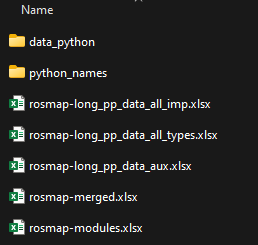

Screenshot for reference: File ./preprocessed/rosmap-long_pp_data_all_imp.xlsx (sheet: module_names)
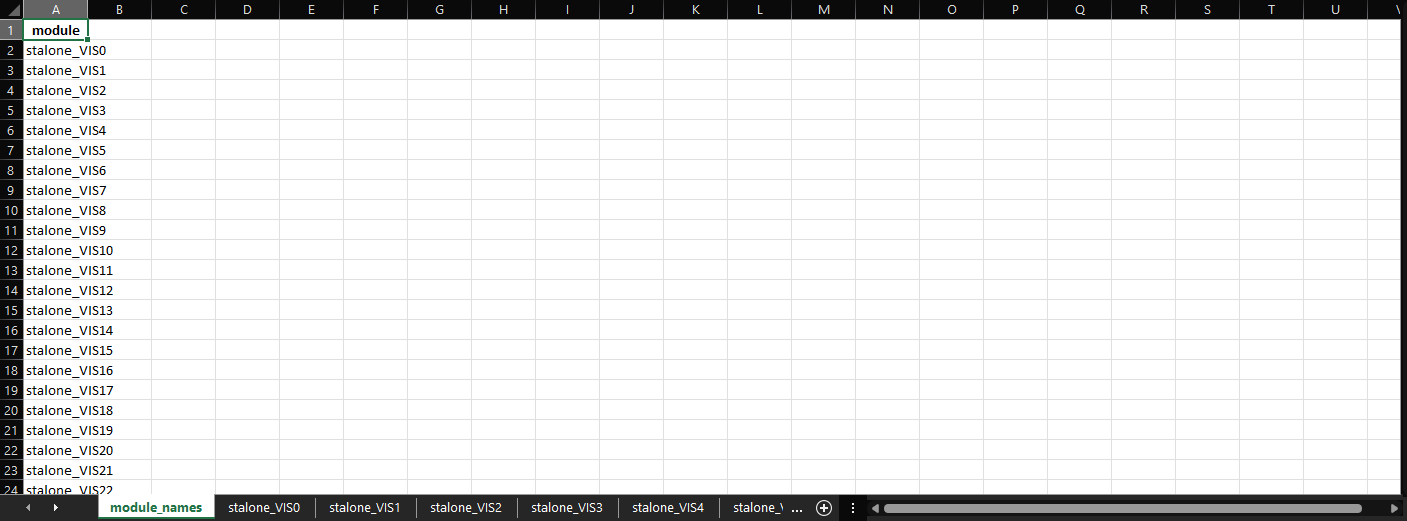

Screenshot for reference: File ./preprocessed/rosmap-long_pp_data_all_imp.xlsx (sheet: stalone_VIS0)
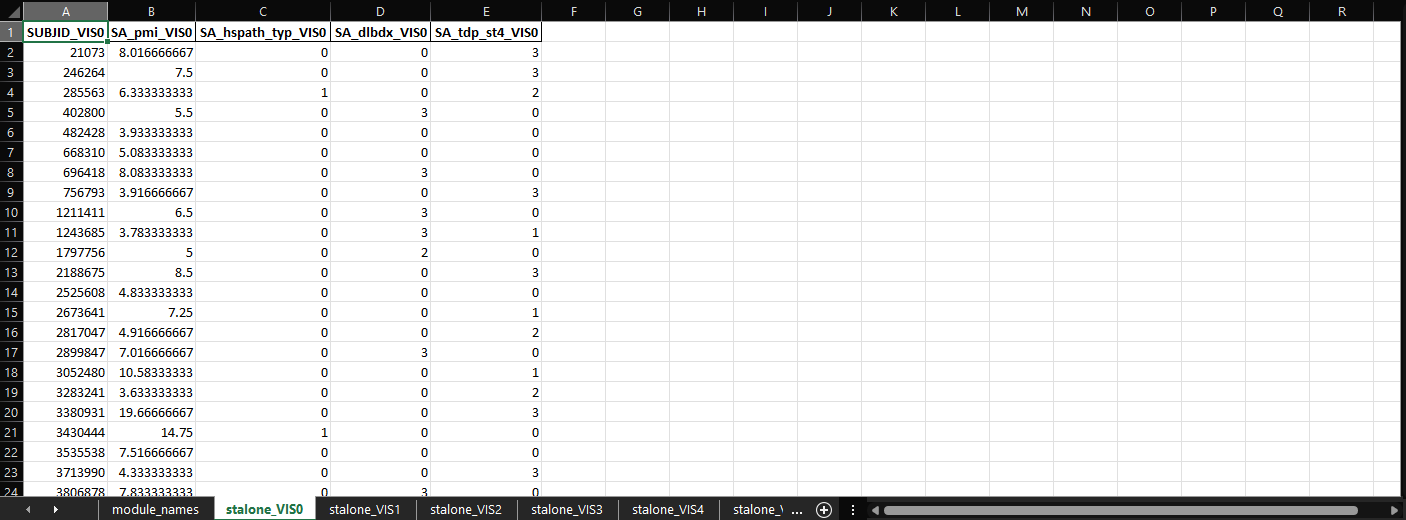

Screenshot for reference: File ./preprocessed/rosmap-long_pp_data_all_types.xlsx (sheet: stalone_VIS0)
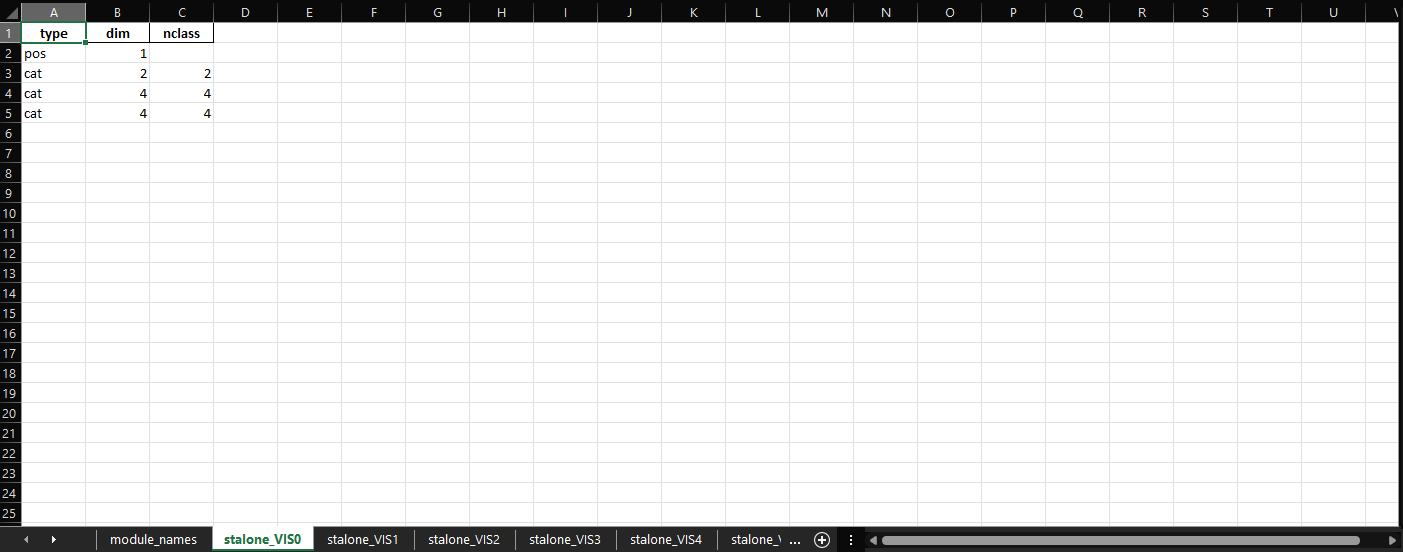

Screenshot for reference: File ./preprocessed/rosmap-long_pp_data_aux.xlsx (sheet: stalone_VIS0)
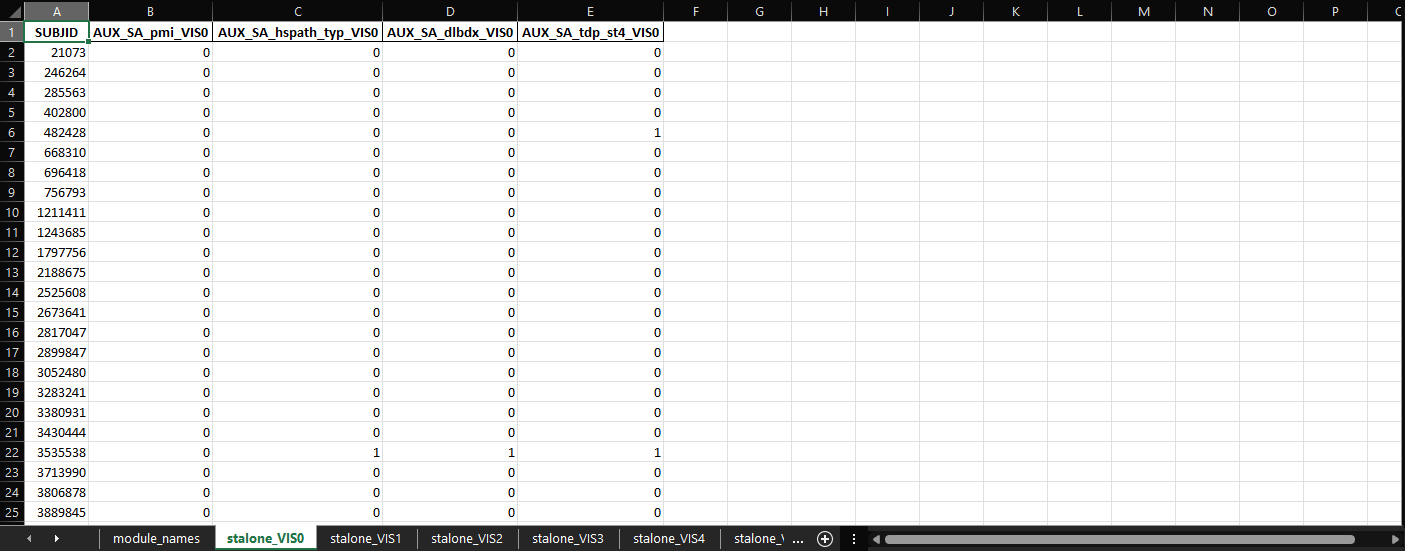

Screenshot for reference: Folder ./preprocessed/python_names
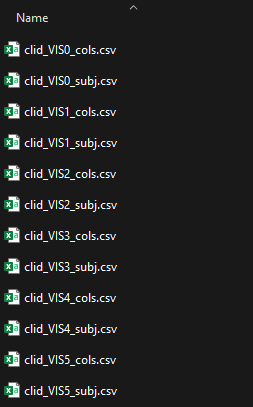

Screenshot for reference: File ./preprocessed/python_names/clid_VIS0_cols.csv
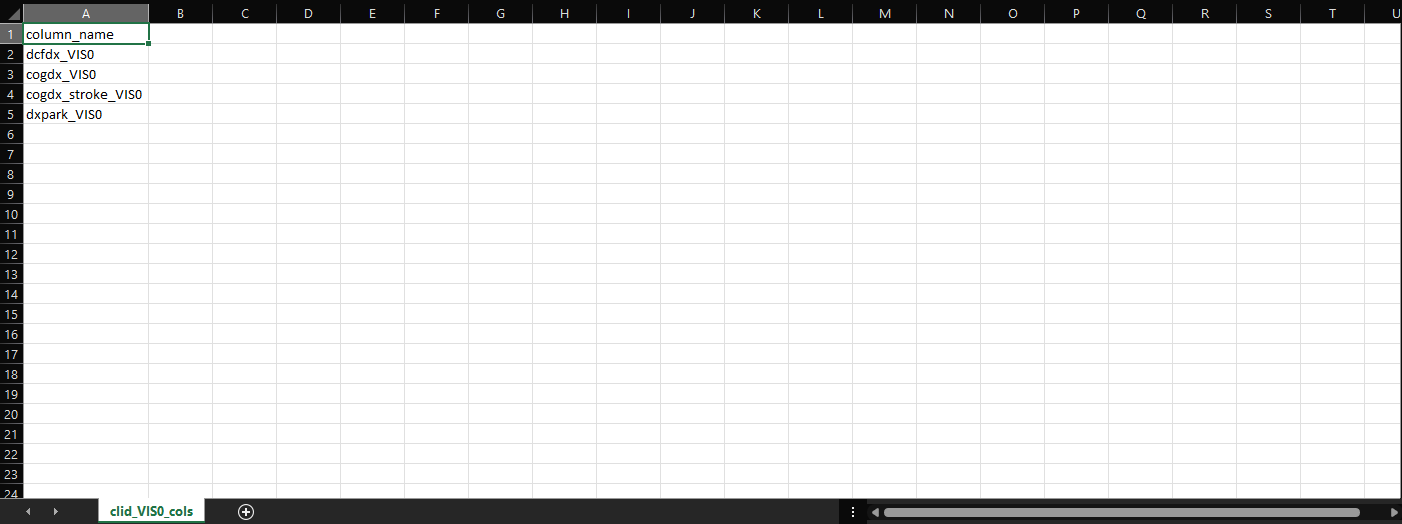

Screenshot for reference: File ./preprocessed/python_names/clid_VIS0_subj.csv
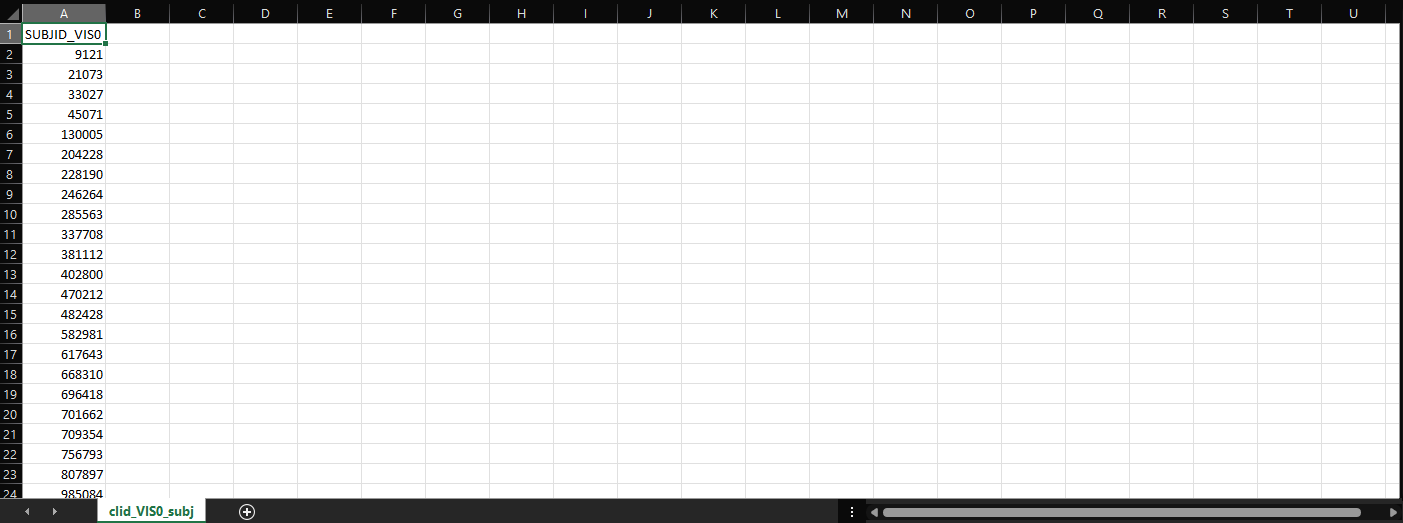

Screenshot for reference: Folder ./preprocessed/data_python
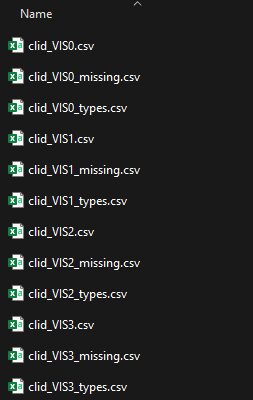

Screenshot for reference: File ./preprocessed/data_python/clid_VIS0.csv
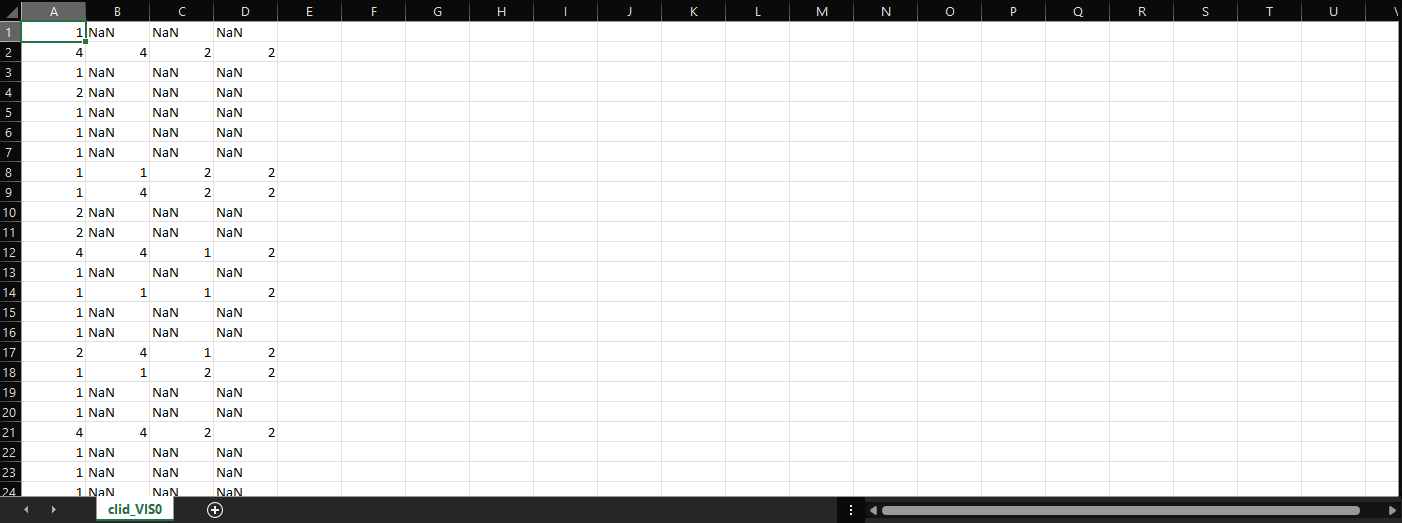

Screenshot for reference: File ./preprocessed/data_python/clid_VIS0_missing.csv
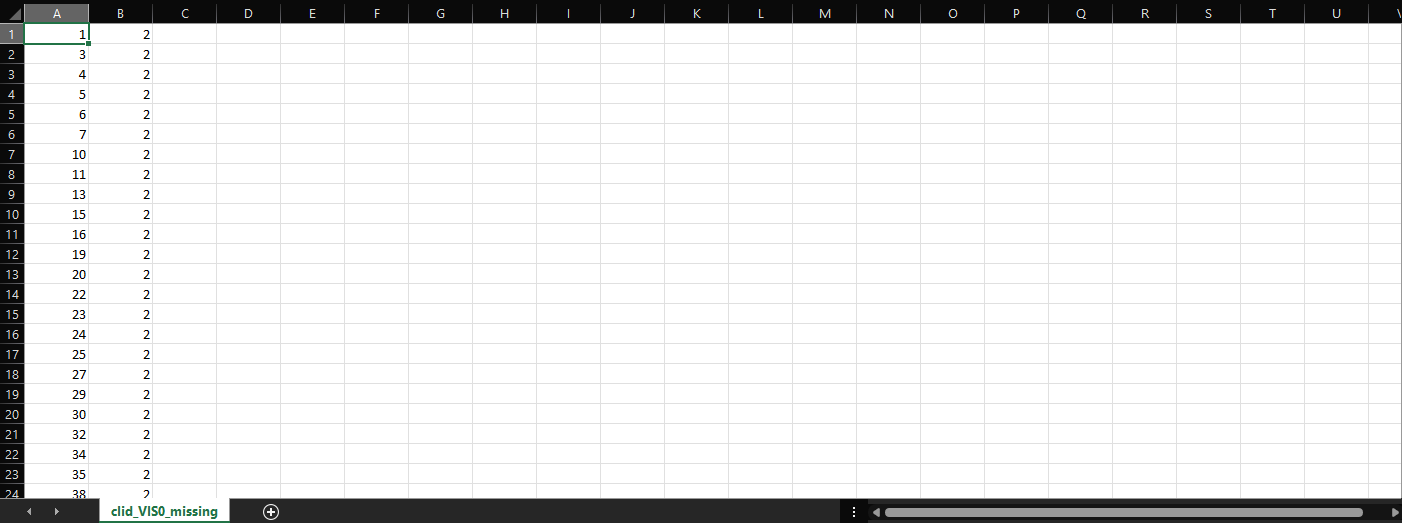

Screenshot for reference: File ./preprocessed/data_python/clid_VIS0_types.csv
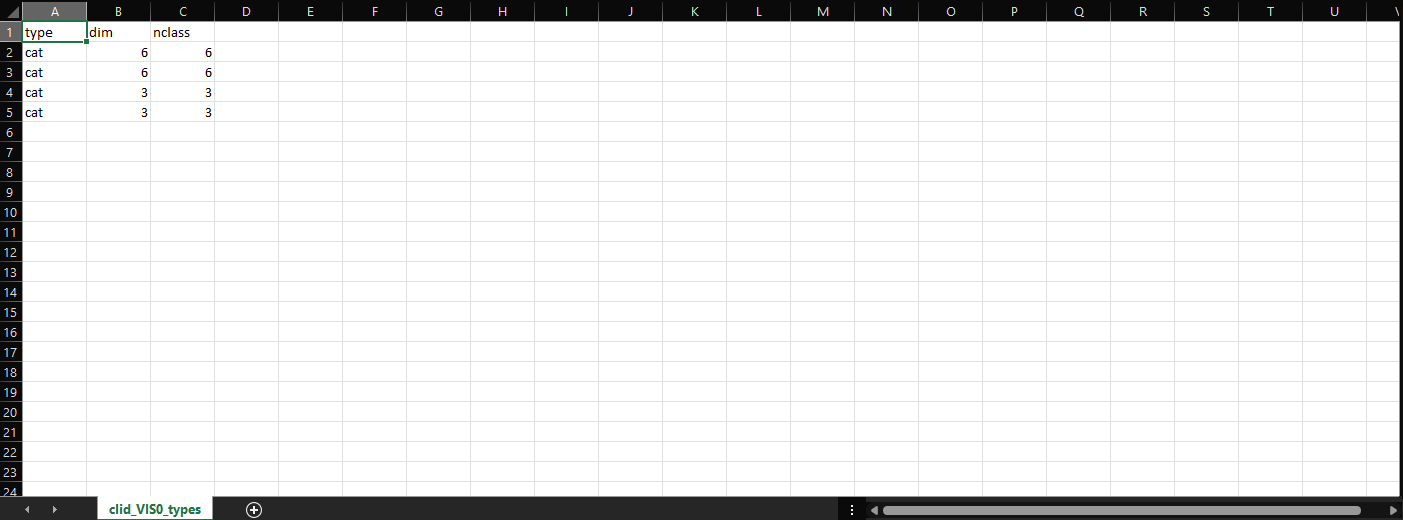

###############################################################################################################################

# ToDOs

1. Inverse transform label encoded values.
2. Inverse transform normalized values.
3. Inverse transform square-root transformed values.